# Requirements

In [ ]:
# # terminal de instalação
# !pip install numpy
# !pip install python-magic-bin
# !pip uninstall matplotlib seaborn -y
# !pip install matplotlib seaborn
# !pip install --upgrade pip
# !pip install ninja
# !pip install matplotlib --force-reinstall --no-binary :all:
# !pip install seaborn
# !pip install meson
# !pip uninstall matplotlib seaborn -y
# !pip install matplotlib seaborn
# !pip install pandas
# !pip install ibge
# !pip install sidrapy
# !pip install scikit-learn
# !pip install neuralforecast
# !pip freeze > requirements.txt
# !pyenv install 3.11.6
# !pyenv global 3.11.6
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install xgboost

In [2]:
import os
import sys
import pandas as pd
import seaborn as sns
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats

# import seaborn as sns
# from pathlib import Path
# import requests
# import sidrapy
# from ibge.localidades import *
# import torch

## Ativar o ambiente virtual

In [3]:
# Caminho para o ambiente virtual
venv_path = os.path.join('.', 'venv_health', 'Scripts', 'activate')  # Ajuste para Linux/Mac: 'bin/activate_this.py'

os.system(venv_path)

# Agora o script usará as dependências do ambiente virtual
print("Ambiente virtual ativado:", sys.prefix)

Ambiente virtual ativado: d:\python\data_health\venv_health


# Obter os dados

## Buscando os arquivos já tratados

Os dados são obtidos de um arquivo csv já tratado, caso não tenha o arquivo ele será criado automaticamente pelo script que executará ambas etapas:

- Converter o arquivo .dbc em .csv, gerando o arquivo `HANSENIASE_TOTAL_`

- Pré-processamento dos dados do Wsus¹ gerando o csv já tratado `HANSENIASE_PROCESS_`

In [4]:
print("-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------")
arquivos = []
path_csv = os.path.join('.', 'data', 'HANS')

# Garantir que o diretório existe
if not os.path.exists(path_csv):
    print(f"Diretório não encontrado: {path_csv}")
    os.makedirs(path_csv)  # Criar o diretório se não existir

# Verificar arquivos no diretório
for f in os.listdir(path_csv):
    if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
        try:
            # Extrair data do nome do arquivo
            data_str = f.split('_')[-3:]  # Pega os últimos 3 elementos (dd, mm, yyyy)
            data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
            arquivos.append((data, f))
        except Exception as e:
            print(f"Arquivo com formato inválido: {f} - {e}")

# Executar script externo se nenhum arquivo for encontrado
if not arquivos:
    print("Nenhum arquivo encontrado. Executando script para gerar arquivo...")
    path_gerar_wsus = os.path.join('.', 'gerar_wsus_csv.py')
    resultado = os.system('python ' + path_gerar_wsus)
    
    if resultado == 0:
        print("Script executado com sucesso. Verificando novo arquivo...")
        # Recarregar lista de arquivos após execução do script
        for f in os.listdir(path_csv):
            if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
                try:
                    data_str = f.split('_')[-3:]
                    data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
                    arquivos.append((data, f))
                except Exception as e:
                    print(f"Erro ao processar novo arquivo: {f} - {e}")
    else:
        print("Erro na execução do script. Arquivo não gerado.")

# Exibir lista final de arquivos encontrados
print("Arquivos encontrados:", arquivos)

if arquivos:
    # Ordenar arquivos pela data mais recente
    arquivos.sort(reverse=True, key=lambda x: x[0])
    
    # Pegar arquivo mais recente
    ultimo_arquivo = os.path.join(path_csv, arquivos[0][1])
    
    print(f"Carregando arquivo mais recente: {ultimo_arquivo}")
    
    # Carregar dados
    df_dados = pd.read_csv(ultimo_arquivo, encoding='utf-8', low_memory=False)
    
    print("\nPrimeiras linhas do DataFrame:")
    print(f"\nTotal de registros: {len(df_dados):,}")
    print(f"Data de referência: {arquivos[0][0].strftime('%d/%m/%Y')}")
else:
    print("Nenhum arquivo válido encontrado na pasta")

-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------
Nenhum arquivo encontrado. Executando script para gerar arquivo...
Script executado com sucesso. Verificando novo arquivo...
Arquivos encontrados: [(datetime.datetime(2025, 3, 7, 0, 0), 'HANSENIASE_PROCESS_07_03_2025.csv')]
Carregando arquivo mais recente: .\data\HANS\HANSENIASE_PROCESS_07_03_2025.csv

Primeiras linhas do DataFrame:

Total de registros: 984,035
Data de referência: 07/03/2025


## Analise das variaveis

### Variaveis à se analisar 

'NU_IDADE_N': IDADE \
'CS_SEXO': SEXO \
'CS_GESTANT' : GESTANTE \
'CS_RACA' : RAÇA \
'NU_LESOES': Nº de lesões cutâneas \
'FORMACLINI': Forma clínica inicial por ocasião do diagnóstico, segundo classificação de Madrid \
'AVALIA_N': Avaliação do Grau de Incapacidade Física no Diagnóstico \
'CLASSOPERA': Classificação operacional, por ocasião do diagnóstico, para eleição do esquema terapêutico  \
'BACILOSCOP': resultado da baciloscopia \
'ESQ_INI_N': Esquema terapêutico instituído por ocasião do diagnostico \
'CONTREG': Número de pessoas que residam ou tenham residido, nos últimos 5 anos com o doente, a contar da Data do diagnóstico \
'NERVOSAFET': Número de nervos afetados  \
'CLASSATUAL': Classificação operacional atual \
'AVAL_ATU_N': Avaliação de incapacidade física no momento da cura  \
'ESQ_ATU_N': Esquema terapêutico em uso  \
'DOSE_RECEB': Número de doses supervisionadas \
'EPIS_RACIO': Episódio Reacional Durante o Tratamento \
'CONTEXAM': Número de contatos examinados \
'TPALTA_N': Tipo de Saída (cura, obito) \
'IDADE_ANOS': idade em Anos (tratada de 'NU_IDADE_N') \
'IDADE_MESES': Meses para recem nascidos (tratada 'NU_IDADE_N') \
'CS_SEXO_CAT': Sexo categorizado (tratada 'CS_SEXO_CAT') \
'CLASSATUAL_CAT': Classificação operacional atual (tratada 'CLASSATUAL') \
'AVAL_ATU_N_CAT': Avaliação de incapacidade física no momento da cura (tratada 'AVAL_ATU_N')

### Função integrada que gera relatórios completos para qualquer variável, combinando análise estatística e visualizações. Usaremos Pandas para dados e Matplotlib/Seaborn para gráficos

In [13]:
def analise_univariada(df, coluna):
     # Configurações iniciais
     # Extrair valores distintos incluindo NaN

    contagem_nan = df[coluna].isna().sum()
    valores_distintos = df[coluna].drop_duplicates().tolist()

    plt.figure(figsize=(18, 12))
    cor = '#2ecc71'
    
    # Análise estatística
    estatisticas = {
        'Média': df[coluna].mean(),
        'Mediana': df[coluna].median(),
        'Desvio Padrão': df[coluna].std(),
        'Assimetria': df[coluna].skew(),
        'Curtose': df[coluna].kurt(),
        'Shapiro-Wilk (p-value)': stats.shapiro(df[coluna])[1]
    }
    
    # Tabela de frequência
    freq = pd.DataFrame({
        'Frequência Absoluta': df[coluna].value_counts(),
        'Frequência Relativa (%)': df[coluna].value_counts(normalize=True) * 100
    }).head(10)
    
    # Detecção de outliers
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    lim_inferior = Q1 - 1.5*(Q3 - Q1)
    lim_superior = Q3 + 1.5*(Q3 - Q1)
    outliers = df[(df[coluna] < lim_inferior) | (df[coluna] > lim_superior)]
    
    # Plotagem de gráficos atualizada
    plt.subplot(2, 2, 1)
    sns.histplot(df[coluna], kde=True, color=cor)
    plt.title(f'Distribuição de {coluna}', fontweight='bold')
    
    plt.subplot(2, 2, 2)
    plt.hist(df[coluna].dropna(), bins=50, color=cor, edgecolor='black')
    plt.title(f'Histograma Detalhado', fontweight='bold')
    plt.xlabel(coluna)
    plt.ylabel('Frequência')
    
    plt.subplot(2, 2, 3)
    sns.kdeplot(df[coluna], color=cor)
    plt.title(f'Densidade de Probabilidade', fontweight='bold')
    
    plt.subplot(2, 2, 4)
    sns.boxplot(x=df[coluna], color=cor)
    plt.title(f'Boxplot com Outliers', fontweight='bold')
    
    plt.tight_layout()
    
    return {
        'Estatísticas Descritivas': pd.DataFrame([estatisticas]),
        'Top 10 Frequências': freq,
        'Outliers': f"{len(outliers)} registros ({len(outliers)/len(df)*100:.2f}%)",
        'Gráficos': plt.gcf(),
        'Valores Distintos': valores_distintos,
        'Contagem de NaN': f"{contagem_nan} registros ({contagem_nan/len(df)*100:.2f}%)"
    }


### NU_IDADE_N': IDADE (Tratada para IDADE_ANOS e IDADE_MESES)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
         Média  Mediana  Desvio Padrão  Assimetria      Curtose  \
0  4041.798987   4043.0      45.980161   -35.39902  1669.757033   

   Shapiro-Wilk (p-value)  
0           4.227180e-228  
Top 10 Frequências
            Frequência Absoluta  Frequência Relativa (%)
NU_IDADE_N                                              
4049                      18743                 1.904709
4050                      18656                 1.895868
4048                      18580                 1.888144
4051                      18572                 1.887331
4046                      18507                 1.880726
4047                      18361                 1.865889
4044                      18285                 1.858166
4045                      18072                 1.836520
4052                      17954                 1.824529
4053                      17827                 1.811623
Outliers
774 registros (0.08%)
Valores Distintos
[4058, 4044, 4032, 4040, 4031, 4

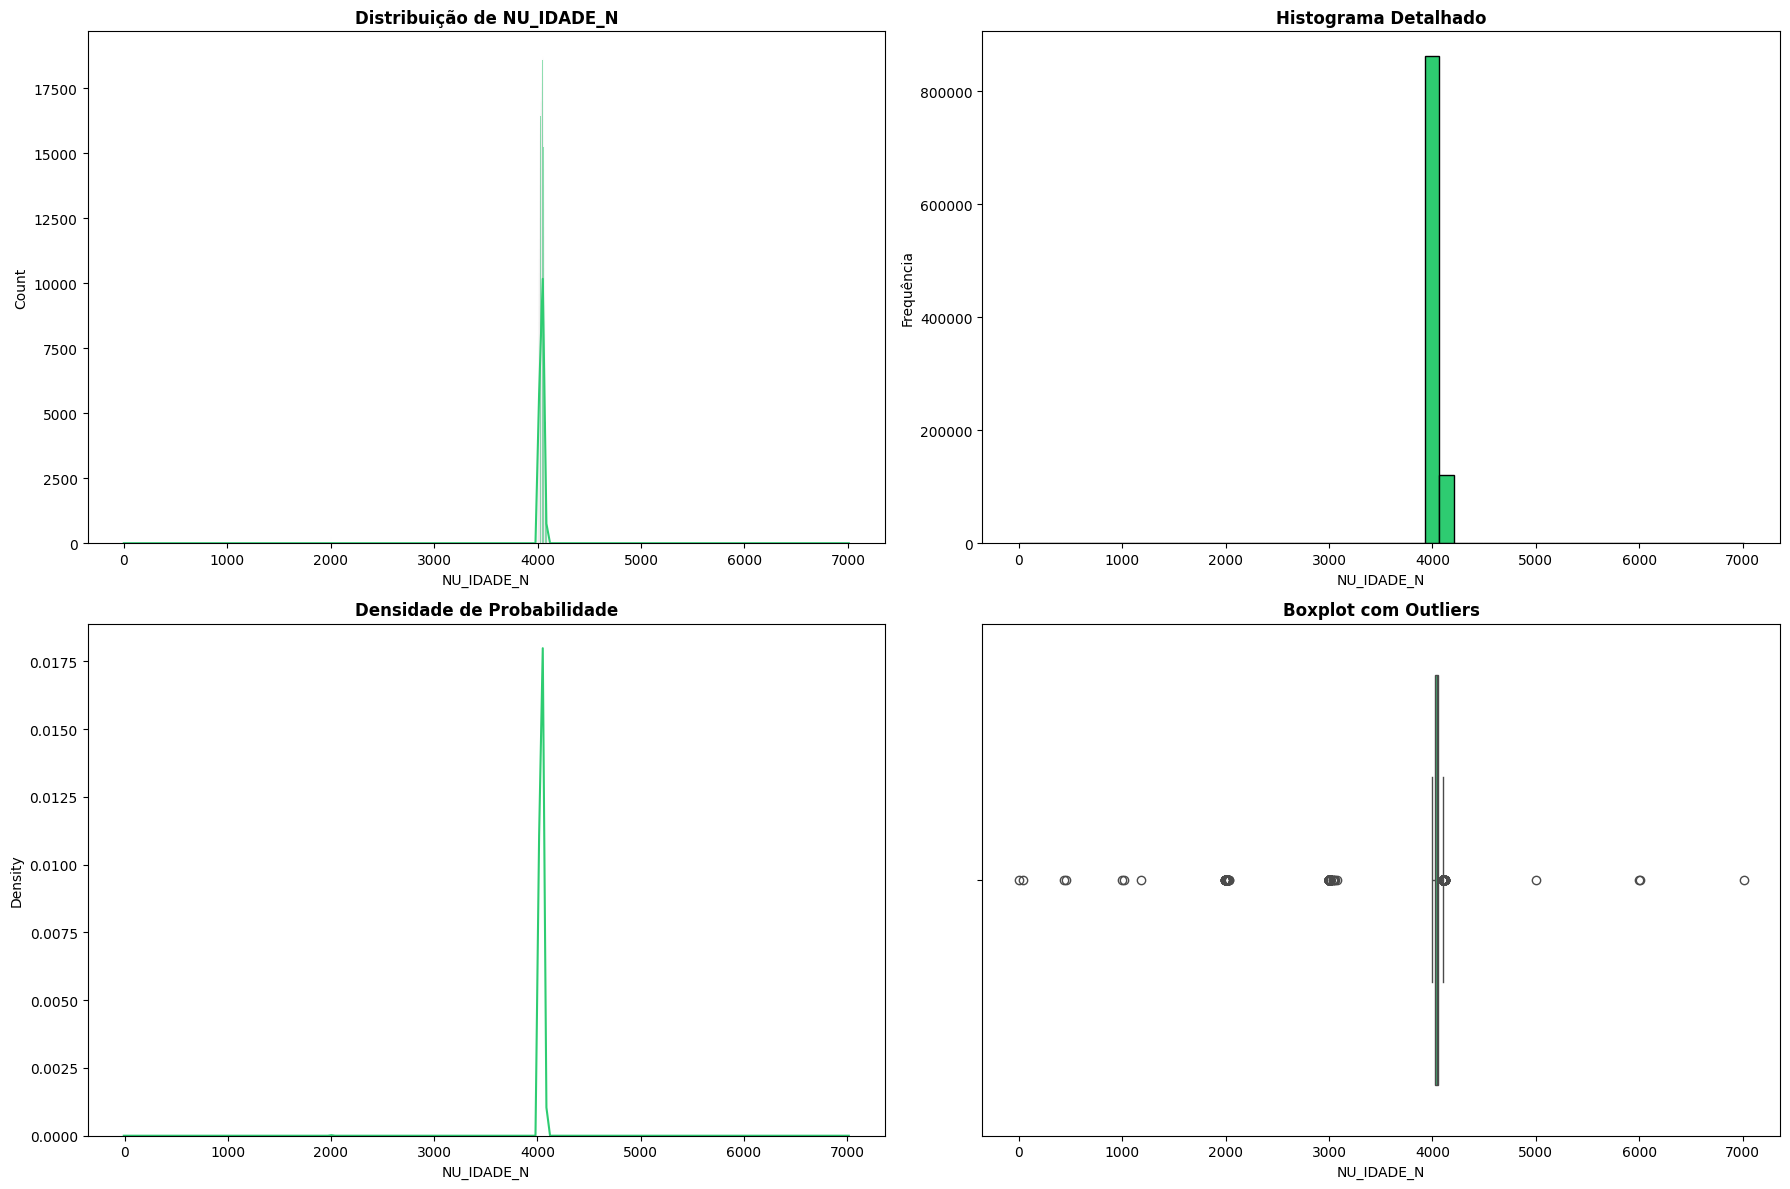

In [14]:
# Exemplo para NU_IDADE_N
relatorio = analise_univariada(df_dados, 'NU_IDADE_N')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outliers")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

#### IDADE_ANOS

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
       Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  42.709884     43.0      18.605232    0.100388 -0.686738   

   Shapiro-Wilk (p-value)  
0            2.631904e-90  
Top 10 Frequências
            Frequência Absoluta  Frequência Relativa (%)
IDADE_ANOS                                              
49                        18743                 1.904709
50                        18656                 1.895868
48                        18580                 1.888144
51                        18572                 1.887331
46                        18507                 1.880726
47                        18361                 1.865889
44                        18285                 1.858166
45                        18072                 1.836520
52                        17954                 1.824529
53                        17827                 1.811623
Outliers
224 registros (0.02%)
Valores Distintos
[58, 44, 32, 40, 31, 42, 34, 38, 52, 24, 2

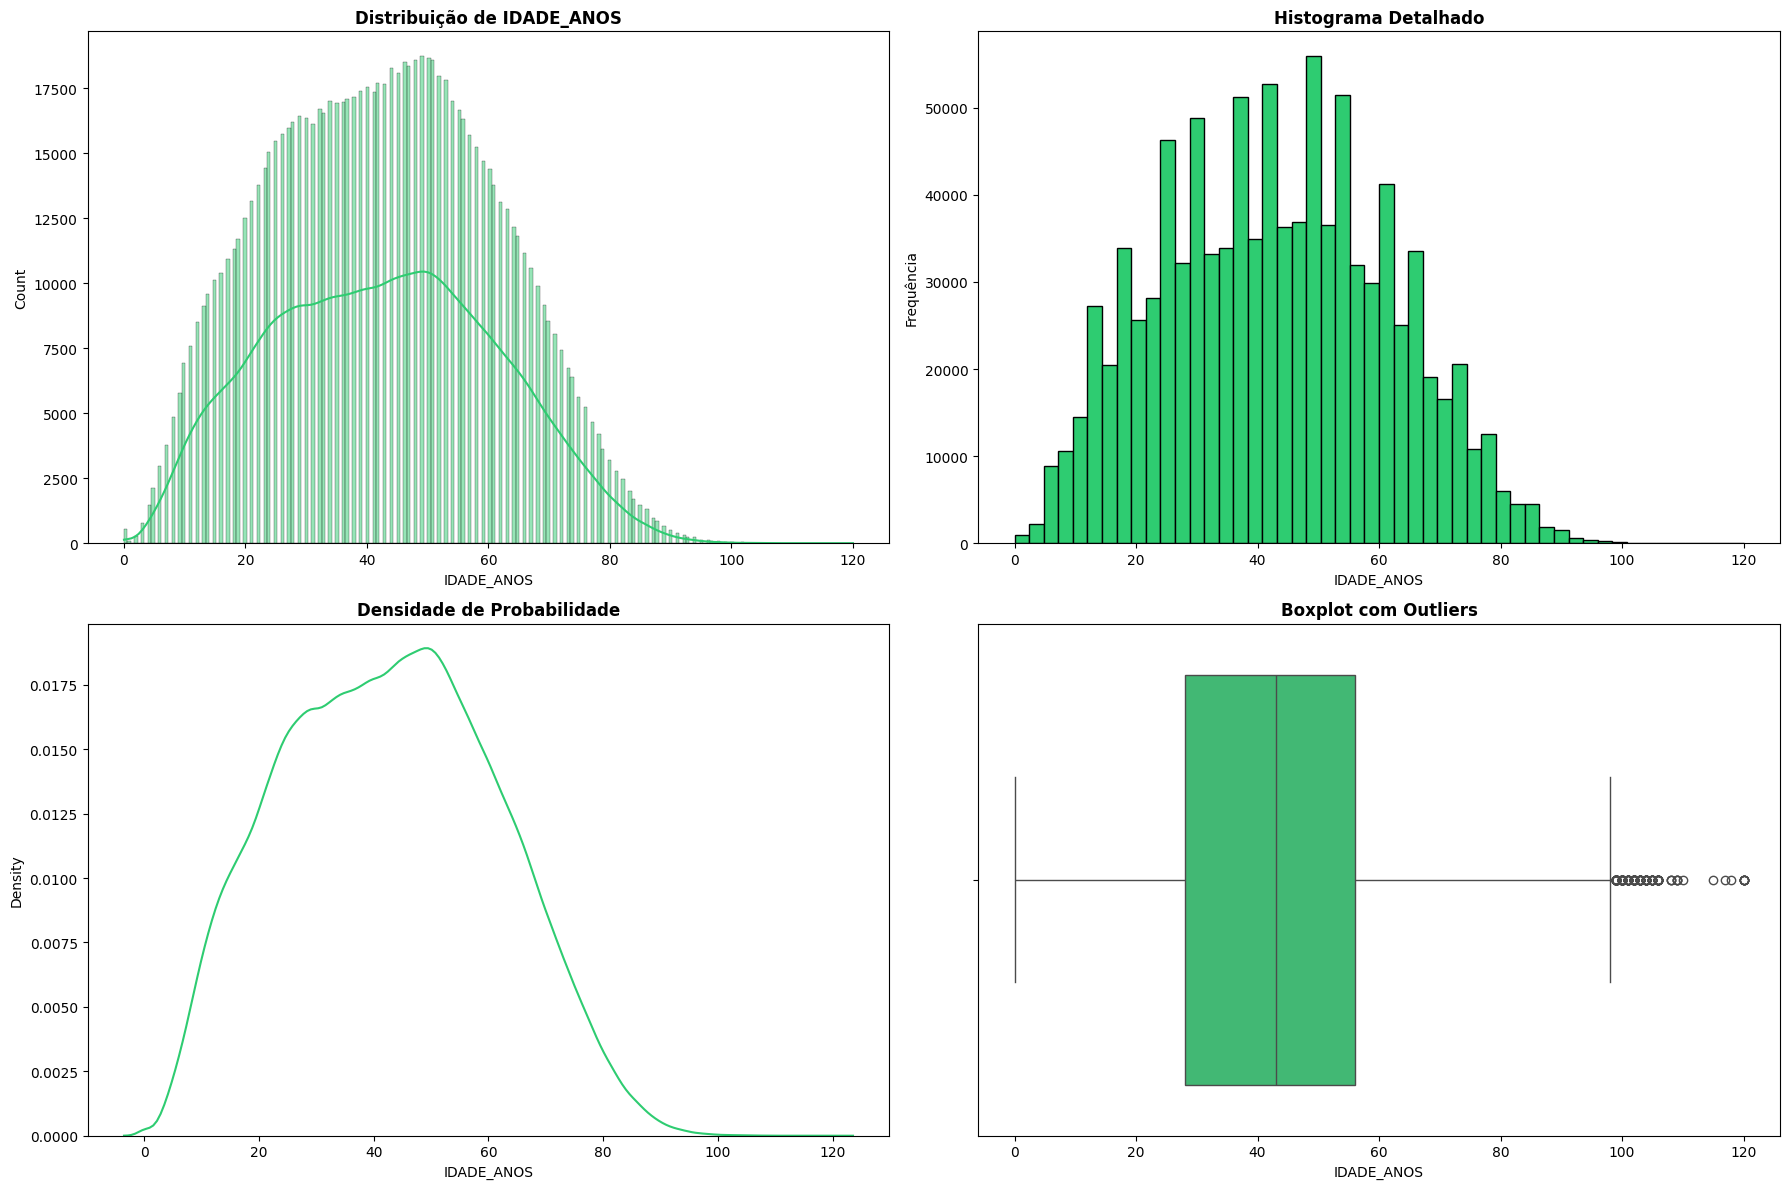

In [15]:
# Exemplo para IDADE_ANOS
relatorio = analise_univariada(df_dados, 'IDADE_ANOS')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outliers")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

#### IDADE_MESES

Dados dos meses com valor maior que 0, isto é, recém-nascido

In [16]:
df_recem = df_dados[df_dados['IDADE_MESES'] > 0]

Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  2.304428      1.0       2.397923    1.946847  2.960078   

   Shapiro-Wilk (p-value)  
0            5.308040e-33  
Top 10 Frequências
             Frequência Absoluta  Frequência Relativa (%)
IDADE_MESES                                              
1                            365                67.343173
2                             40                 7.380074
3                             25                 4.612546
5                             24                 4.428044
6                             22                 4.059041
4                             20                 3.690037
7                             16                 2.952030
10                            11                 2.029520
8                              8                 1.476015
11                             6                 1.107011
Outlierss
46 registros (8.49%)
Valores Distintos
[1, 5, 11, 2, 4, 10, 8, 6, 3, 9,

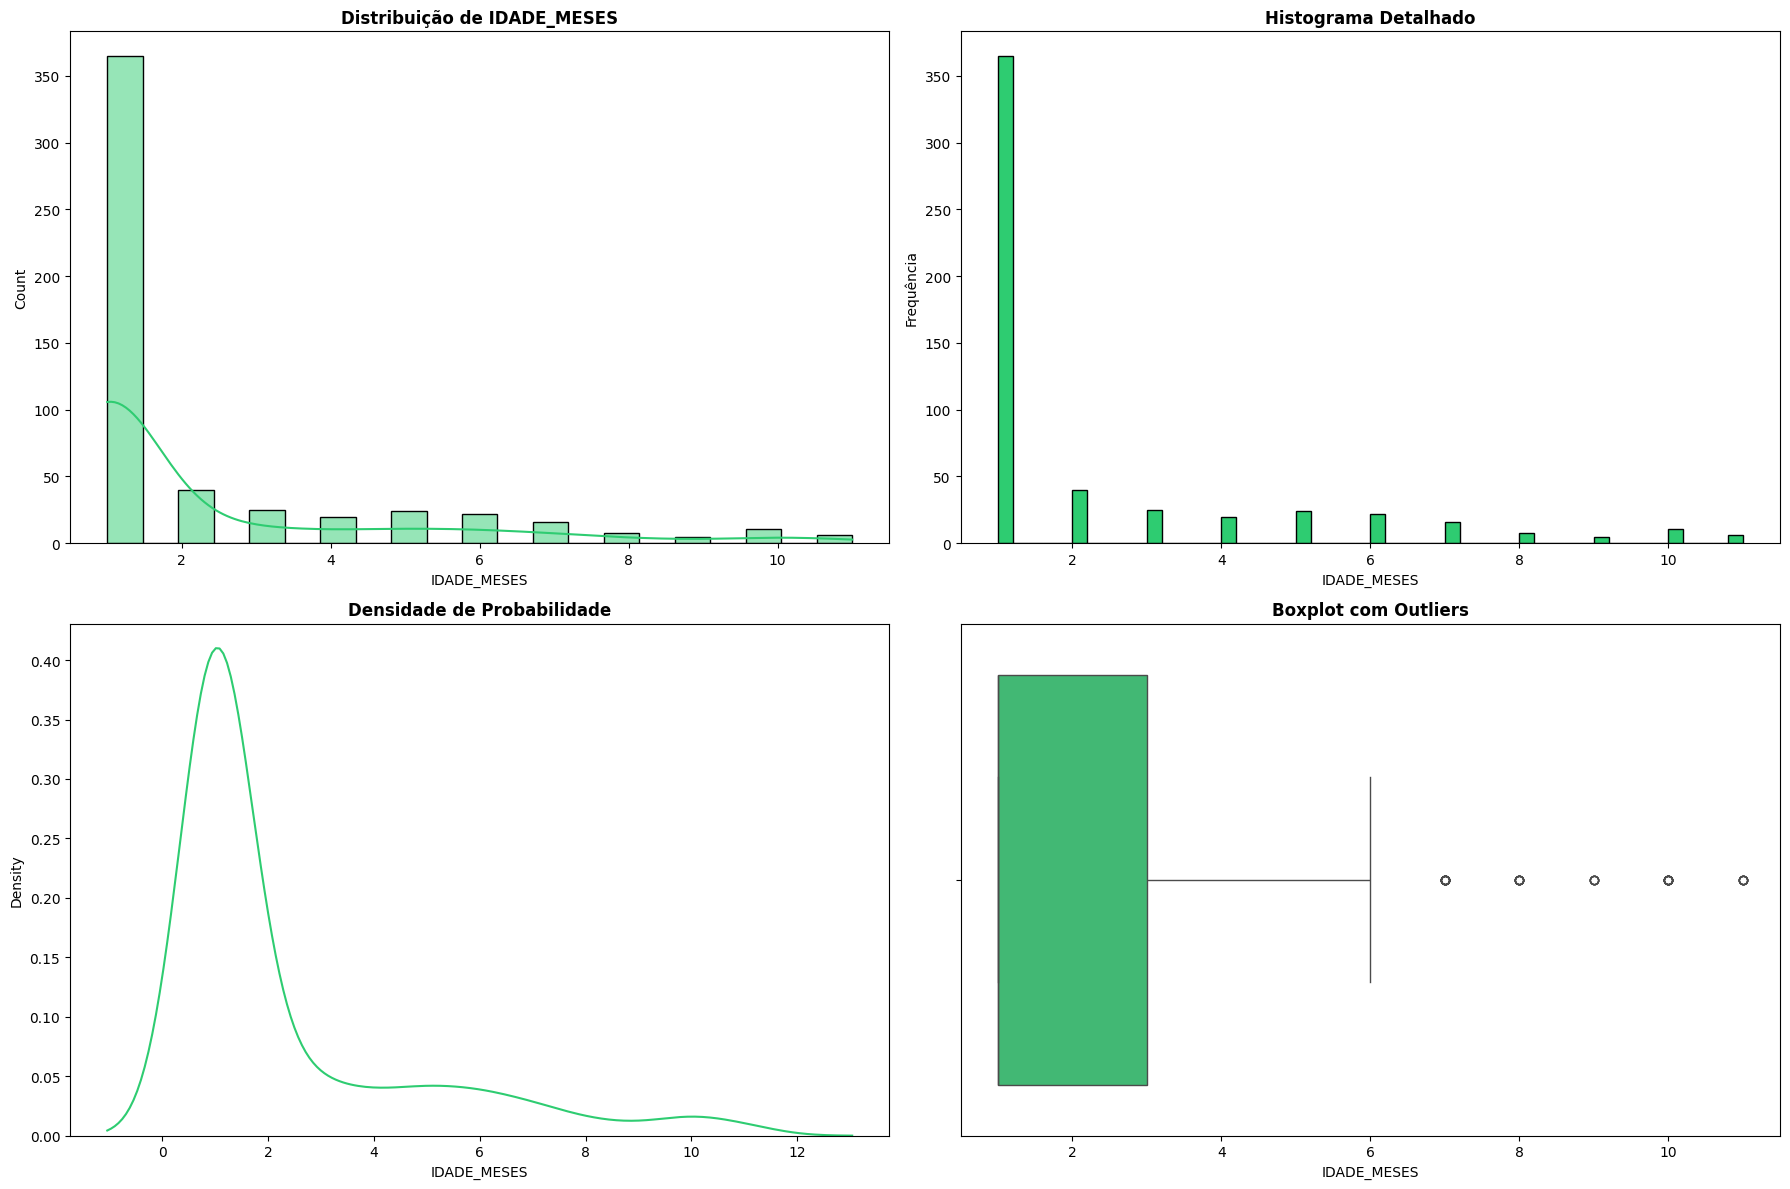

In [17]:
# Exemplo para IDADE_ANOS
relatorio = analise_univariada(df_recem, 'IDADE_MESES')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### CS_SEXO (Categorizada para CS_SEXO_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  1.441579      1.0       0.507121    0.843864  7.296664   

   Shapiro-Wilk (p-value)  
0           1.353510e-200  
Top 10 Frequências
             Frequência Absoluta  Frequência Relativa (%)
CS_SEXO_CAT                                              
1                         550808                55.974432
2                         433041                44.006666
9                            186                 0.018902
Outlierss
186 registros (0.02%)
Valores Distintos
[1, 2, 9]
Contagem de NaN
0 registros (0.00%)


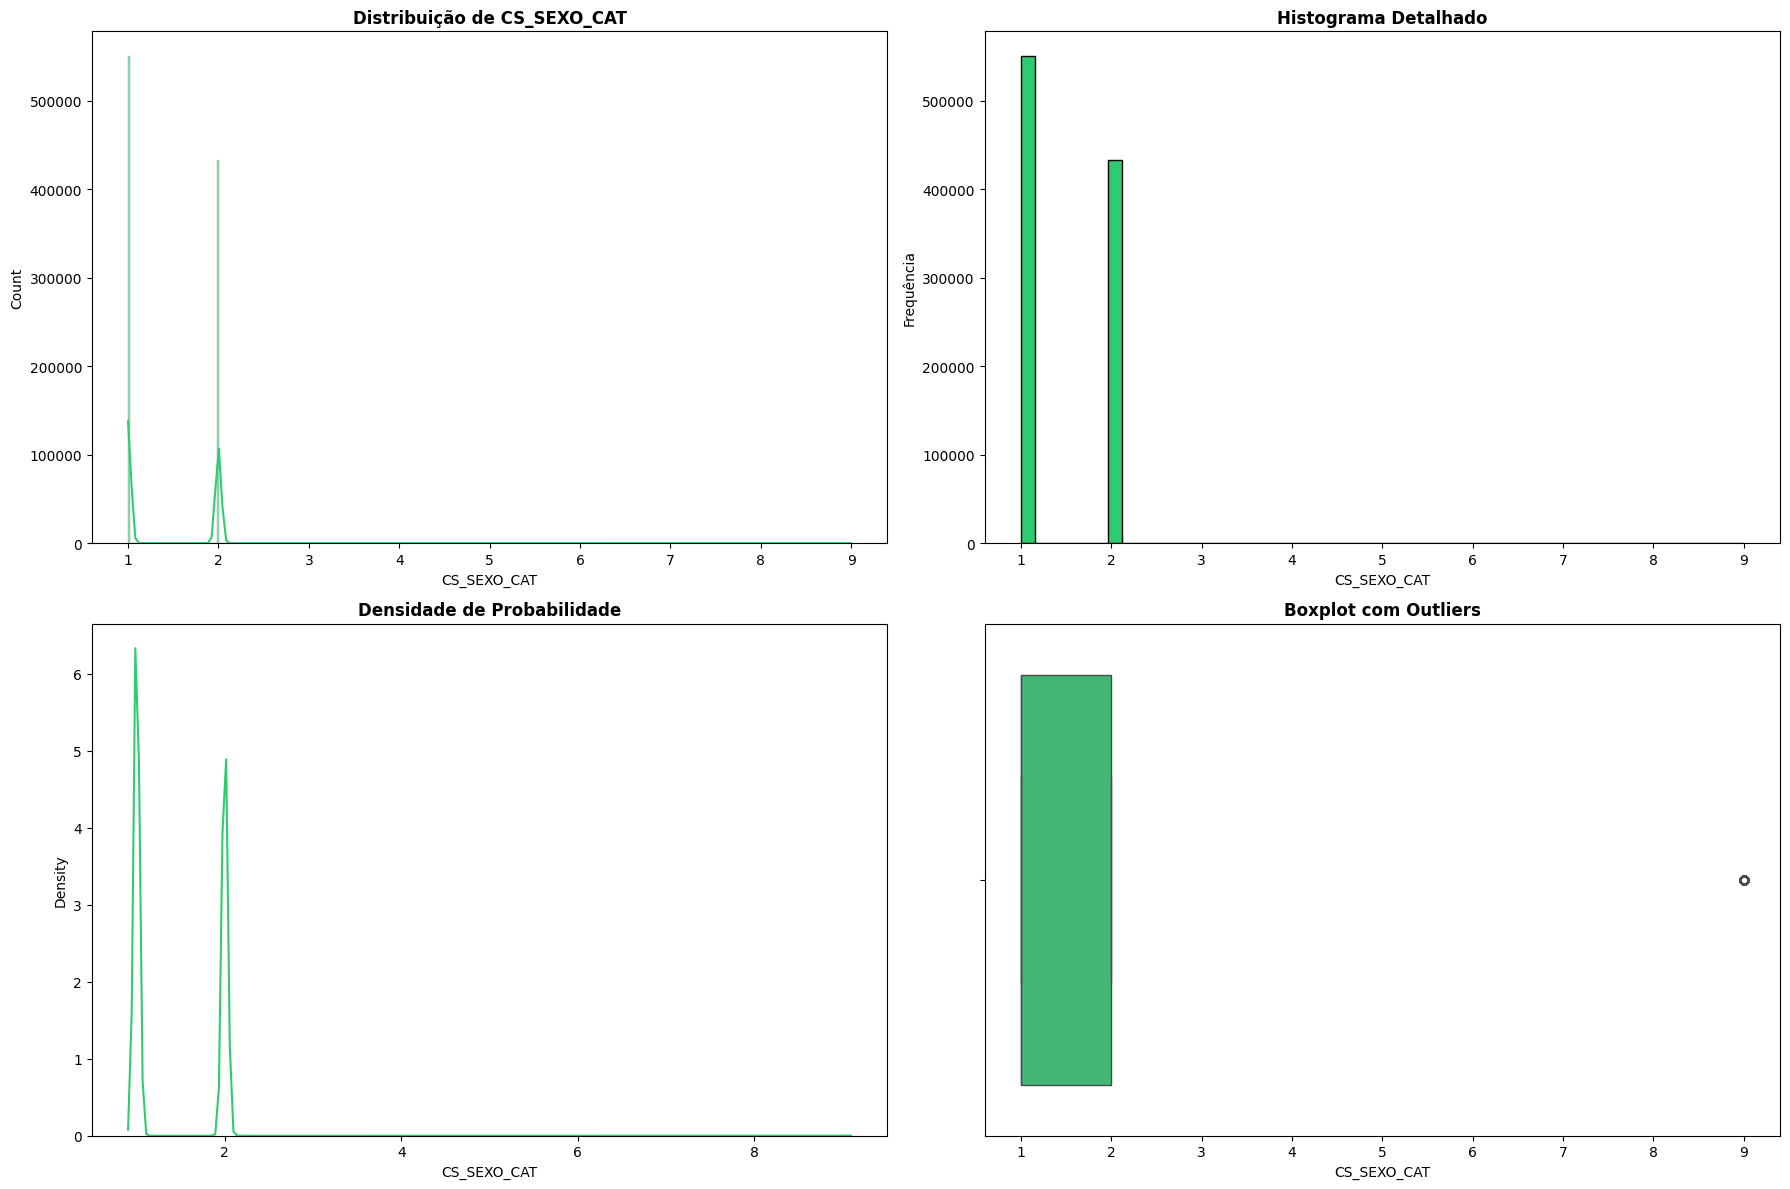

In [18]:
# Exemplo para CS_SEXO
relatorio = analise_univariada(df_dados, 'CS_SEXO_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### CS_GESTANT (Categorizada para CS_GESTANT_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  6.283095      6.0        1.30684    1.178177  0.827917   

   Shapiro-Wilk (p-value)  
0           5.681135e-194  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
CS_GESTANT_CAT                                              
6                            608826                61.870360
5                            204663                20.798346
9                            166181                16.887712
2                              1382                 0.140442
4                              1184                 0.120321
1                              1006                 0.102232
3                               793                 0.080587
Outlierss
375209 registros (38.13%)
Valores Distintos
[6, 9, 5, 1, 4, 3, 2]
Contagem de NaN
0 registros (0.00%)


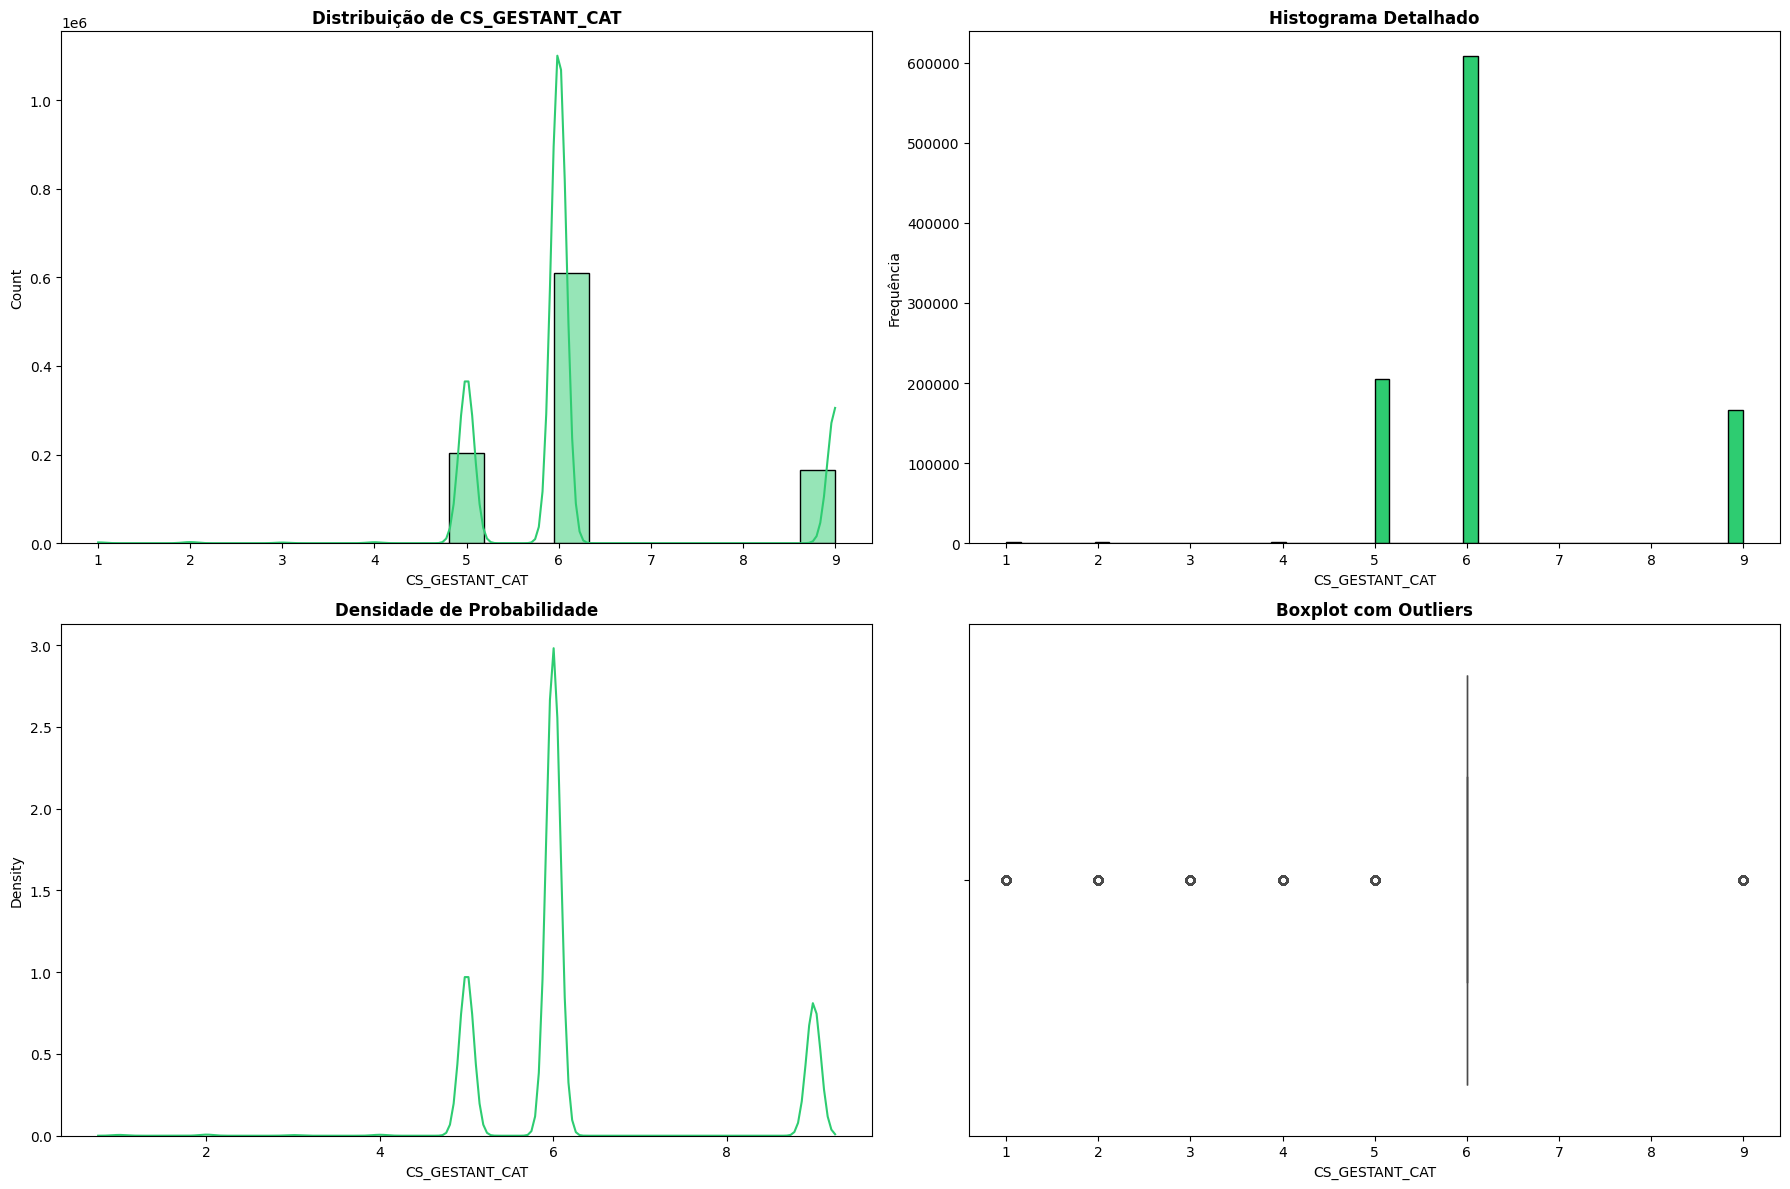

In [19]:
# Exemplo para CS_GESTANT_CAT
relatorio = analise_univariada(df_dados, 'CS_GESTANT_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### CS_RACA (Categorizada para CS_RACA_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria  Curtose  \
0  3.518848      4.0       2.315309    1.094889  0.84293   

   Shapiro-Wilk (p-value)  
0           5.592981e-182  
Top 10 Frequências
             Frequência Absoluta  Frequência Relativa (%)
CS_RACA_CAT                                              
4                         485235                49.310746
1                         256308                26.046635
2                         118802                12.072945
9                         108217                10.997271
3                          11750                 1.194063
5                           3723                 0.378340
Outlierss
108217 registros (11.00%)
Valores Distintos
[9, 1, 4, 2, 5, 3]
Contagem de NaN
0 registros (0.00%)


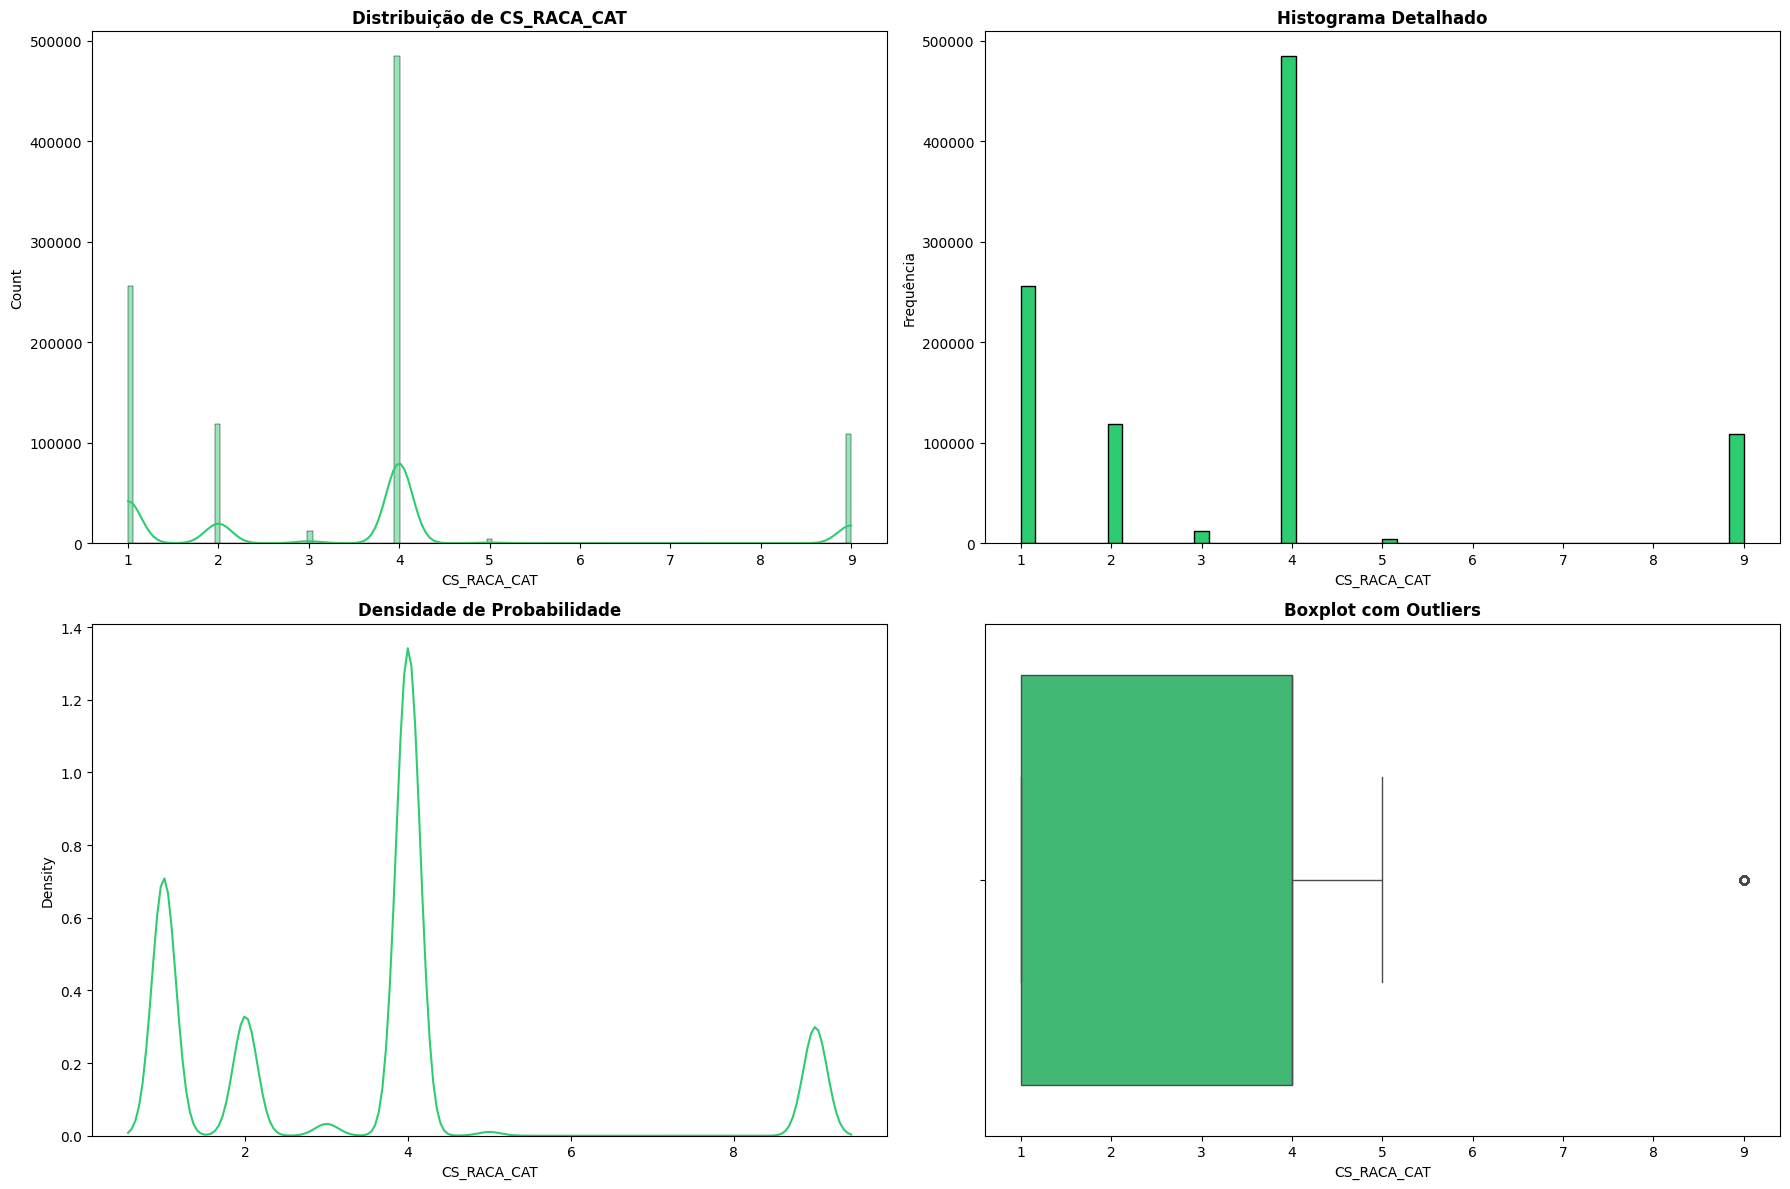

In [20]:
# Exemplo para CS_RACA_CAT
relatorio = analise_univariada(df_dados, 'CS_RACA_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### NU_LESOES (tratada para NU_LESOES_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria    Curtose  \
0  5.545974      2.0       9.198191    5.092758  39.239474   

   Shapiro-Wilk (p-value)  
0           6.046059e-207  
Top 10 Frequências
               Frequência Absoluta  Frequência Relativa (%)
NU_LESOES_CAT                                              
1                           240196                24.409294
0                           169459                17.220831
2                            95257                 9.680245
5                            73754                 7.495059
10                           71352                 7.250962
3                            59534                 6.049988
6                            57123                 5.804976
20                           42967                 4.366410
4                            36831                 3.742855
8                            27111                 2.755085
Outlierss
80034 registros (8.13%)
Valores Distintos
[0,

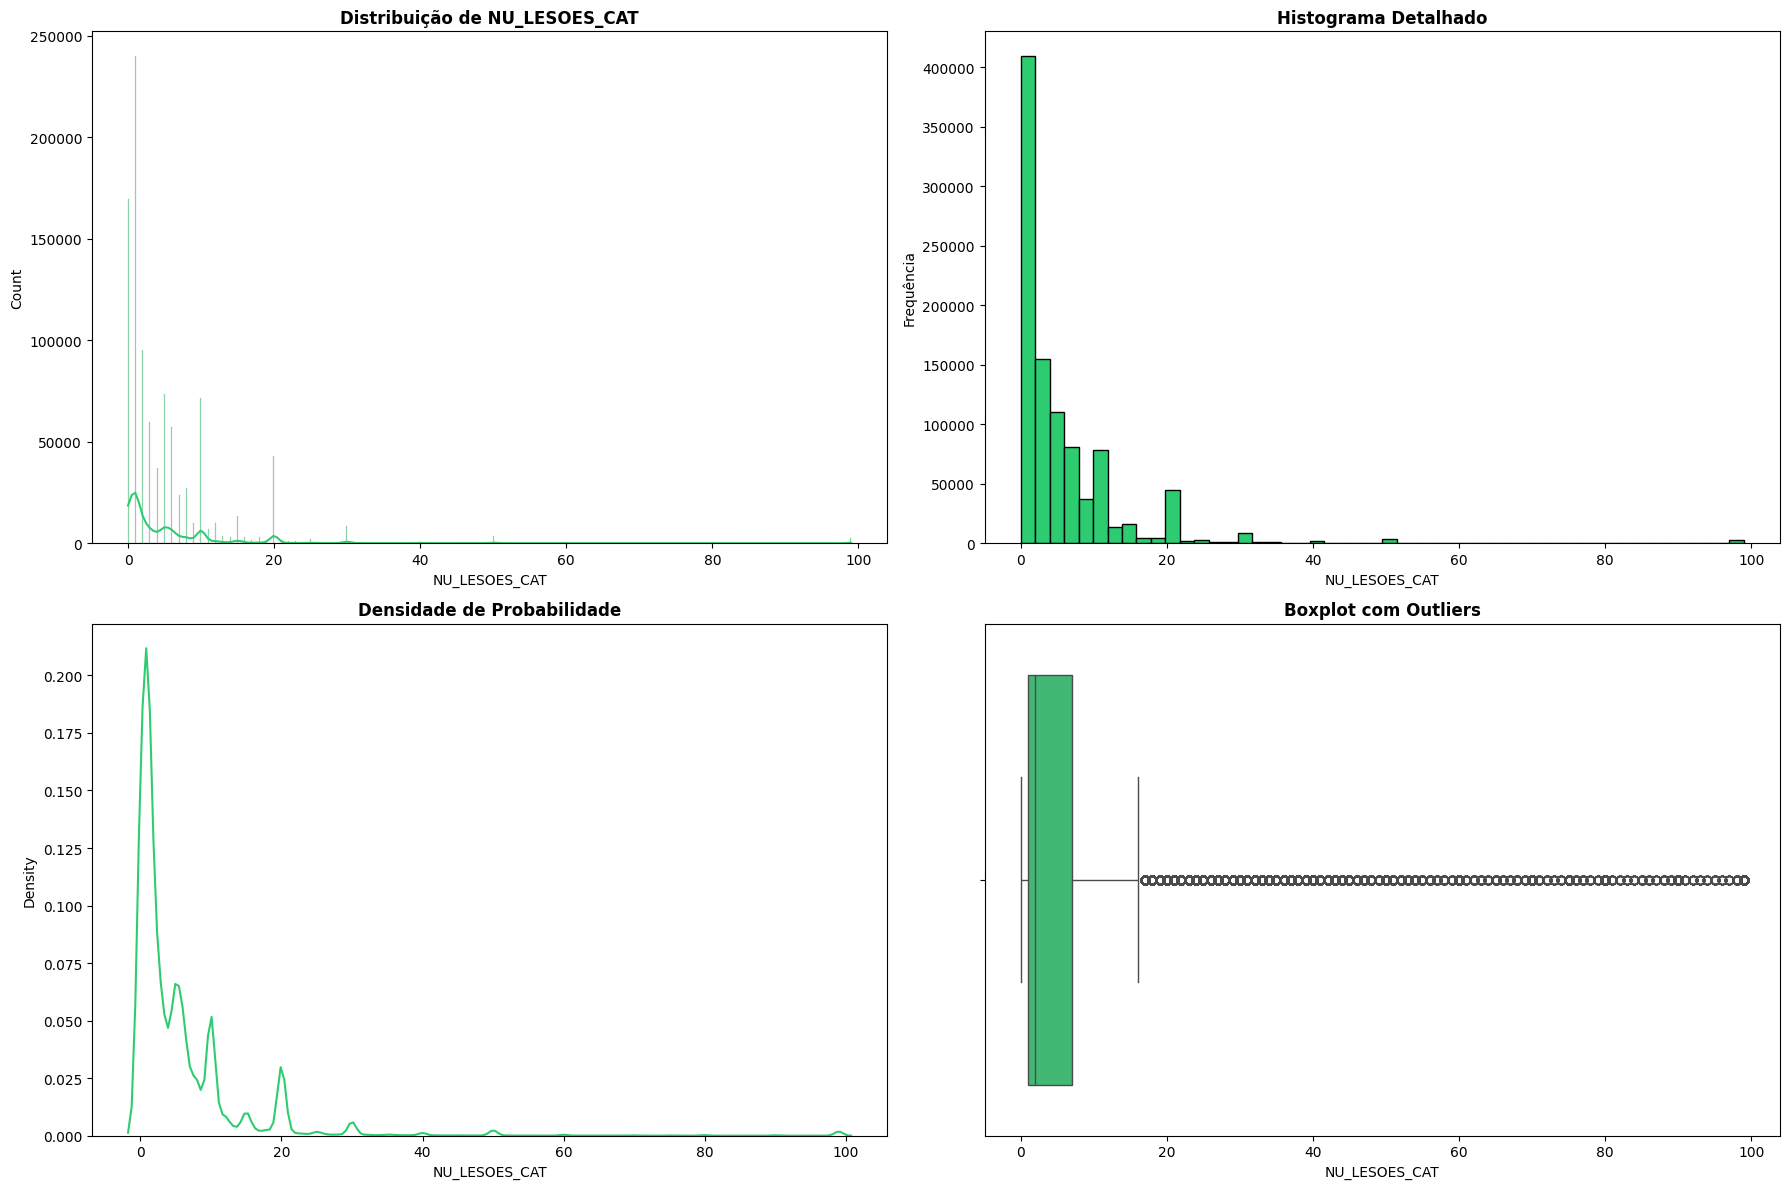

In [21]:
# Exemplo para NU_LESOES_CAT
relatorio = analise_univariada(df_dados, 'NU_LESOES_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### FORMACLINI (Tratada para FORMACLINI_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria  Curtose  \
0  2.866406      3.0       1.164914    0.081893 -0.28396   

   Shapiro-Wilk (p-value)  
0           1.136187e-151  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
FORMACLINI_CAT                                              
3                            391087                39.743200
2                            174628                17.746117
4                            170896                17.366862
1                            156208                15.874232
5                             90568                 9.203738
9                               535                 0.054368
6                               112                 0.011382
8                                 1                 0.000102
Outlierss
536 registros (0.05%)
Valores Distintos
[1, 4, 2, 3, 5, 9, 8, 6]
Contagem de NaN
0 registros (0.00%)


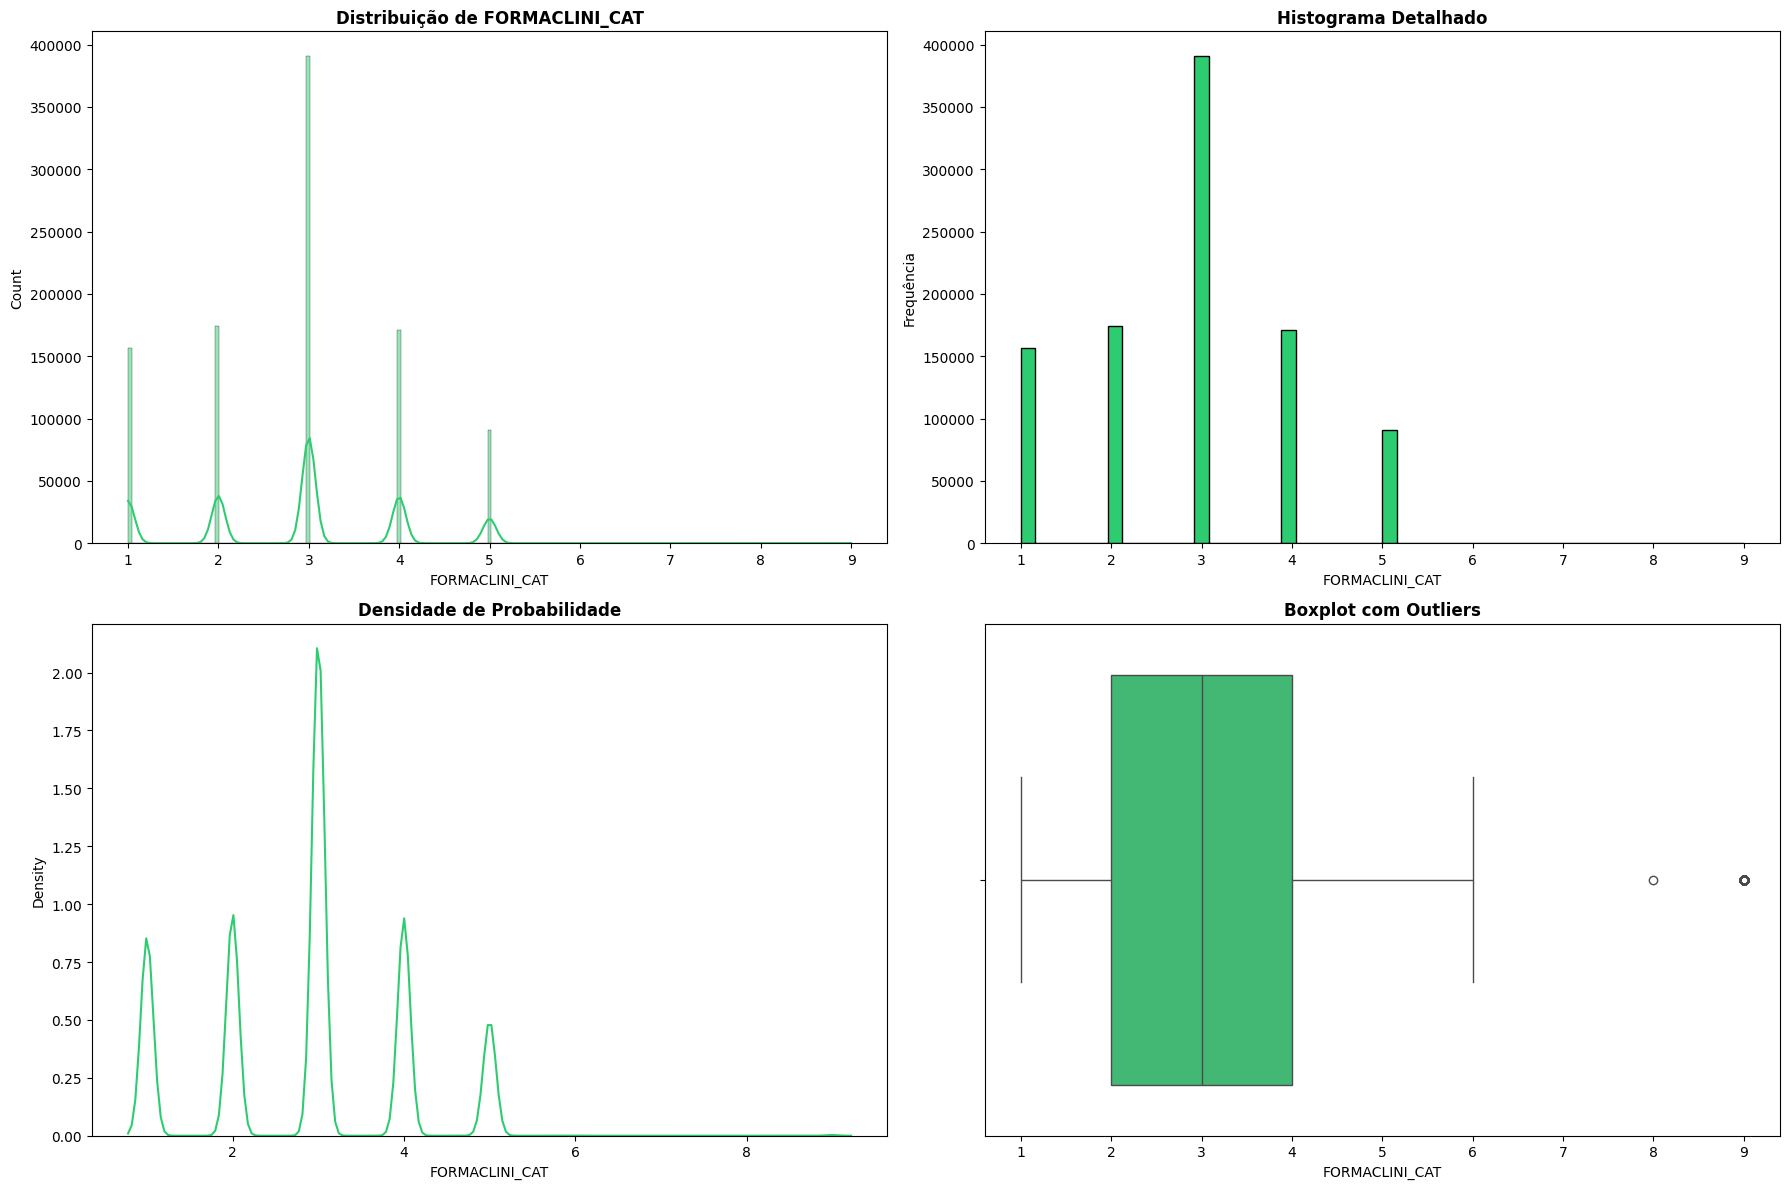

In [22]:
# Exemplo para FORMACLINI_CAT
relatorio = analise_univariada(df_dados, 'FORMACLINI_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### AVALIA_N (Tratada para AVALIA_N_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  0.726306      0.0       1.029183     1.21546  0.137446   

   Shapiro-Wilk (p-value)  
0           1.113389e-191  
Top 10 Frequências
              Frequência Absoluta  Frequência Relativa (%)
AVALIA_N_CAT                                              
0                          576474                58.582672
1                          216608                22.012225
3                          116197                11.808218
2                           74756                 7.596884
Outlierss
116197 registros (11.81%)
Valores Distintos
[0, 2, 1, 3]
Contagem de NaN
0 registros (0.00%)


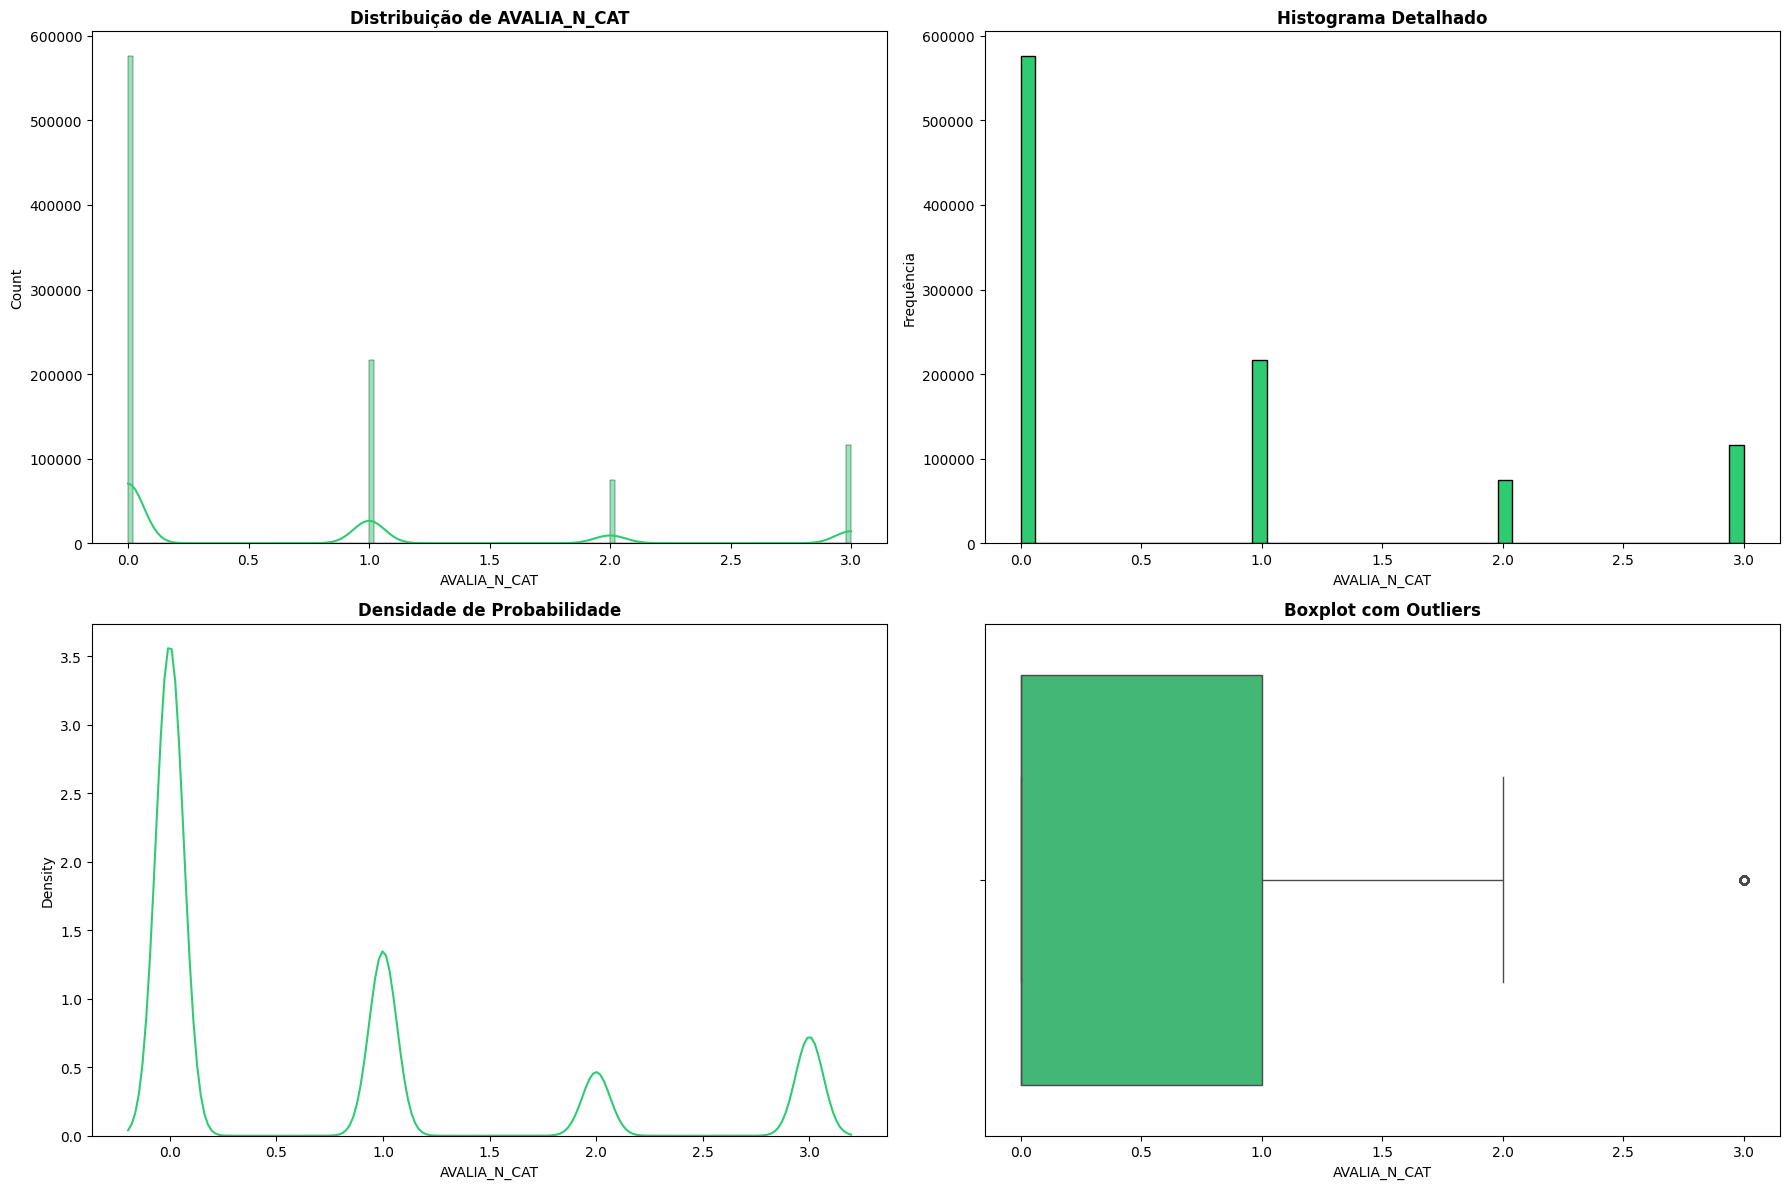

In [23]:
# Exemplo para AVALIA_N_CAT
relatorio = analise_univariada(df_dados, 'AVALIA_N_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### CLASSOPERA (Tratada para CLASSOPERA_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  1.660127      2.0       0.479651   -0.598412 -1.431747   

   Shapiro-Wilk (p-value)  
0           4.206857e-201  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
CLASSOPERA_CAT                                              
2                            643974                65.442184
1                            337254                34.272561
3                              2807                 0.285254
Outlierss
0 registros (0.00%)
Valores Distintos
[2, 1, 3]
Contagem de NaN
0 registros (0.00%)


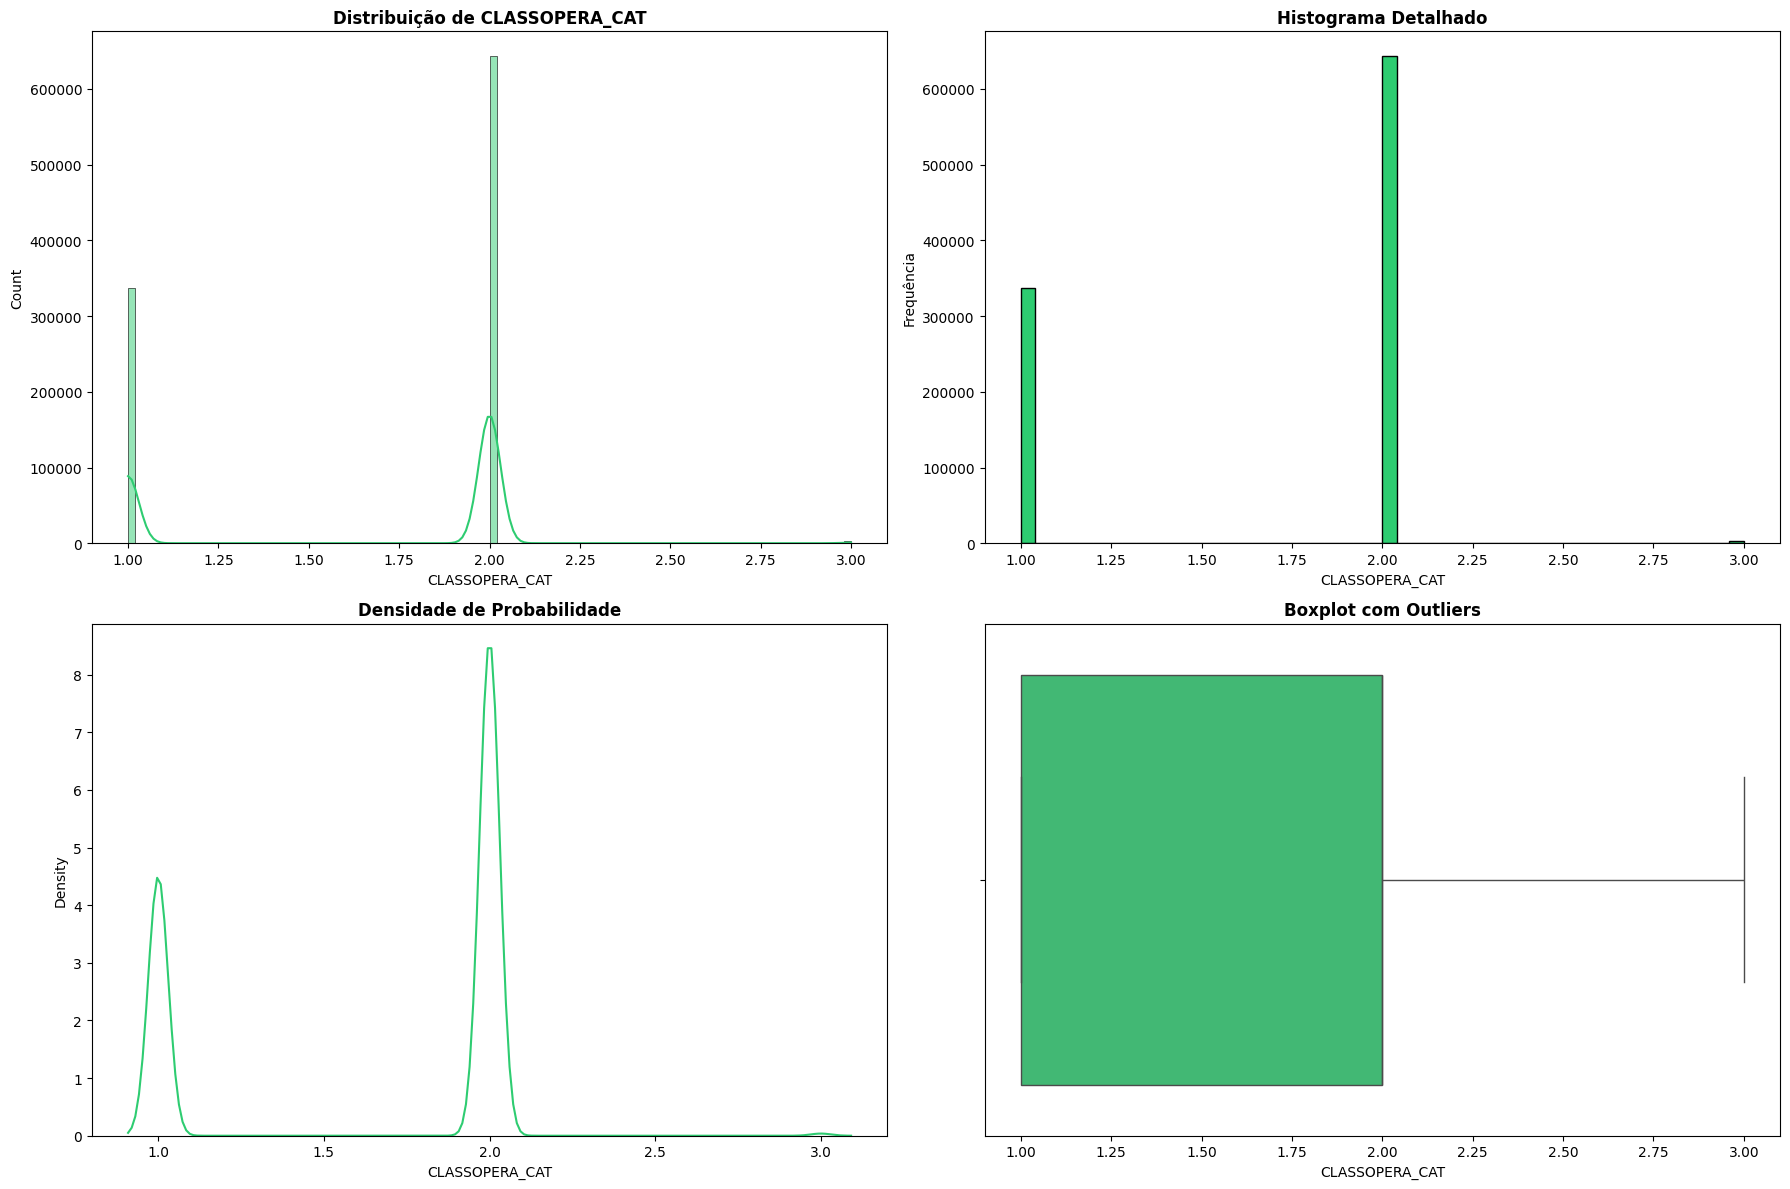

In [25]:
# Exemplo para CLASSOPERA_CAT
relatorio = analise_univariada(df_dados, 'CLASSOPERA_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### BACILOSCOP (Tratada para BACILOSCOP_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  5.749936      9.0       3.493339   -0.192778 -1.868441   

   Shapiro-Wilk (p-value)  
0           1.447581e-190  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
BACILOSCOP_CAT                                              
9                            521449                52.990900
3                            167509                17.022667
2                            167493                17.021041
1                            127584                12.965392
Outlierss
0 registros (0.00%)
Valores Distintos
[9, 1, 2, 3]
Contagem de NaN
0 registros (0.00%)


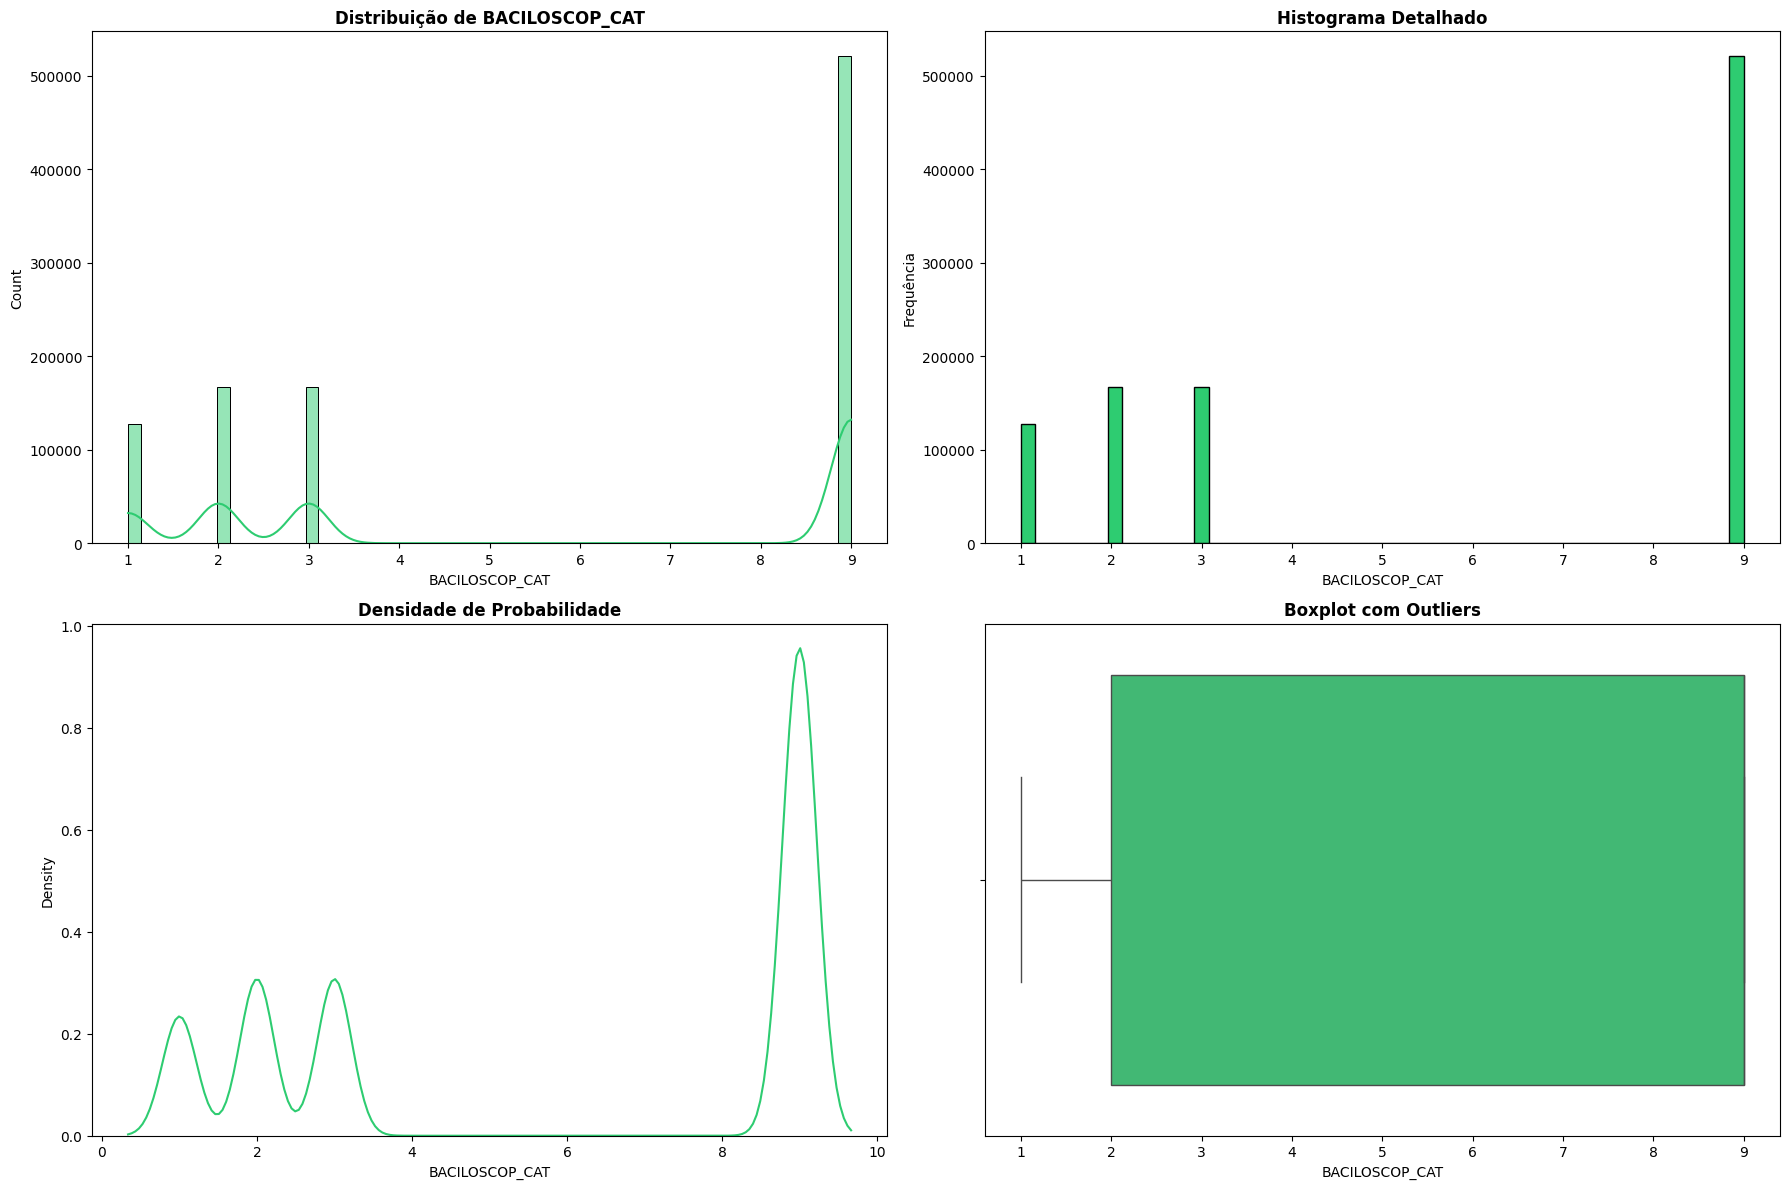

In [26]:
# Exemplo para BACILOSCOP_CAT
relatorio = analise_univariada(df_dados, 'BACILOSCOP_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### ESQ_INI_N (Tratada para ESQ_INI_N_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria    Curtose  \
0  1.757799      2.0       0.761402    4.153913  37.732139   

   Shapiro-Wilk (p-value)  
0           1.569403e-204  
Top 10 Frequências
               Frequência Absoluta  Frequência Relativa (%)
ESQ_INI_N_CAT                                              
2                           586425                59.593917
1                           332384                33.777660
3                            60422                 6.140229
9                             4804                 0.488194
Outlierss
4804 registros (0.49%)
Valores Distintos
[3, 1, 2, 9]
Contagem de NaN
0 registros (0.00%)


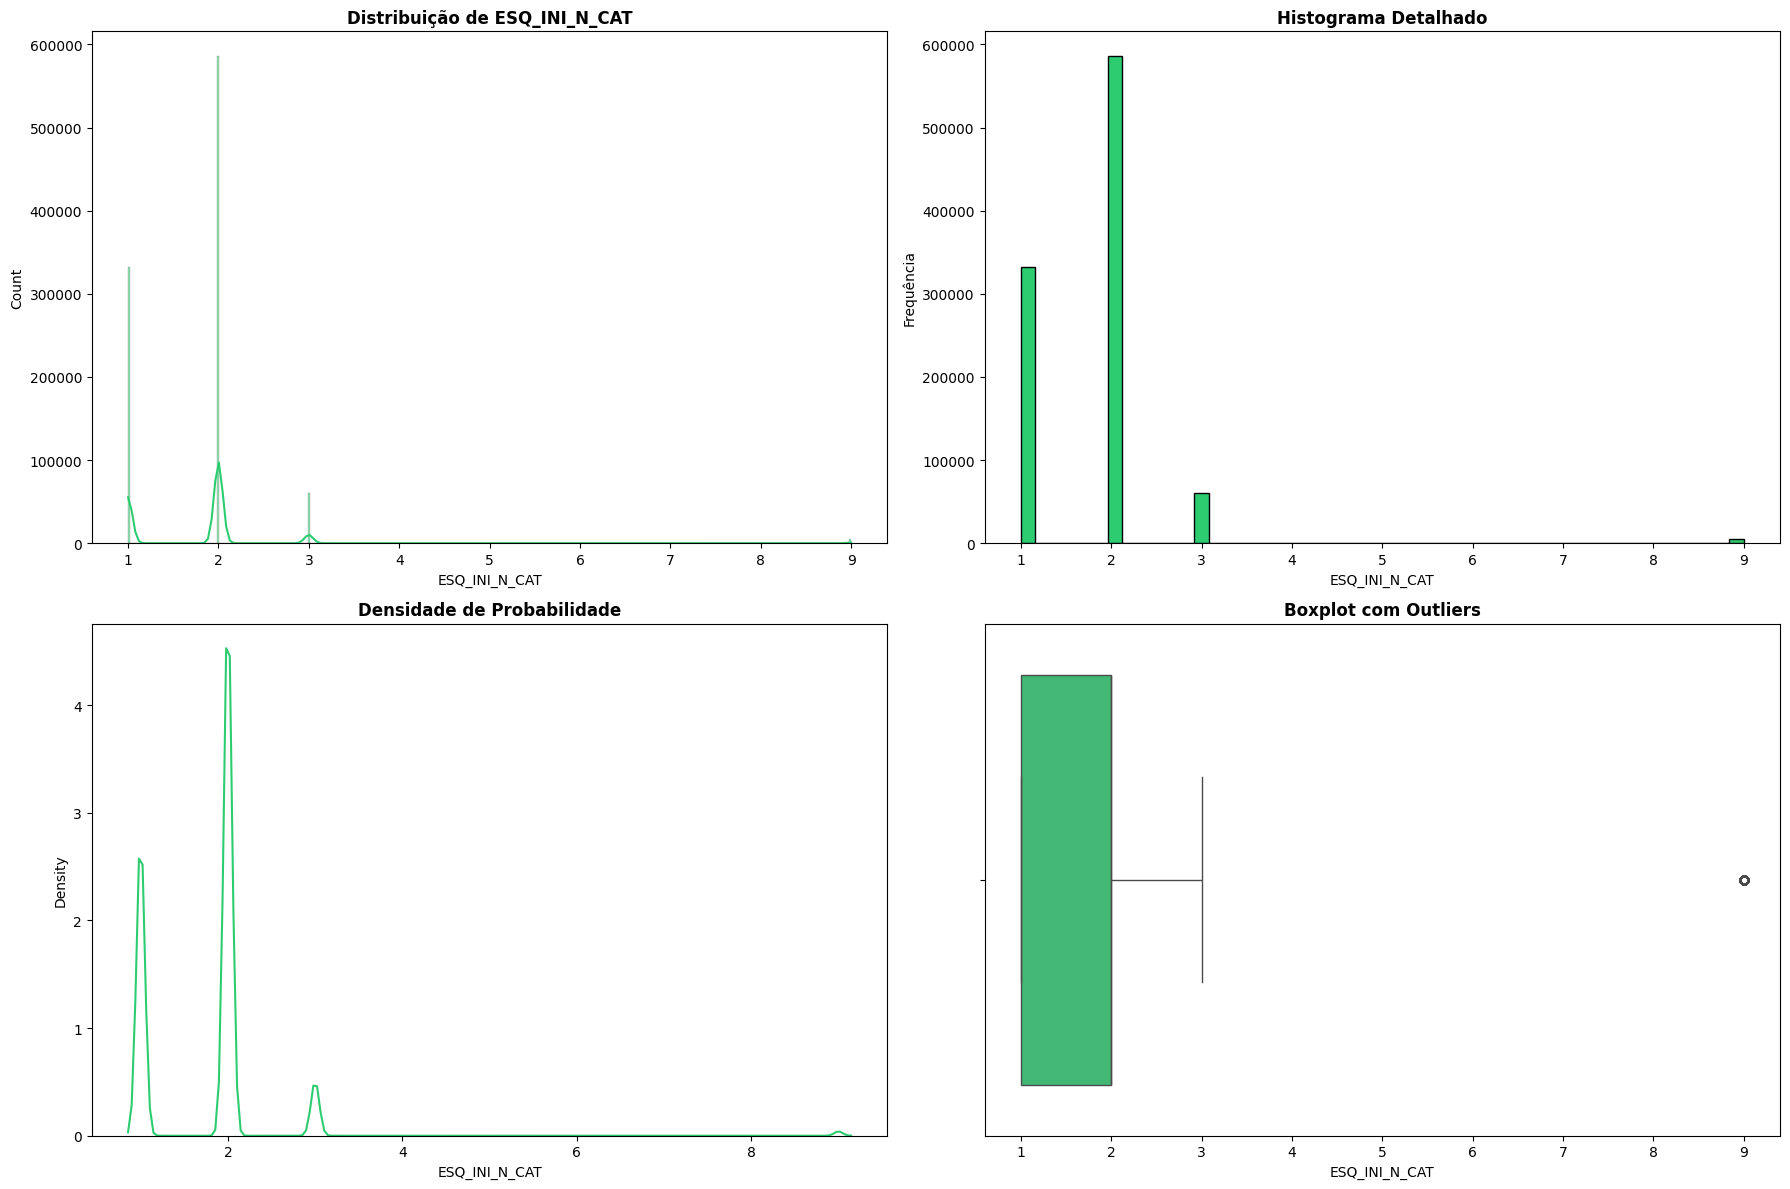

In [28]:
# Exemplo para ESQ_INI_N_CAT
relatorio = analise_univariada(df_dados, 'ESQ_INI_N_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### CONTREG (Tratada para CONTREG_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria     Curtose  \
0  3.101909      3.0        3.05302    6.558785  144.584315   

   Shapiro-Wilk (p-value)  
0           7.345824e-189  
Top 10 Frequências
             Frequência Absoluta  Frequência Relativa (%)
CONTREG_CAT                                              
3                         175106                17.794692
0                         166110                16.880497
2                         159730                16.232146
4                         131789                13.392715
1                         129446                13.154613
5                          83026                 8.437302
6                          51082                 5.191076
7                          29617                 3.009751
8                          19895                 2.021778
9                          12070                 1.226582
Outlierss
38234 registros (3.89%)
Valores Distintos
[0, 3, 1, 4, 2, 5, 6, 7, 

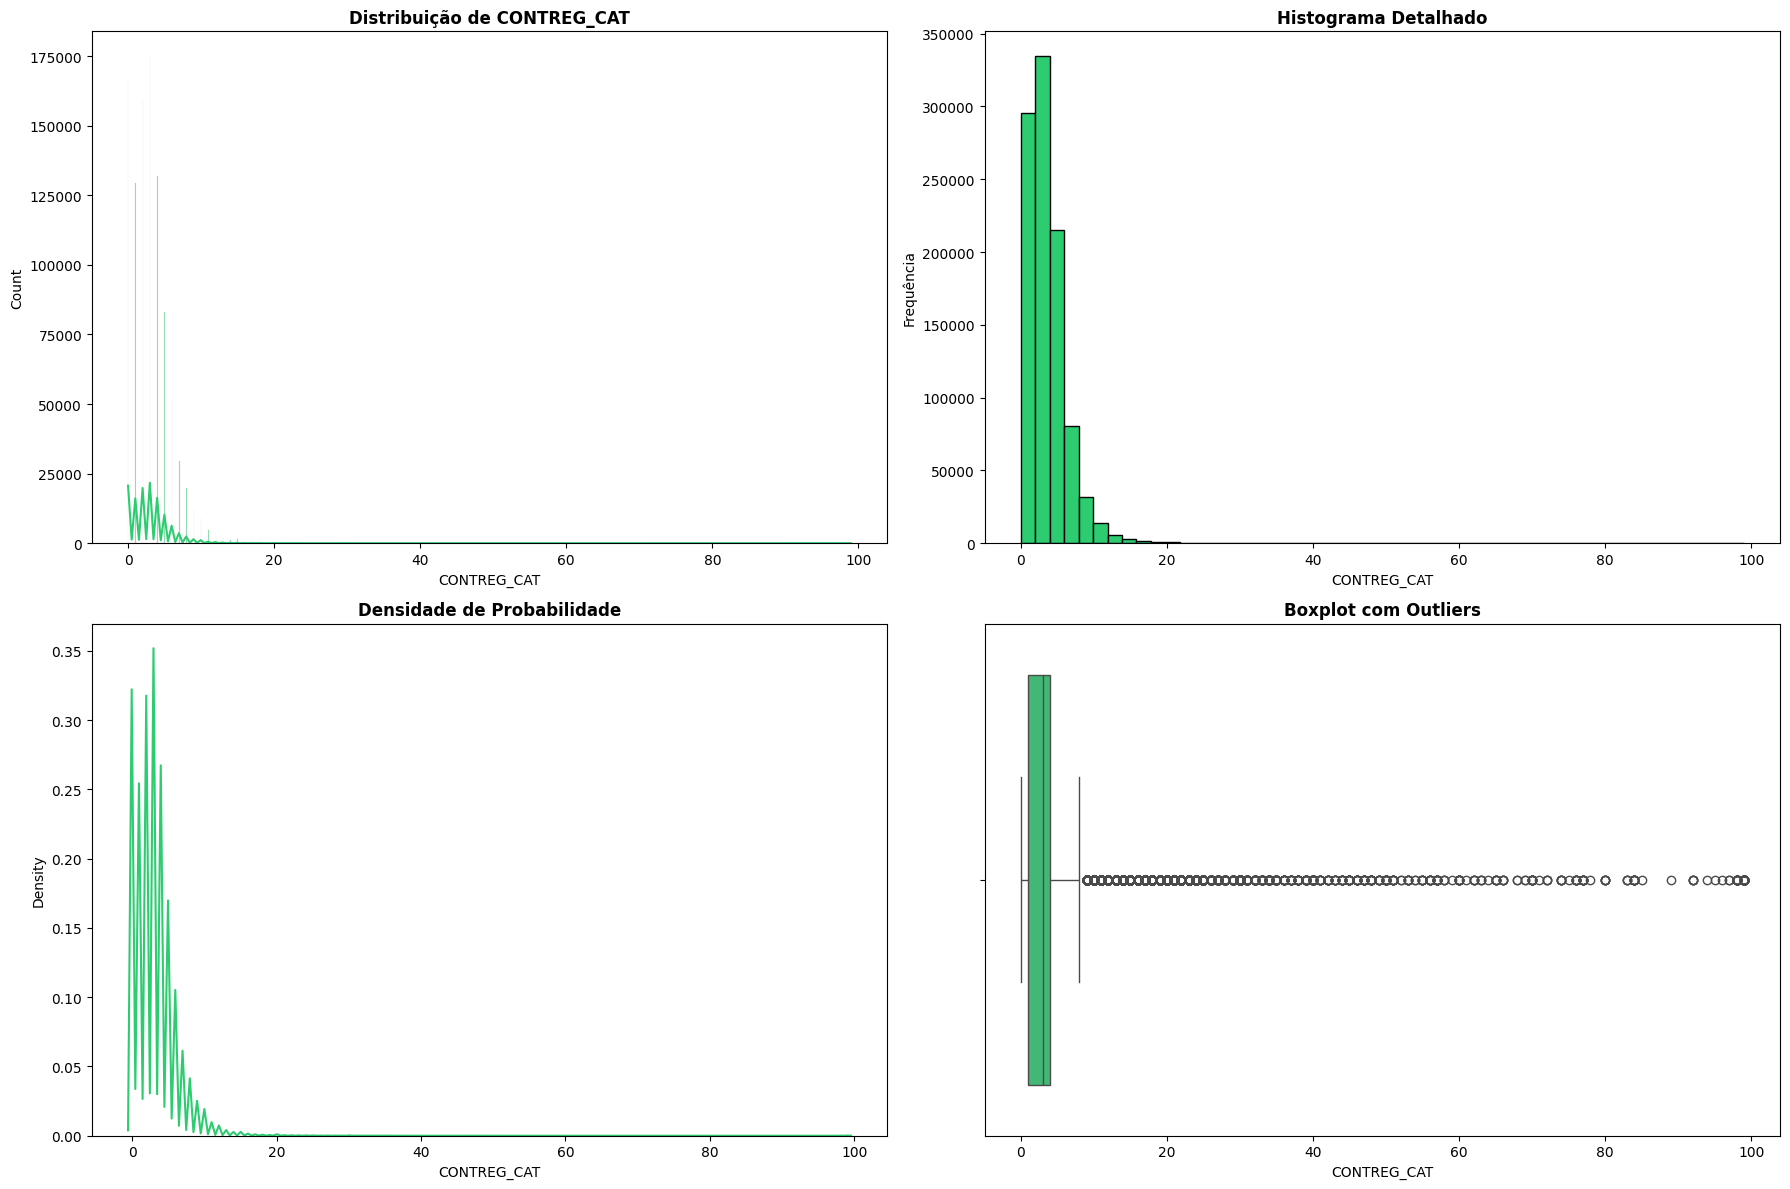

In [29]:
# Exemplo para CONTREG_CAT
relatorio = analise_univariada(df_dados, 'CONTREG_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### NERVOSAFET (Tratado para NERVOSAFET_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
     Média  Mediana  Desvio Padrão  Assimetria     Curtose  \
0  0.79169      0.0       1.928401    9.300637  328.079289   

   Shapiro-Wilk (p-value)  
0           1.885280e-214  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
NERVOSAFET_CAT                                              
0                            734135                74.604562
2                             72115                 7.328499
1                             63568                 6.459933
4                             35316                 3.588897
3                             31472                 3.198260
6                             14199                 1.442936
5                             13288                 1.350358
8                              7007                 0.712068
10                             4609                 0.468378
7                              4178                 0.424578
Outlierss
114217 registros (11.61%)
Valores

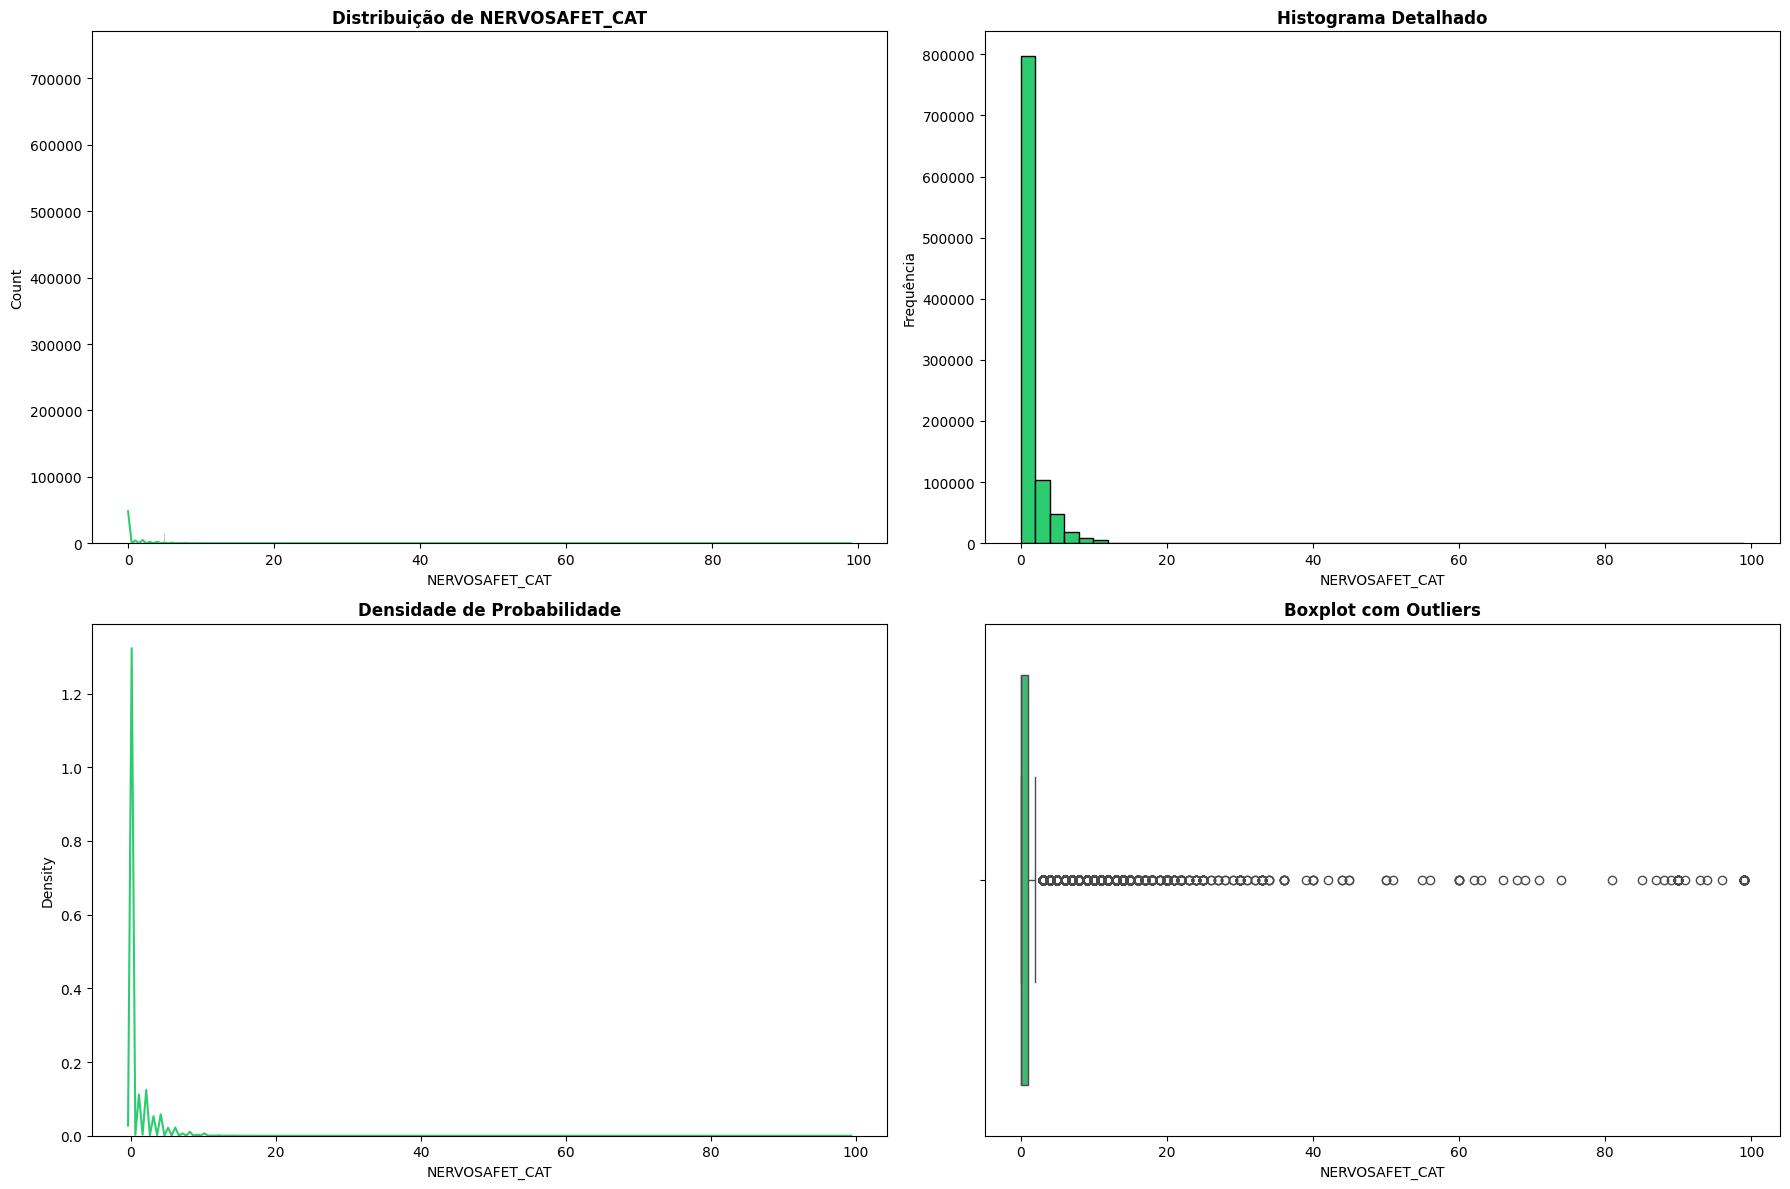

In [30]:
# Exemplo para NERVOSAFET_CAT
relatorio = analise_univariada(df_dados, 'NERVOSAFET_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### CLASSATUAL

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  1.657875      2.0       0.480052   -0.738275 -1.259604   

   Shapiro-Wilk (p-value)  
0           9.086835e-202  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
CLASSATUAL_CAT                                              
2                            650016                66.056187
1                            331375                33.675123
0                              2644                 0.268690
Outlierss
0 registros (0.00%)
Valores Distintos
[2, 1, 0]
Contagem de NaN
0 registros (0.00%)


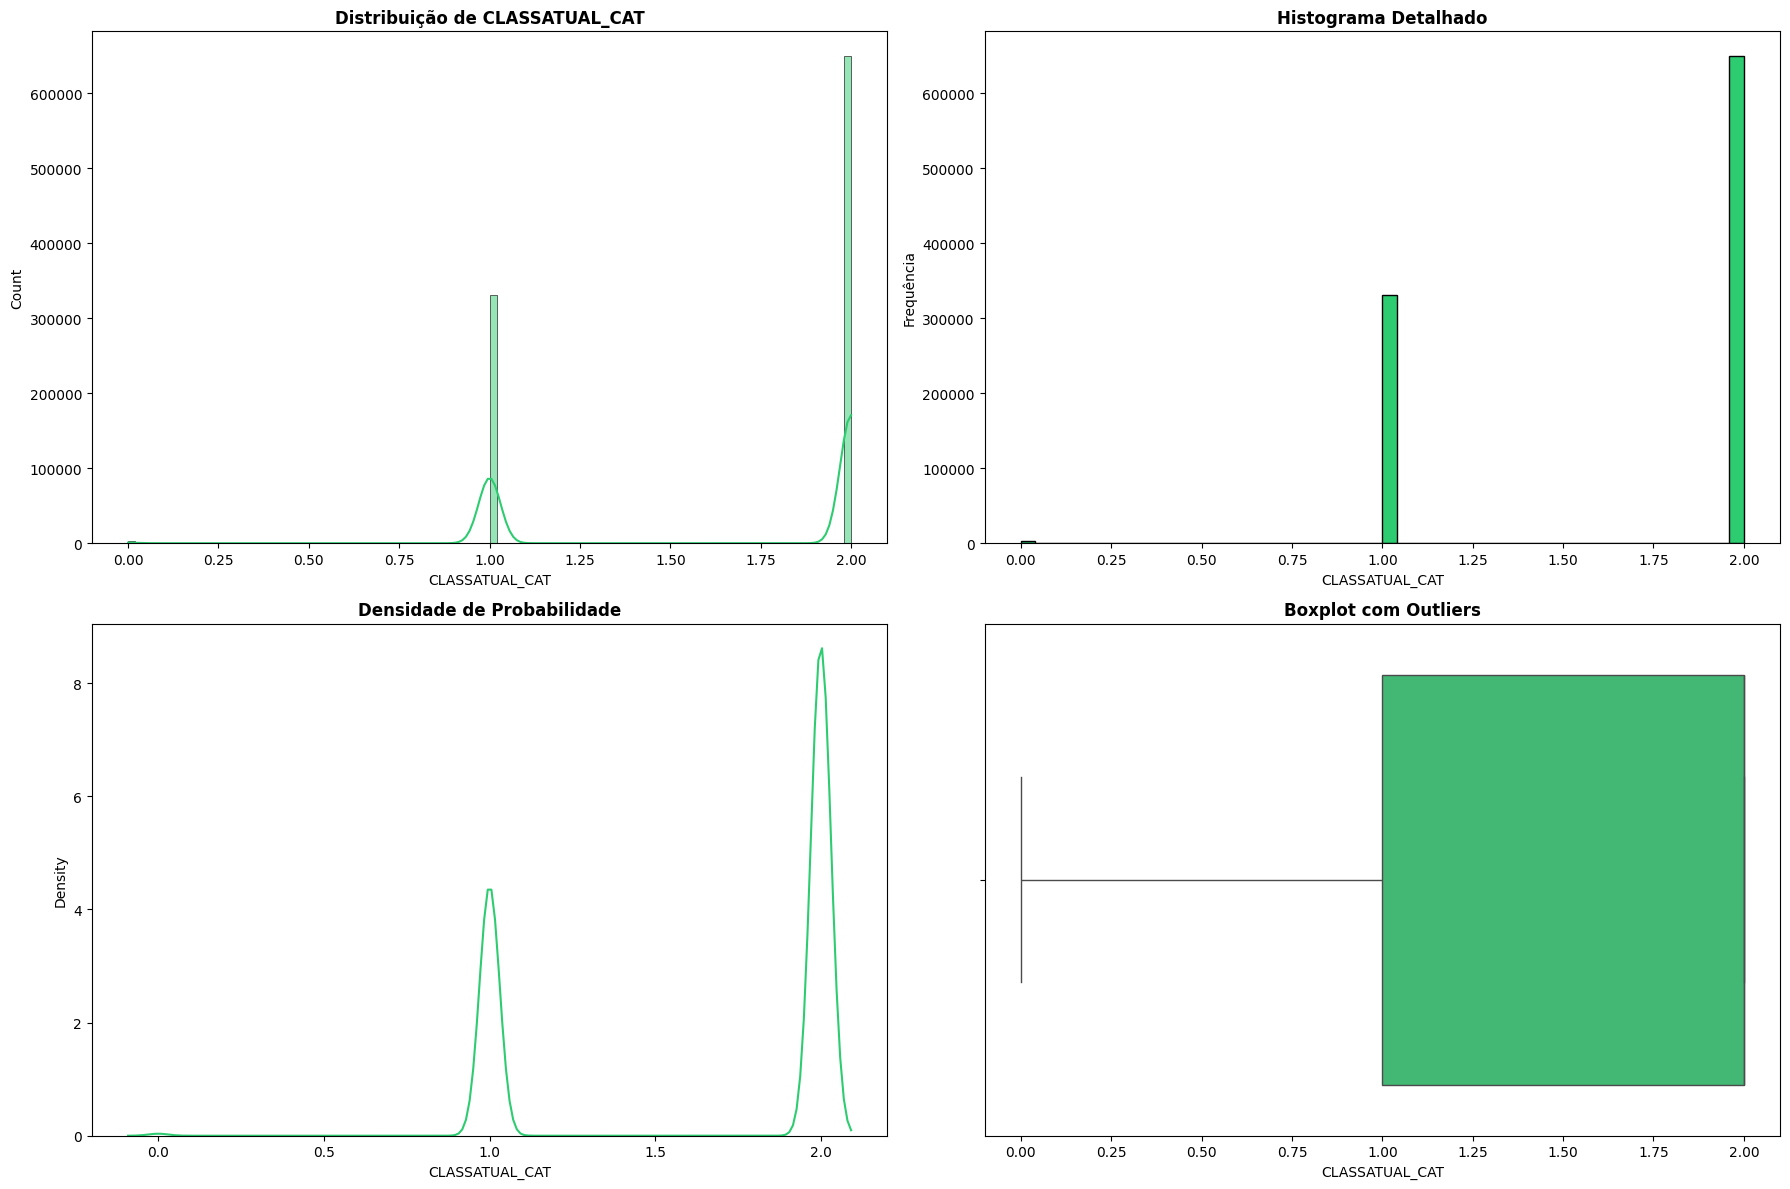

In [32]:
# Exemplo para CLASSATUAL
relatorio = analise_univariada(df_dados, 'CLASSATUAL_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### AVAL_ATU_N (CATEGORIZADA PARA `AVAL_ATU_N_CAT`)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  3.218904      1.0       3.773638    0.735292 -1.217451   

   Shapiro-Wilk (p-value)  
0           5.979723e-189  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
AVAL_ATU_N_CAT                                              
0                            406518                41.311335
9                            277218                28.171559
3                            168595                17.133029
1                             96641                 9.820891
2                             35063                 3.563186
Outlierss
0 registros (0.00%)
Valores Distintos
[0, 2, 3, 1, 9]
Contagem de NaN
0 registros (0.00%)


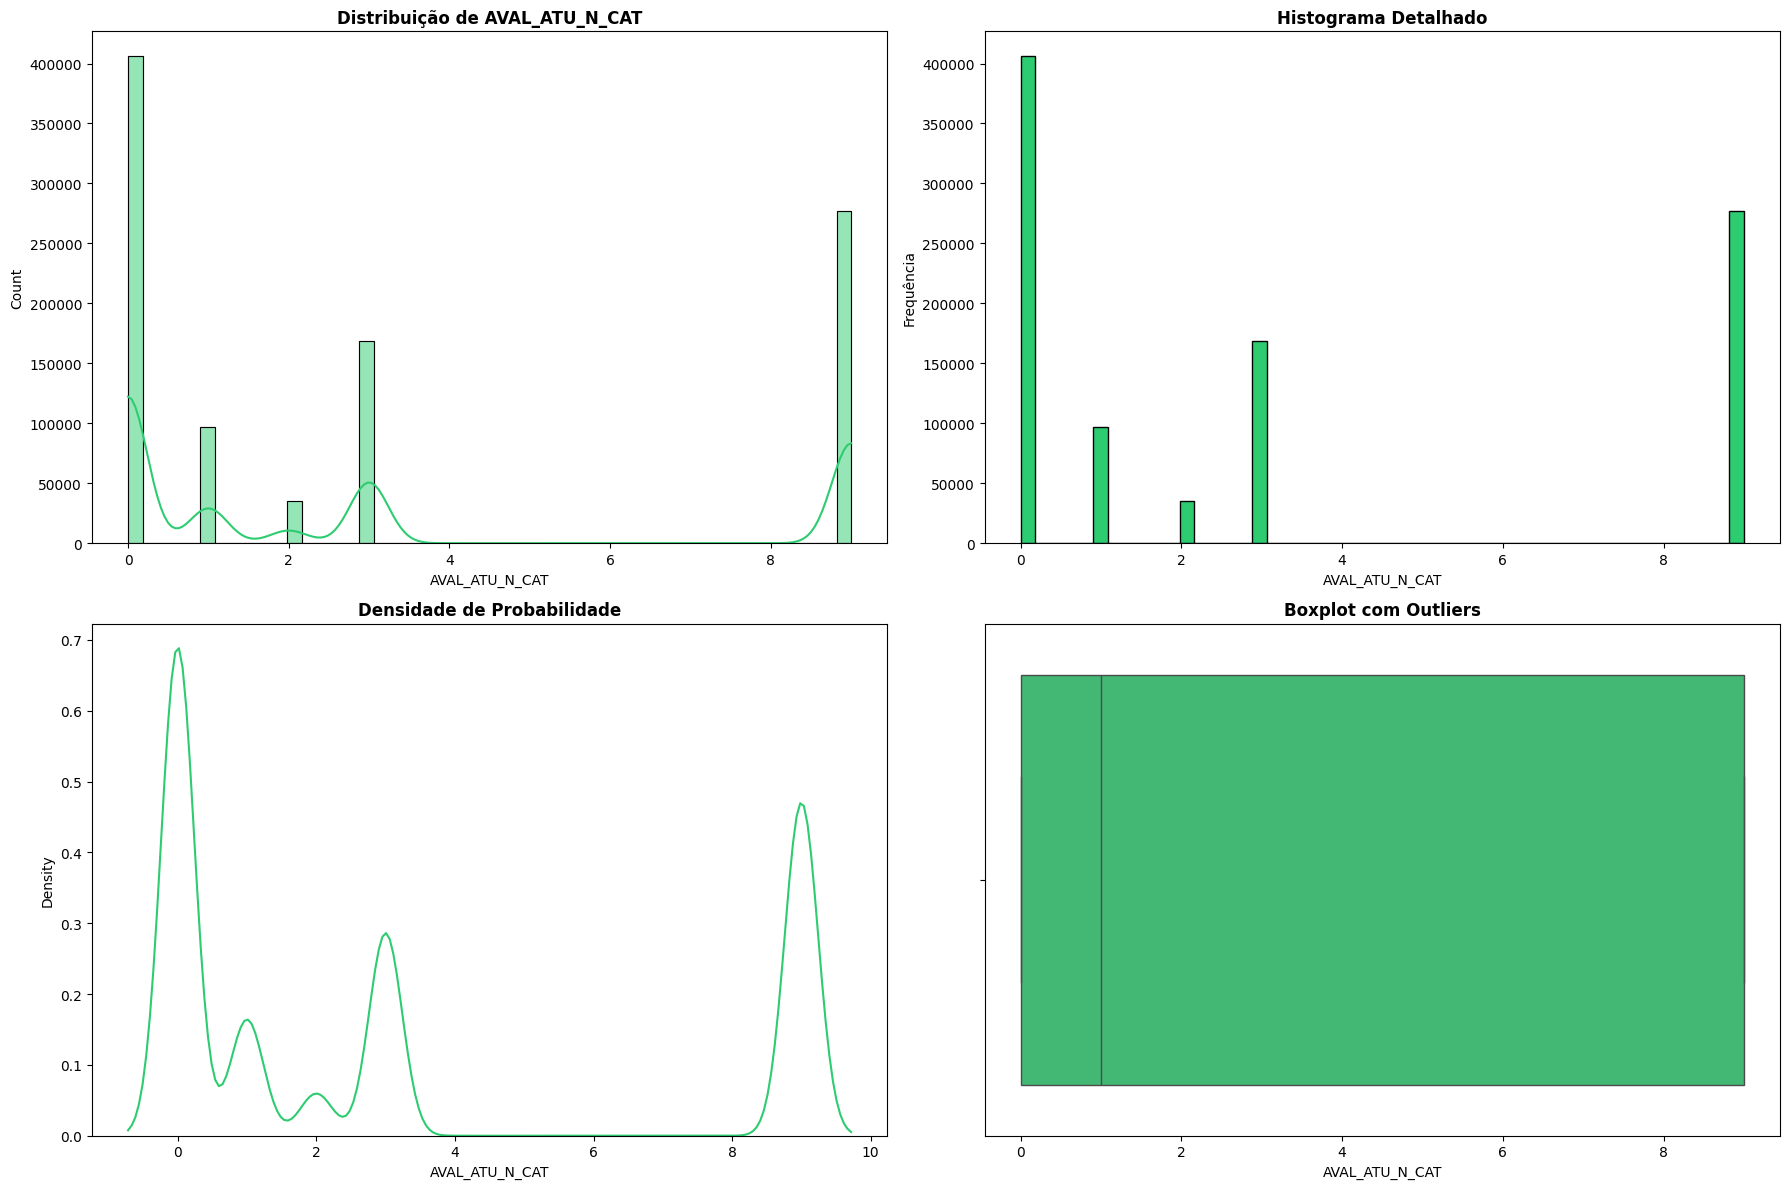

In [33]:
# Exemplo para AVAL_ATU_N
relatorio = analise_univariada(df_dados, 'AVAL_ATU_N_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### ESQ_ATU_N (Tratado para ESQ_ATU_N_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria    Curtose  \
0  1.851607      2.0       1.011607     4.53726  29.852363   

   Shapiro-Wilk (p-value)  
0           2.583612e-209  
Top 10 Frequências
               Frequência Absoluta  Frequência Relativa (%)
ESQ_ATU_N_CAT                                              
2                           572013                58.129335
1                           317564                32.271616
3                            81611                 8.293506
9                            12847                 1.305543
Outlierss
12847 registros (1.31%)
Valores Distintos
[3, 1, 2, 9]
Contagem de NaN
0 registros (0.00%)


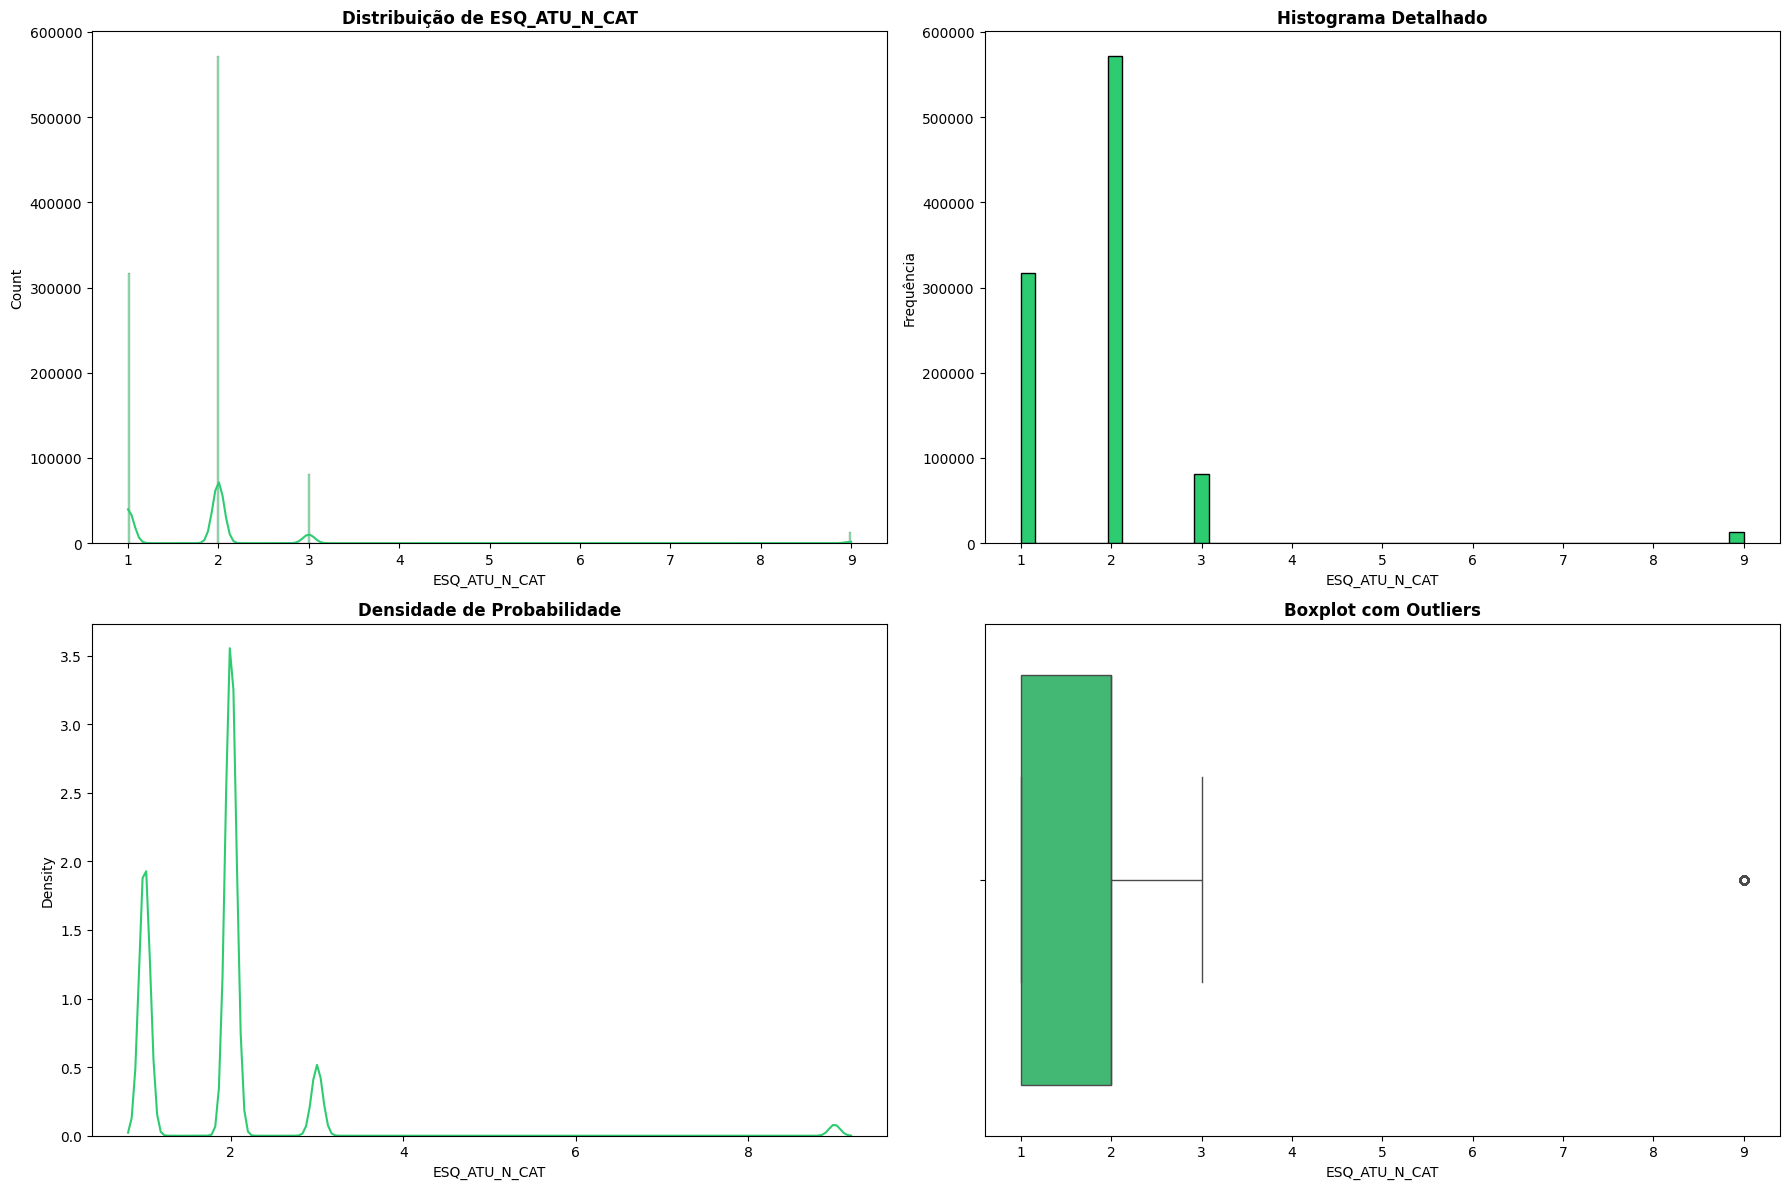

In [34]:
# Exemplo para ESQ_ATU_N_CAT
relatorio = analise_univariada(df_dados, 'ESQ_ATU_N_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### DOSE_RECEB (Tratada para DOSE_RECEB_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  6.069043      6.0       5.731076    0.697061  1.610193   

   Shapiro-Wilk (p-value)  
0           9.747219e-173  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
DOSE_RECEB_CAT                                              
0                            337140                34.260976
12                           304305                30.924205
6                            159536                16.212431
1                             32107                 3.262790
2                             19022                 1.933061
3                             16477                 1.674432
5                             15682                 1.593643
4                             15586                 1.583887
24                            12891                 1.310014
7                             11733                 1.192336
Outlierss
596 registros (0.06%)
Valores Disti

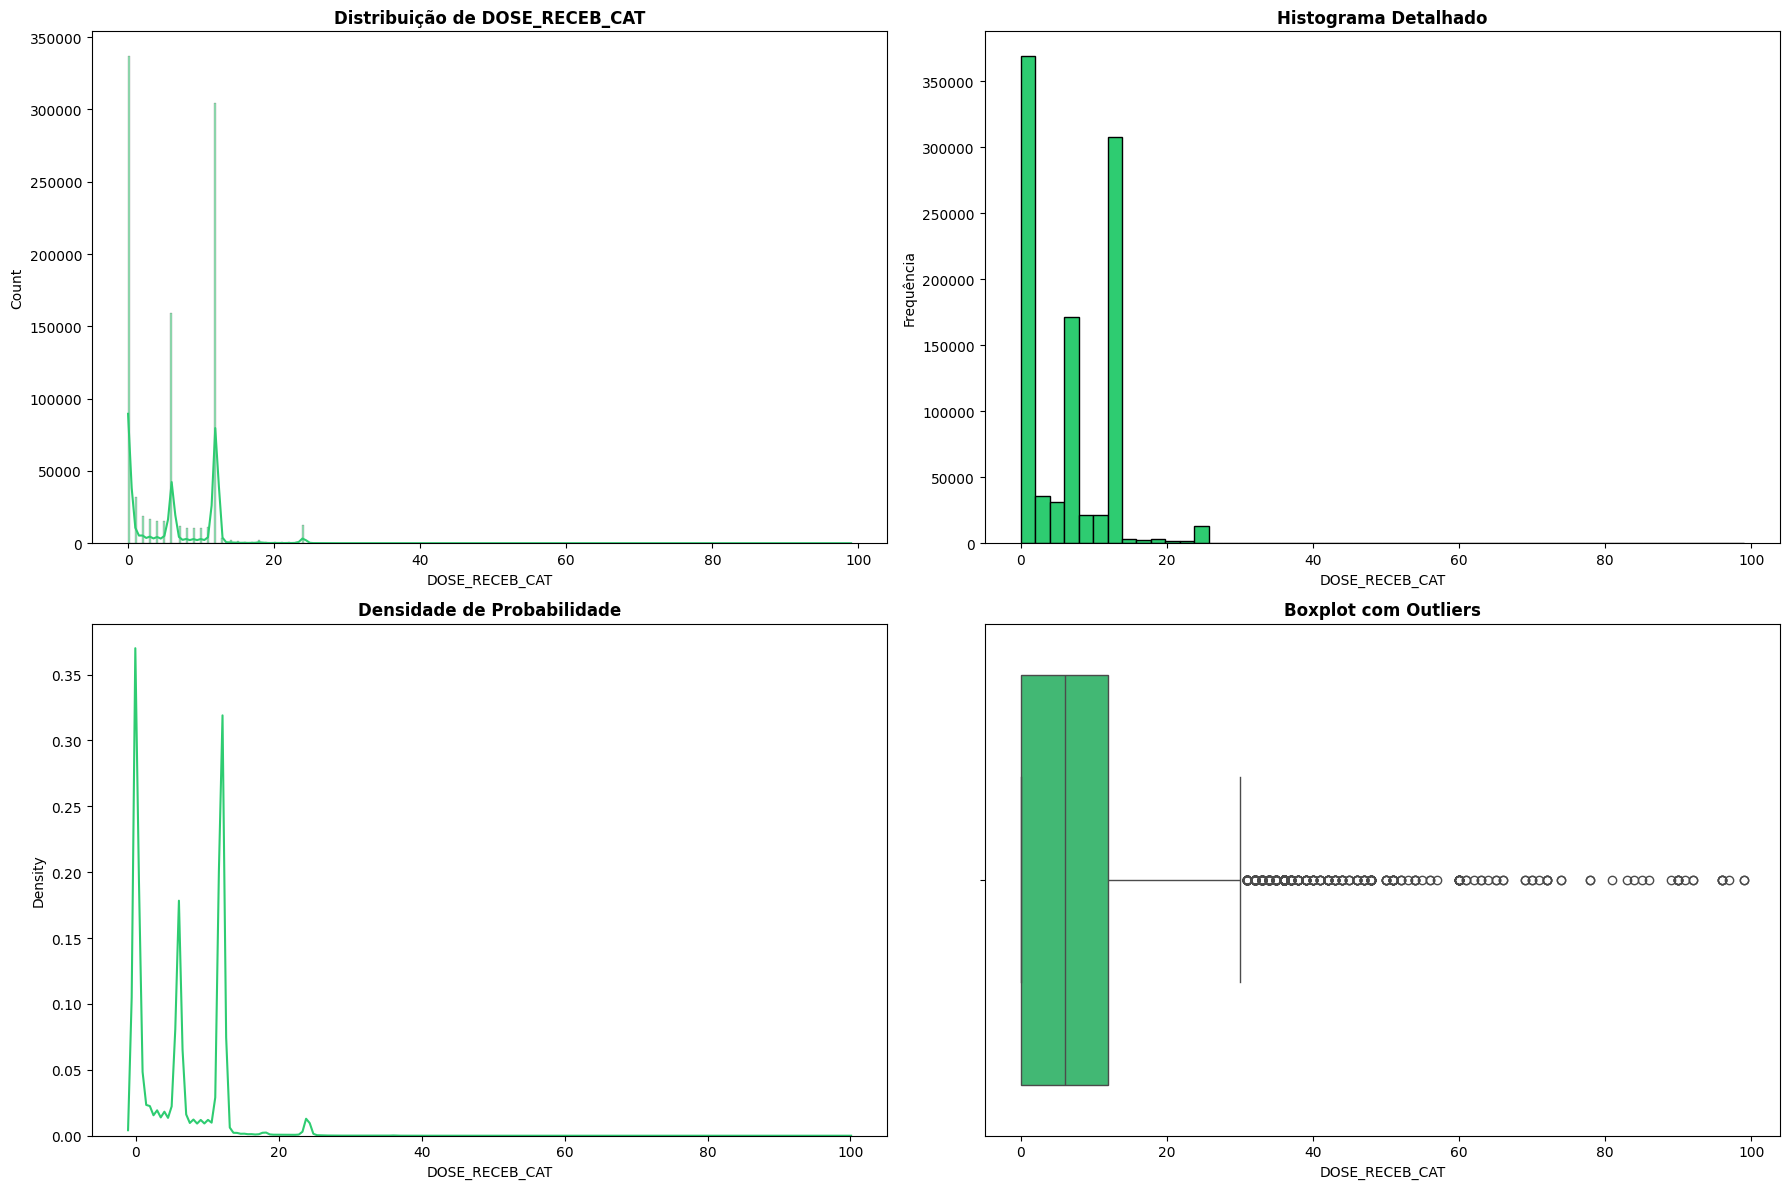

In [35]:
# Exemplo para DOSE_RECEB_CAT
relatorio = analise_univariada(df_dados, 'DOSE_RECEB_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### EPIS_RACIO (Tratado para EPIS_RACIO_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  6.046978      4.0       2.849355   -0.116143 -1.547665   

   Shapiro-Wilk (p-value)  
0           2.532790e-185  
Top 10 Frequências
                Frequência Absoluta  Frequência Relativa (%)
EPIS_RACIO_CAT                                              
9                            455448                46.283720
4                            427152                43.408212
1                             70134                 7.127186
2                             21239                 2.158358
3                             10062                 1.022525
Outlierss
0 registros (0.00%)
Valores Distintos
[9, 4, 1, 3, 2]
Contagem de NaN
0 registros (0.00%)


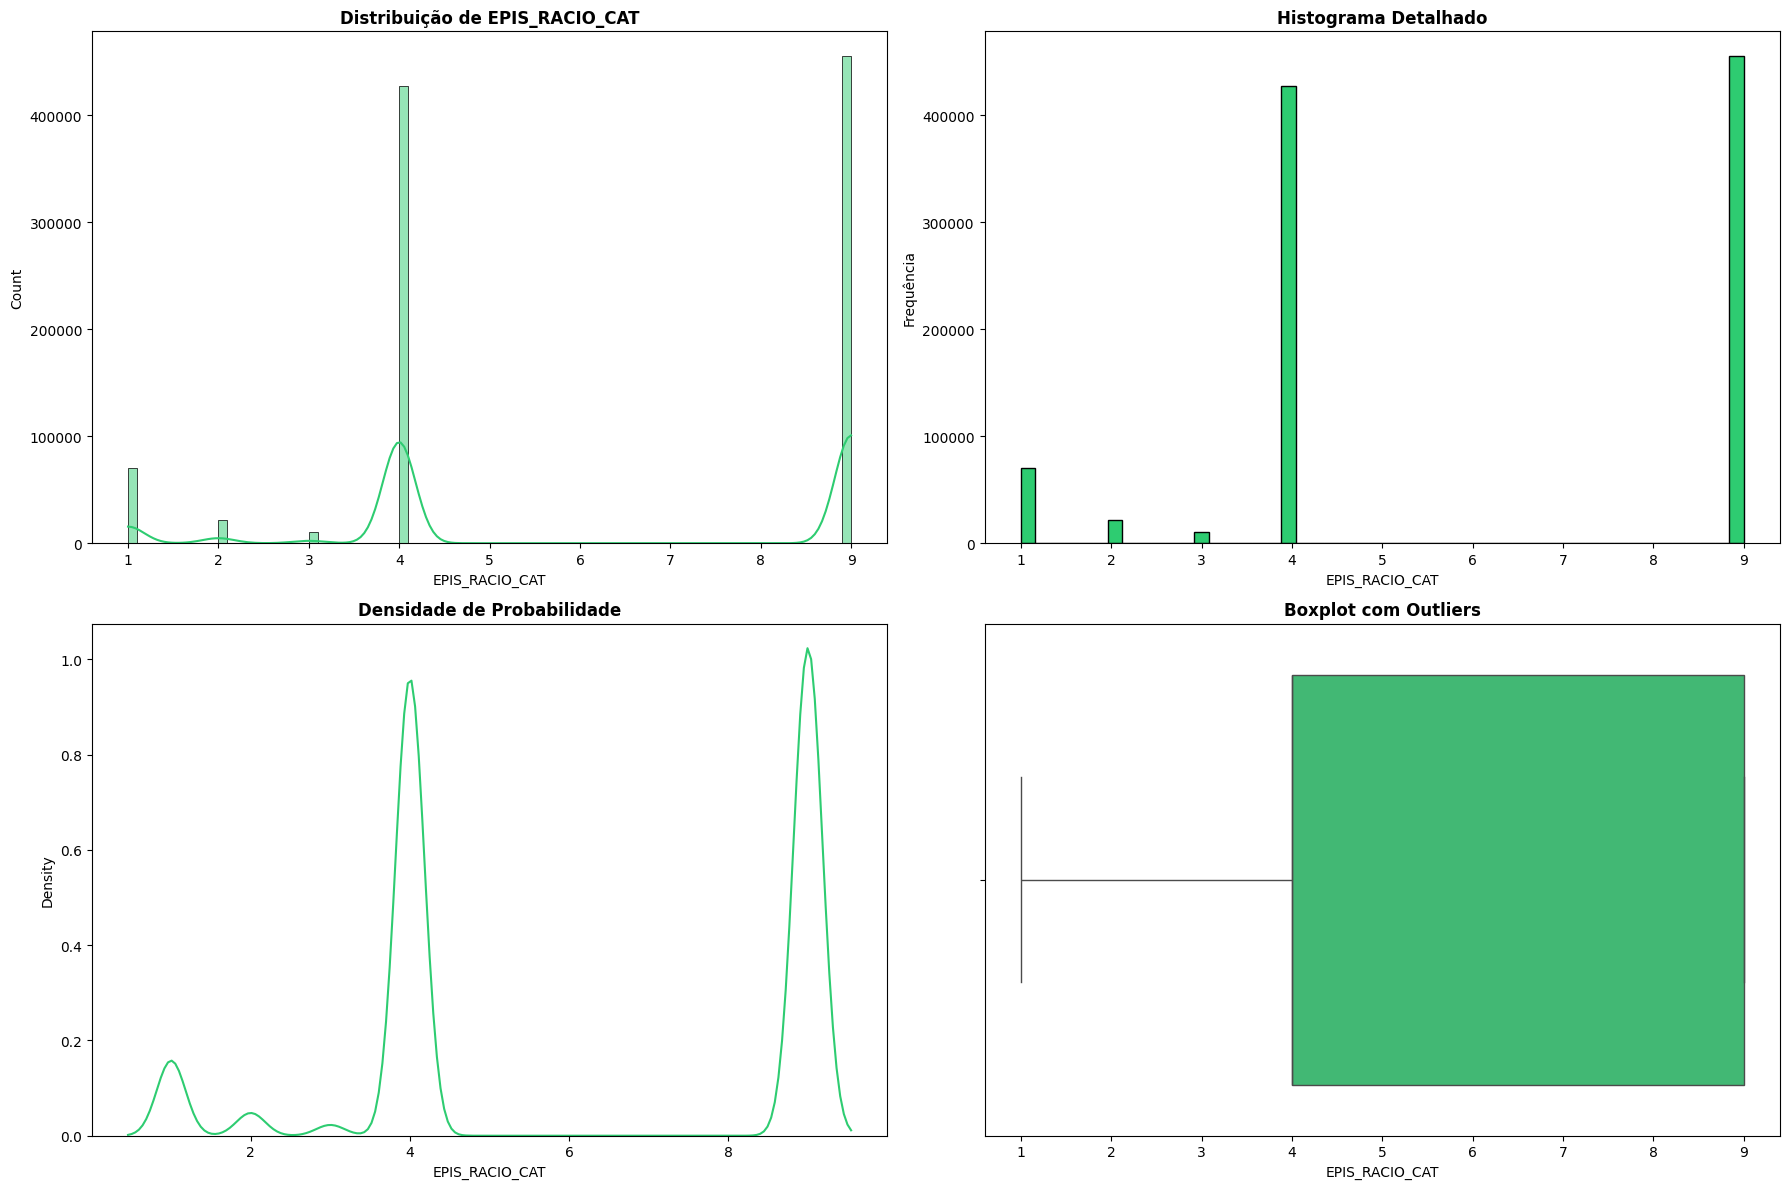

In [36]:
# Exemplo para EPIS_RACIO_CAT
relatorio = analise_univariada(df_dados, 'EPIS_RACIO_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### CONTEXAM (Tratado para CONTEXAM_CAT)

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
      Média  Mediana  Desvio Padrão  Assimetria     Curtose  \
0  2.088358      1.0        2.77698    7.138351  171.683401   

   Shapiro-Wilk (p-value)  
0           8.280697e-196  
Top 10 Frequências
              Frequência Absoluta  Frequência Relativa (%)
CONTEXAM_CAT                                              
0                          367354                37.331396
2                          138079                14.031920
1                          131093                13.321985
3                          129476                13.157662
4                           87420                 8.883830
5                           51298                 5.213026
6                           30245                 3.073570
7                           16613                 1.688253
8                           11251                 1.143354
9                            6363                 0.646623
Outlierss
32457 registros (3.30%)
Valores Distintos
[0, 2, 1, 3, 

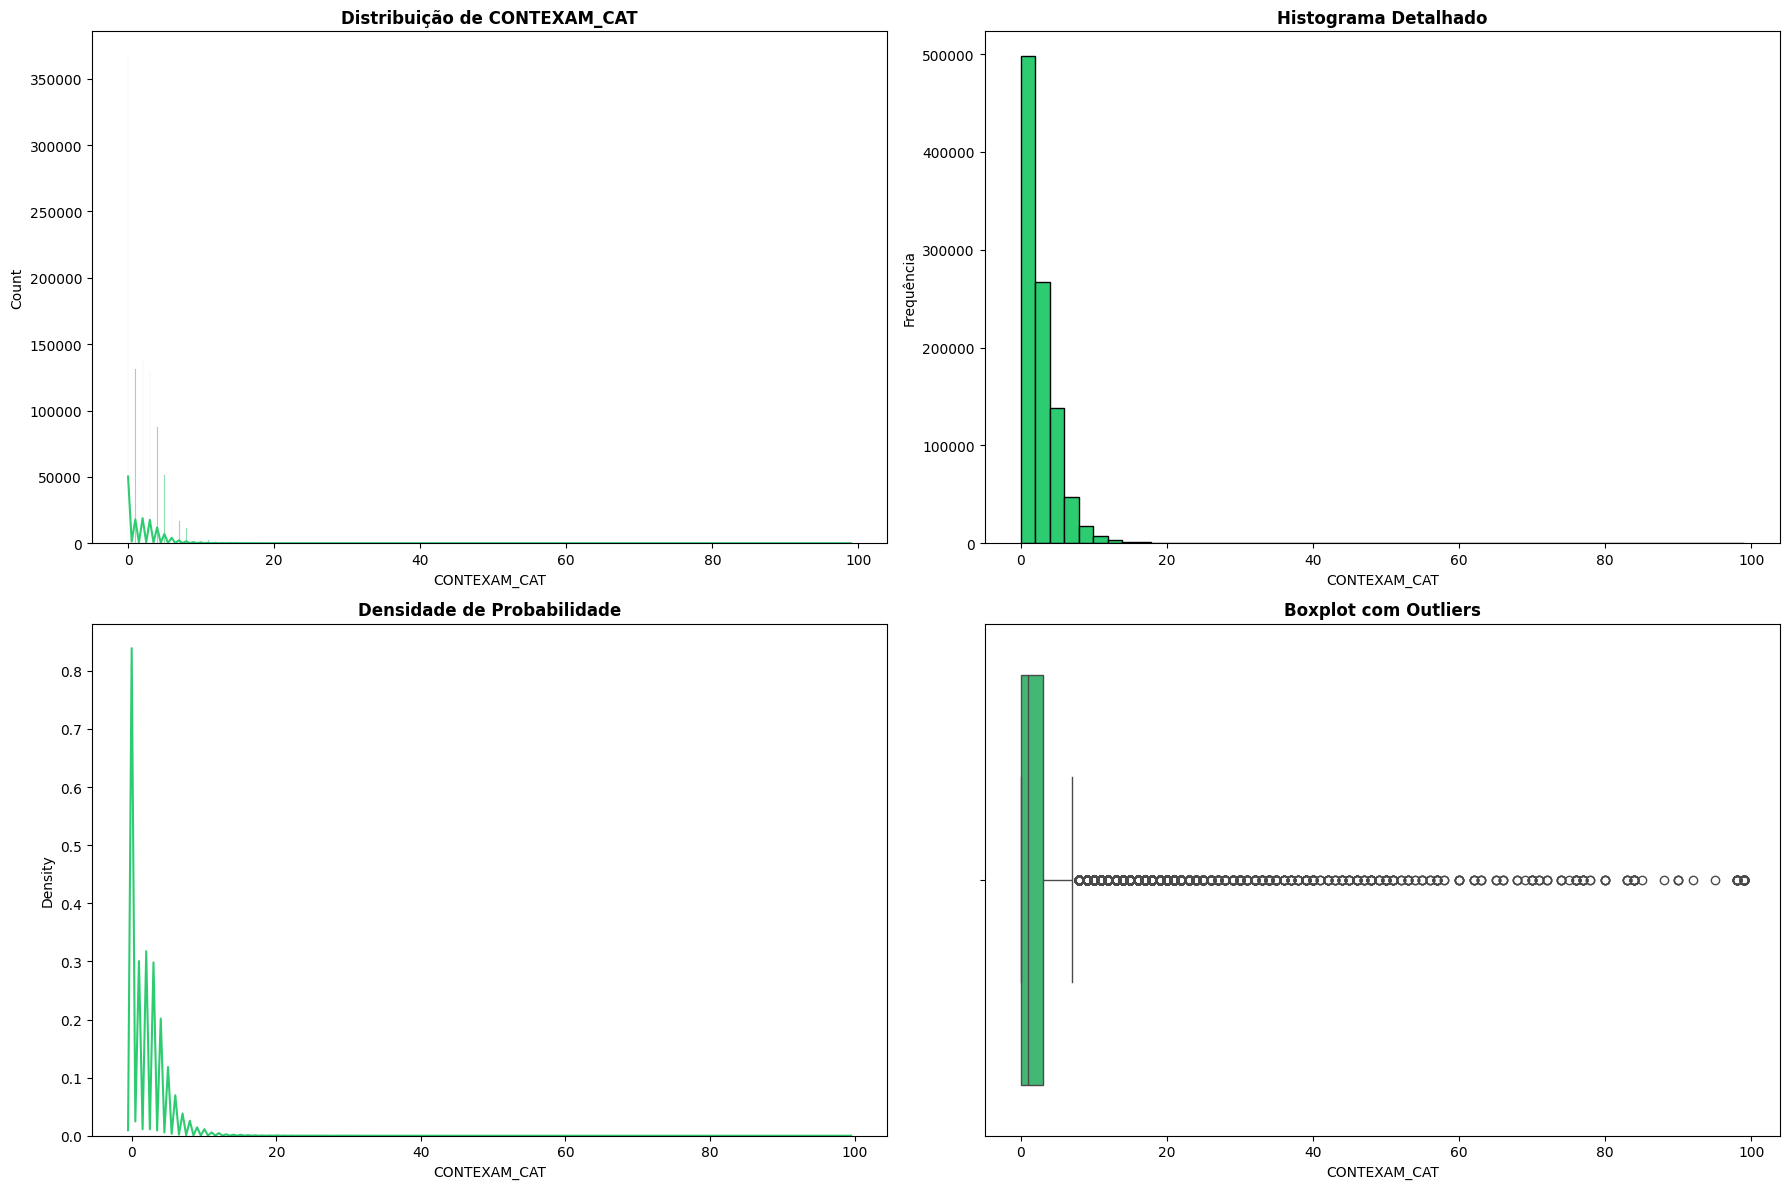

In [37]:
# Exemplo para CONTEXAM_CAT
relatorio = analise_univariada(df_dados, 'CONTEXAM_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

### TPALTA_N

d:\python\data_health\venv_health\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 984035.
  res = hypotest_fun_out(*samples, **kwds)


Estatísticas Descritivas
     Média  Mediana  Desvio Padrão  Assimetria   Curtose  \
0  2.34738      1.0        2.69816     1.70612  1.178742   

   Shapiro-Wilk (p-value)  
0           3.429125e-208  
Top 10 Frequências
              Frequência Absoluta  Frequência Relativa (%)
TPALTA_N_CAT                                              
1                          754121                76.635587
9                           88344                 8.977729
7                           55872                 5.677847
3                           30711                 3.120926
6                           14902                 1.514377
4                           13395                 1.361232
8                           13158                 1.337148
2                           12822                 1.303002
5                             710                 0.072152
Outlierss
229914 registros (23.36%)
Valores Distintos
[1, 9, 7, 6, 4, 5, 8, 3, 2]
Contagem de NaN
0 registros (0.00%)


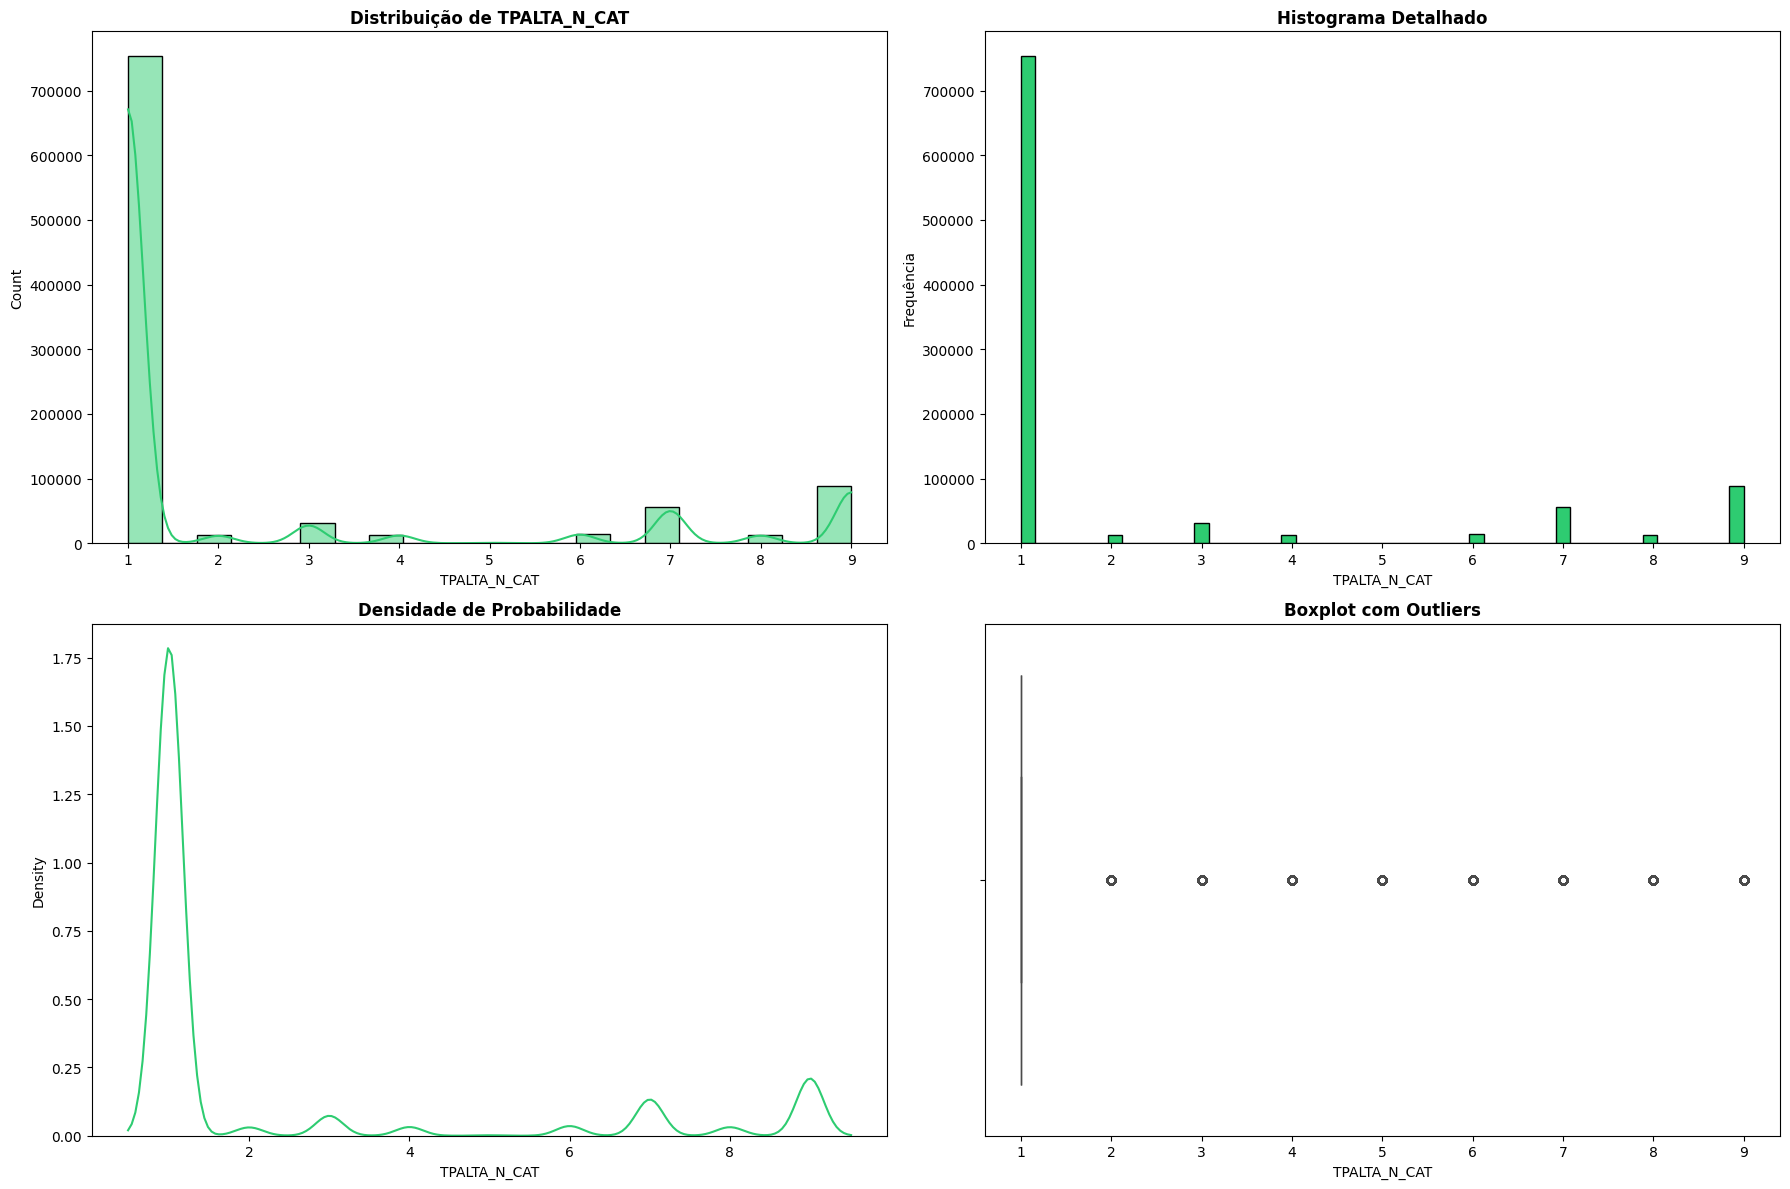

In [38]:
# Exemplo para TPALTA_N_CAT
relatorio = analise_univariada(df_dados, 'TPALTA_N_CAT')
relatorio['Gráficos']
print("Estatísticas Descritivas")
print(relatorio['Estatísticas Descritivas'])
print("Top 10 Frequências")
print(relatorio['Top 10 Frequências']) 
print("Outlierss")
print(relatorio['Outliers'])
print("Valores Distintos")
print(relatorio['Valores Distintos'])
print("Contagem de NaN")
print(relatorio['Contagem de NaN'])

## Correlação

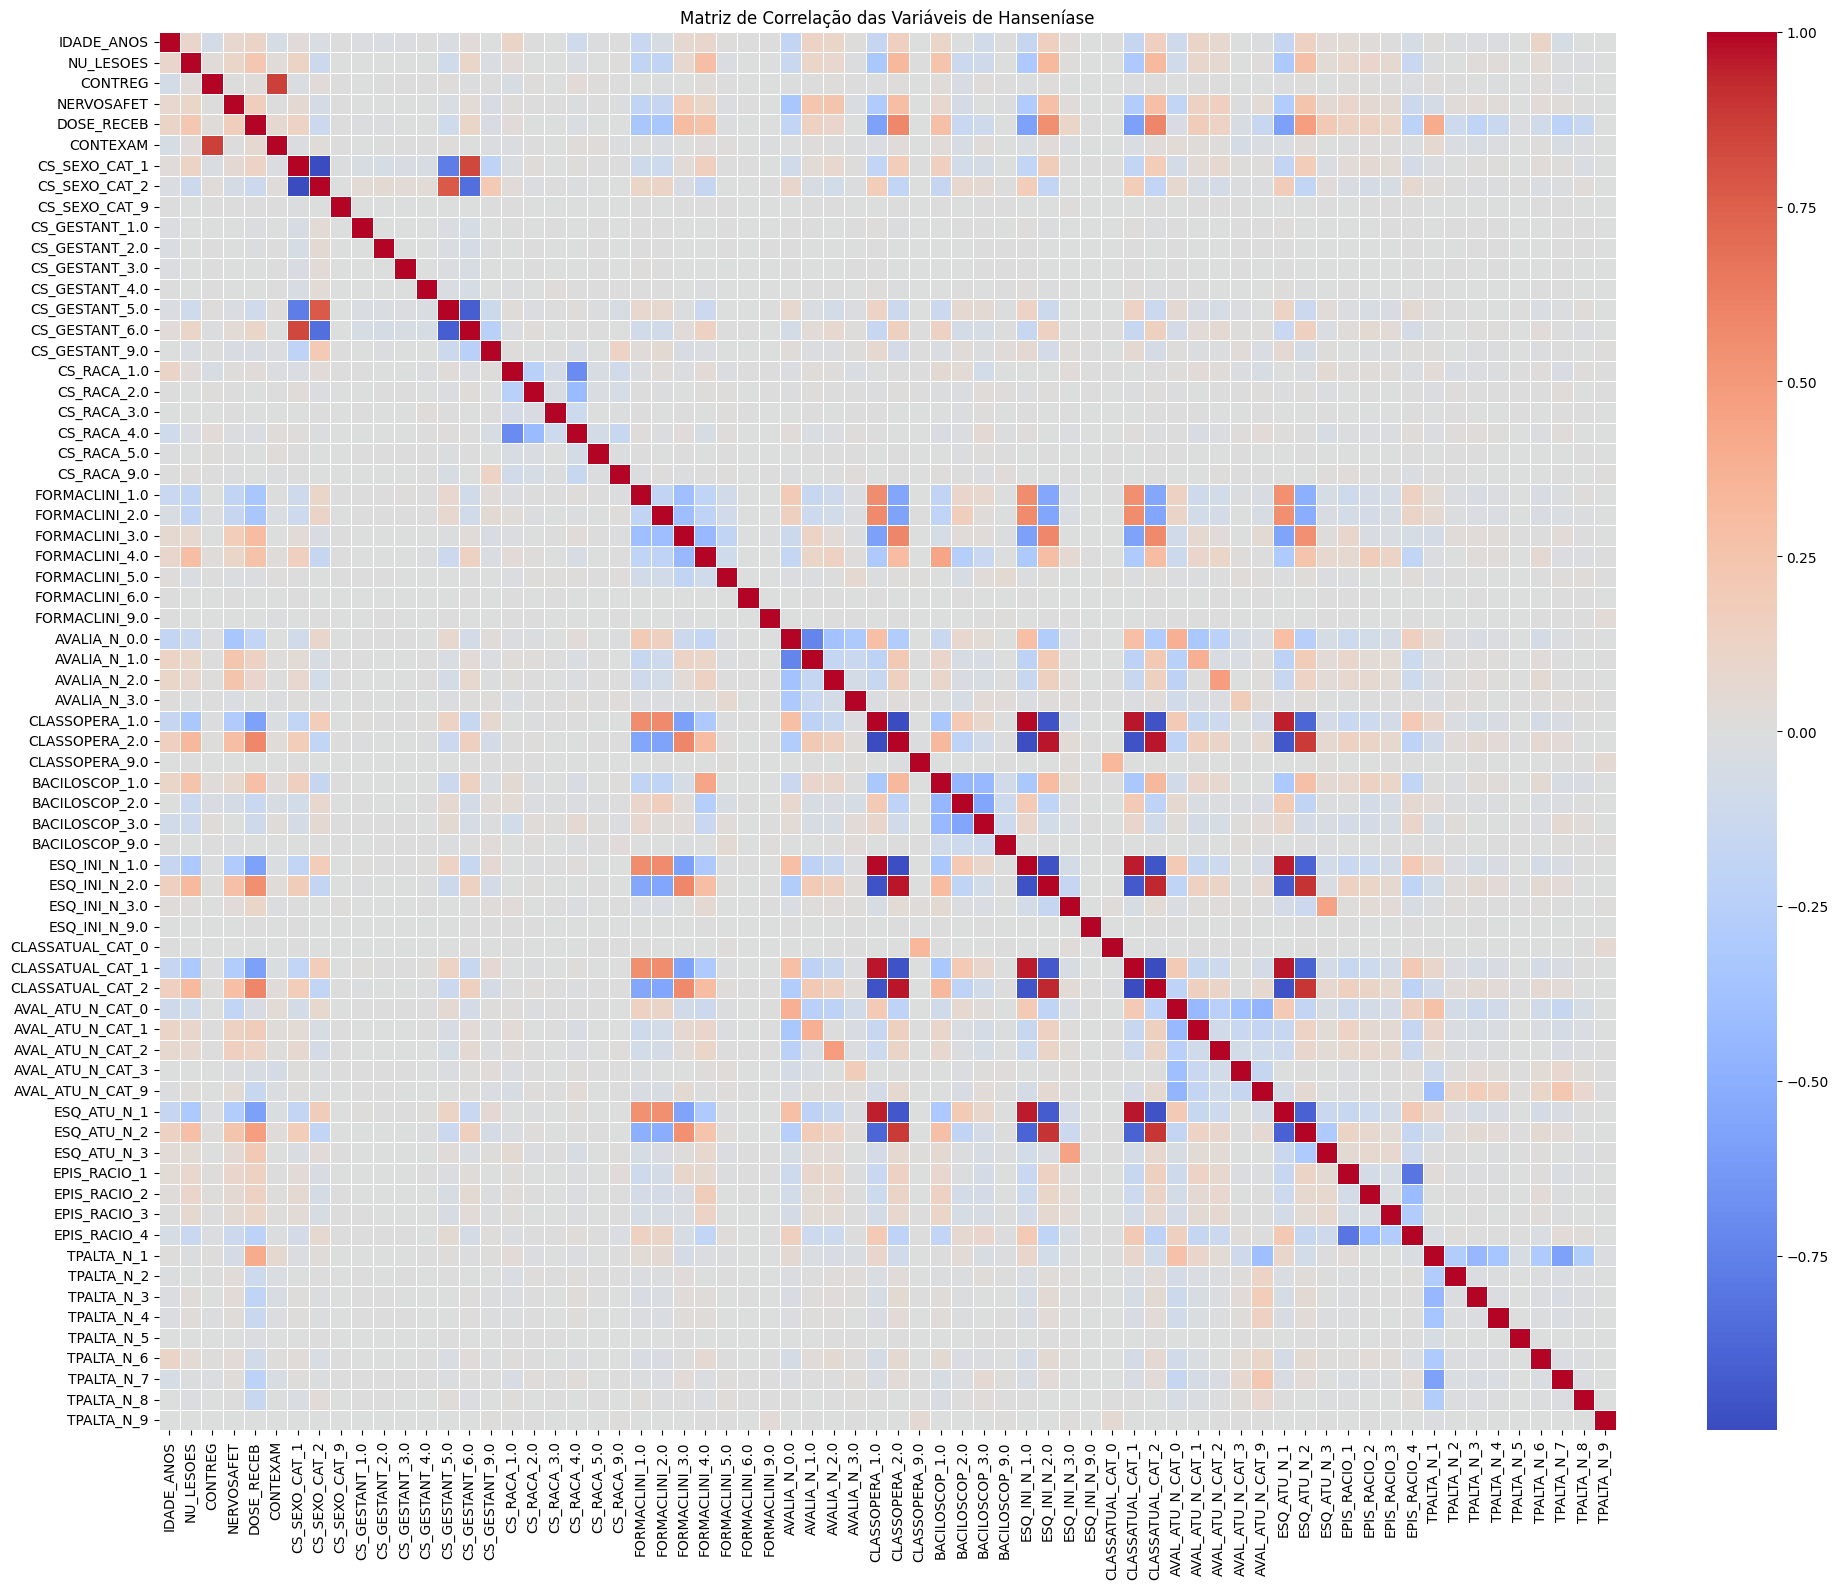

Correlações fortes:
           Variável 1        Variável 2  Correlação
117     ESQ_INI_N_1.0    CLASSOPERA_1.0    0.986410
88     CLASSOPERA_1.0     ESQ_INI_N_1.0    0.986410
130     ESQ_INI_N_2.0    CLASSOPERA_2.0    0.965508
101    CLASSOPERA_2.0     ESQ_INI_N_2.0    0.965508
150  CLASSATUAL_CAT_1       ESQ_ATU_N_1    0.964045
..                ...               ...         ...
87     CLASSOPERA_1.0    CLASSOPERA_2.0   -0.999838
149  CLASSATUAL_CAT_1  CLASSATUAL_CAT_2   -0.999853
160  CLASSATUAL_CAT_2  CLASSATUAL_CAT_1   -0.999853
16      CS_SEXO_CAT_1     CS_SEXO_CAT_2   -0.999904
19      CS_SEXO_CAT_2     CS_SEXO_CAT_1   -0.999904

[142 rows x 3 columns]


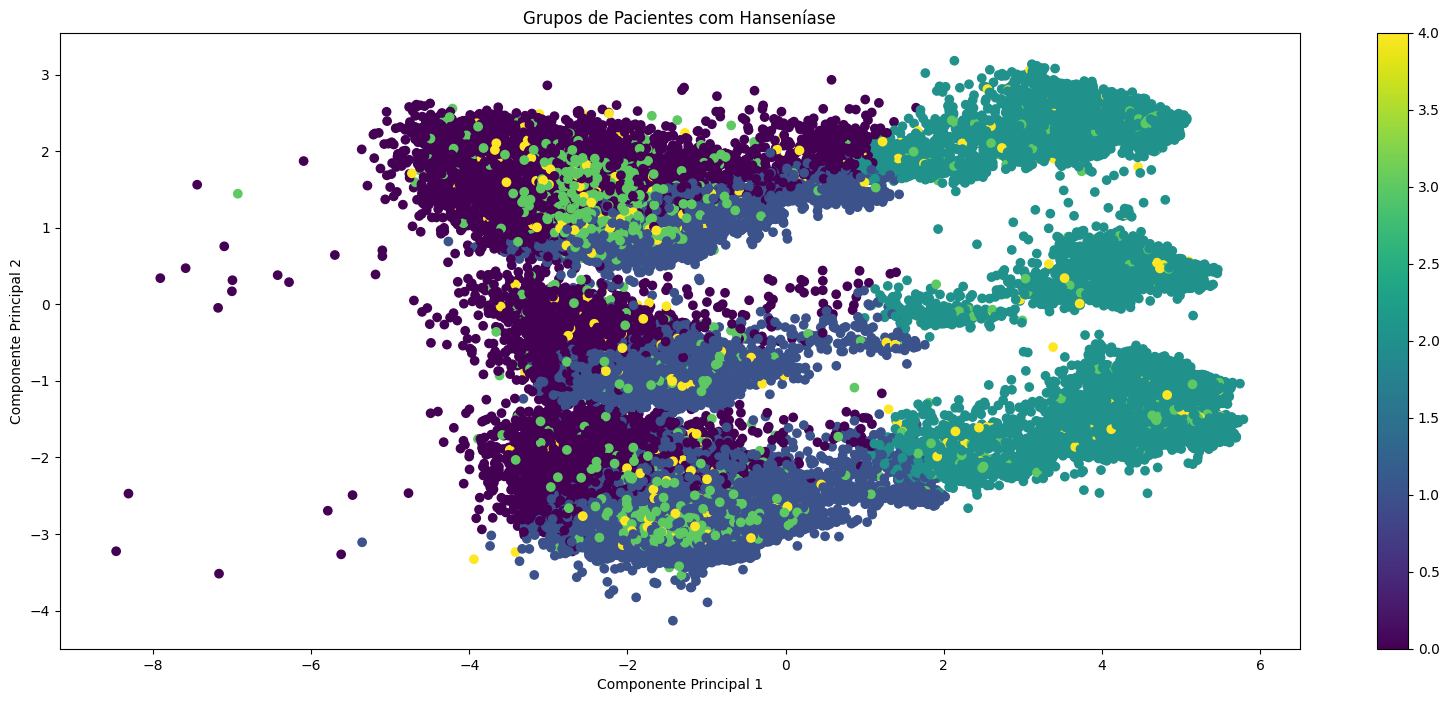


Características do Grupo 0:
IDADE_ANOS: Média = 48.71, Mediana = 49.00
CS_SEXO_CAT: Média = 1.16, Mediana = 1.00
CS_GESTANT: Média = 5.94, Mediana = 6.00
CS_RACA: Média = 2.84, Mediana = 4.00
NU_LESOES: Média = 13.09, Mediana = 9.00
FORMACLINI: Média = 3.62, Mediana = 4.00
AVALIA_N: Média = 1.02, Mediana = 1.00
CLASSOPERA: Média = 1.99, Mediana = 2.00
BACILOSCOP: Média = 1.67, Mediana = 1.00
ESQ_INI_N: Média = 2.02, Mediana = 2.00
CONTREG: Média = 3.49, Mediana = 3.00
NERVOSAFET: Média = 2.07, Mediana = 2.00
CLASSATUAL_CAT: Média = 2.00, Mediana = 2.00
AVAL_ATU_N_CAT: Média = 2.12, Mediana = 1.00
ESQ_ATU_N:
ESQ_ATU_N
2    0.909633
3    0.087418
1    0.002950
Name: proportion, dtype: float64
DOSE_RECEB: Média = 12.60, Mediana = 12.00
EPIS_RACIO:
EPIS_RACIO
4    0.523245
1    0.292322
2    0.124707
Name: proportion, dtype: float64
CONTEXAM: Média = 3.01, Mediana = 2.00
TPALTA_N:
TPALTA_N
1    0.925790
6    0.030773
7    0.030083
Name: proportion, dtype: float64

Características do Grupo

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Selecionar as variáveis de interesse
variaveis_interesse = ['IDADE_ANOS', 'CS_SEXO_CAT', 'CS_GESTANT', 'CS_RACA', 'NU_LESOES', 'FORMACLINI', 'AVALIA_N', 'CLASSOPERA', 'BACILOSCOP', 'ESQ_INI_N', 'CONTREG', 'NERVOSAFET', 'CLASSATUAL_CAT', 'AVAL_ATU_N_CAT', 'ESQ_ATU_N', 'DOSE_RECEB', 'EPIS_RACIO', 'CONTEXAM', 'TPALTA_N']

# Criar um novo DataFrame com as variáveis de interesse
df_analise = df_dados[variaveis_interesse]

# Tratar valores ausentes
df_analise = df_analise.dropna()

# Codificar variáveis categóricas
df_encoded = pd.get_dummies(df_analise, columns=['CS_SEXO_CAT', 'CS_GESTANT', 'CS_RACA', 'FORMACLINI', 'AVALIA_N', 'CLASSOPERA', 'BACILOSCOP', 'ESQ_INI_N', 'CLASSATUAL_CAT', 'AVAL_ATU_N_CAT', 'ESQ_ATU_N', 'EPIS_RACIO', 'TPALTA_N'])

# Normalizar os dados
scaler = StandardScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

# Calcular a matriz de correlação
correlation_matrix = df_normalized.corr()

# Visualizar a matriz de correlação
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis de Hanseníase')
plt.tight_layout()
plt.show()

# Identificar correlações fortes
threshold = 0.5
strong_correlations = correlation_matrix[abs(correlation_matrix) > threshold]
strong_correlations = strong_correlations.stack().reset_index()
strong_correlations.columns = ['Variável 1', 'Variável 2', 'Correlação']
strong_correlations = strong_correlations[strong_correlations['Variável 1'] != strong_correlations['Variável 2']]
strong_correlations = strong_correlations.sort_values('Correlação', ascending=False)

print("Correlações fortes:")
print(strong_correlations)

# Aplicar PCA para redução de dimensionalidade
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_normalized)

# Aplicar K-means para identificar grupos
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(df_normalized)

# Visualizar os grupos
plt.figure(figsize=(20, 8))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap='viridis')
plt.title('Grupos de Pacientes com Hanseníase')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(scatter)
plt.show()

# Analisar características dos grupos
df_analise['Cluster'] = cluster_labels
for cluster in range(5):
    print(f"\nCaracterísticas do Grupo {cluster}:")
    cluster_data = df_analise[df_analise['Cluster'] == cluster]
    for col in variaveis_interesse:
        if df_analise[col].dtype == 'object':
            print(f"{col}:\n{cluster_data[col].value_counts(normalize=True).nlargest(3)}")
        else:
            print(f"{col}: Média = {cluster_data[col].mean():.2f}, Mediana = {cluster_data[col].median():.2f}")



Para encontrar correlações entre as variáveis do seu dataframe e preparar para uma futura clusterização da doença de hanseníase

#### Analise do resultado


Características do Grupo 0:
IDADE_ANOS: Média = 49.24, Mediana = 50.00
CS_SEXO_CAT: Média = 1.21, Mediana = 1.00
CS_GESTANT: Média = 5.91, Mediana = 6.00
CS_RACA: Média = 2.84, Mediana = 4.00
NU_LESOES: Média = 12.14, Mediana = 8.00
FORMACLINI: Média = 3.49, Mediana = 4.00
AVALIA_N: Média = 1.18, Mediana = 1.00
CLASSOPERA: Média = 1.99, Mediana = 2.00
BACILOSCOP: Média = 1.83, Mediana = 1.00
ESQ_INI_N: Média = 2.02, Mediana = 2.00
CONTREG: Média = 3.47, Mediana = 3.00
NERVOSAFET: Média = 2.40, Mediana = 2.00
CLASSATUAL_CAT: Média = 1.99, Mediana = 2.00
AVAL_ATU_N:
AVAL_ATU_N
1    0.432084
0    0.221803
2    0.184475
Name: proportion, dtype: float64
ESQ_ATU_N:
ESQ_ATU_N
2    0.905476
3    0.091234
1    0.003290
Name: proportion, dtype: float64
DOSE_RECEB: Média = 12.48, Mediana = 12.00
EPIS_RACIO:
EPIS_RACIO
4    0.531920
1    0.293330
2    0.118051
Name: proportion, dtype: float64
CONTEXAM: Média = 2.97, Mediana = 2.00
TPALTA_N:
TPALTA_N
1    0.918988
7    0.022082
3    0.019146
Name: proportion, dtype: float64

Características do Grupo 1:
IDADE_ANOS: Média = 39.08, Mediana = 39.00
CS_SEXO_CAT: Média = 1.58, Mediana = 2.00
CS_GESTANT: Média = 5.72, Mediana = 6.00
CS_RACA: Média = 2.96, Mediana = 4.00
NU_LESOES: Média = 1.70, Mediana = 1.00
FORMACLINI: Média = 1.65, Mediana = 2.00
AVALIA_N: Média = 0.28, Mediana = 0.00
CLASSOPERA: Média = 1.00, Mediana = 1.00
BACILOSCOP: Média = 2.52, Mediana = 2.00
ESQ_INI_N: Média = 1.01, Mediana = 1.00
CONTREG: Média = 3.33, Mediana = 3.00
NERVOSAFET: Média = 0.32, Mediana = 0.00
CLASSATUAL_CAT: Média = 1.03, Mediana = 1.00
AVAL_ATU_N:
AVAL_ATU_N
0    0.792287
3    0.132003
1    0.064653
Name: proportion, dtype: float64
ESQ_ATU_N:
ESQ_ATU_N
1    0.953457
2    0.024034
3    0.022509
Name: proportion, dtype: float64
DOSE_RECEB: Média = 6.03, Mediana = 6.00
EPIS_RACIO:
EPIS_RACIO
4    0.938138
1    0.054658
2    0.004739
Name: proportion, dtype: float64
CONTEXAM: Média = 2.74, Mediana = 2.00
TPALTA_N:
TPALTA_N
1    0.952967
7    0.020248
3    0.008388
Name: proportion, dtype: float64

Características do Grupo 2:
IDADE_ANOS: Média = 33.69, Mediana = 29.00
CS_SEXO_CAT: Média = 2.00, Mediana = 2.00
CS_GESTANT: Média = 2.00, Mediana = 2.00
CS_RACA: Média = 2.95, Mediana = 4.00
NU_LESOES: Média = 5.62, Mediana = 3.00
FORMACLINI: Média = 2.62, Mediana = 3.00
AVALIA_N: Média = 0.44, Mediana = 0.00
CLASSOPERA: Média = 1.61, Mediana = 2.00
BACILOSCOP: Média = 2.41, Mediana = 2.00
ESQ_INI_N: Média = 1.63, Mediana = 2.00
CONTREG: Média = 3.75, Mediana = 3.00
NERVOSAFET: Média = 0.96, Mediana = 0.00
CLASSATUAL_CAT: Média = 1.63, Mediana = 2.00
AVAL_ATU_N:
AVAL_ATU_N
0    0.679907
3    0.170561
1    0.114486
Name: proportion, dtype: float64
ESQ_ATU_N:
ESQ_ATU_N
2    0.612150
1    0.364486
3    0.023364
Name: proportion, dtype: float64
DOSE_RECEB: Média = 9.15, Mediana = 12.00
EPIS_RACIO:
EPIS_RACIO
4    0.848131
1    0.105140
2    0.035047
Name: proportion, dtype: float64
CONTEXAM: Média = 3.19, Mediana = 3.00
TPALTA_N:
TPALTA_N
1    0.883178
7    0.058411
3    0.021028
Name: proportion, dtype: float64

Características do Grupo 3:
IDADE_ANOS: Média = 43.42, Mediana = 44.00
CS_SEXO_CAT: Média = 1.49, Mediana = 1.00
CS_GESTANT: Média = 5.71, Mediana = 6.00
CS_RACA: Média = 3.00, Mediana = 4.00
NU_LESOES: Média = 7.31, Mediana = 5.00
FORMACLINI: Média = 3.15, Mediana = 3.00
AVALIA_N: Média = 0.39, Mediana = 0.00
CLASSOPERA: Média = 2.00, Mediana = 2.00
BACILOSCOP: Média = 2.30, Mediana = 2.00
ESQ_INI_N: Média = 2.00, Mediana = 2.00
CONTREG: Média = 3.38, Mediana = 3.00
NERVOSAFET: Média = 1.23, Mediana = 0.00
CLASSATUAL_CAT: Média = 1.99, Mediana = 2.00
AVAL_ATU_N:
AVAL_ATU_N
0    0.789837
3    0.135090
1    0.066571
Name: proportion, dtype: float64
ESQ_ATU_N:
ESQ_ATU_N
2    0.964823
3    0.030248
1    0.004928
Name: proportion, dtype: float64
DOSE_RECEB: Média = 11.47, Mediana = 12.00
EPIS_RACIO:
EPIS_RACIO
4    0.893178
1    0.090557
2    0.011774
Name: proportion, dtype: float64
CONTEXAM: Média = 2.93, Mediana = 2.00
TPALTA_N:
TPALTA_N
1    0.918675
7    0.032509
3    0.016994
Name: proportion, dtype: float64

Características do Grupo 4:
IDADE_ANOS: Média = 39.62, Mediana = 37.00
CS_SEXO_CAT: Média = 1.50, Mediana = 1.50
CS_GESTANT: Média = 5.67, Mediana = 6.00
CS_RACA: Média = 2.50, Mediana = 2.00
NU_LESOES: Média = 6.88, Mediana = 2.00
FORMACLINI: Média = 2.86, Mediana = 3.00
AVALIA_N: Média = 0.74, Mediana = 0.00
CLASSOPERA: Média = 1.74, Mediana = 2.00
BACILOSCOP: Média = 2.60, Mediana = 2.50
ESQ_INI_N: Média = 1.79, Mediana = 2.00
CONTREG: Média = 3.07, Mediana = 2.50
NERVOSAFET: Média = 1.02, Mediana = 0.00
CLASSATUAL_CAT: Média = 1.74, Mediana = 2.00
AVAL_ATU_N:
AVAL_ATU_N
0    0.619048
3    0.285714
1    0.047619
Name: proportion, dtype: float64
ESQ_ATU_N:
ESQ_ATU_N
2    0.738095
1    0.238095
3    0.023810
Name: proportion, dtype: float64
DOSE_RECEB: Média = 5.83, Mediana = 3.50
EPIS_RACIO:
EPIS_RACIO
4    0.833333
1    0.119048
3    0.023810
Name: proportion, dtype: float64
CONTEXAM: Média = 1.90, Mediana = 1.00
TPALTA_N:
TPALTA_N
5    1.0
Name: proportion, dtype: float64


### Tentativa de identificação pela forma clinica



Análise para FORMACLINI 0.0:
IDADE_ANOS: Média = 68.00, Mediana = 68.00
NU_LESOES: Média = 30.00, Mediana = 30.00
AVALIA_N: Média = 2.00, Mediana = 2.00
CLASSOPERA: Média = 1.00, Mediana = 1.00
BACILOSCOP: Média = nan, Mediana = nan
ESQ_INI_N: Média = 2.00, Mediana = 2.00
CONTREG: Média = 0.00, Mediana = 0.00
NERVOSAFET: Média = nan, Mediana = nan
DOSE_RECEB: Média = 14.00, Mediana = 14.00

Distribuição de Sexo:
CS_SEXO_CAT
2    1.0
Name: proportion, dtype: float64

Distribuição de Raça:
CS_RACA
2.0    1.0
Name: proportion, dtype: float64

Análise para FORMACLINI 1.0:
IDADE_ANOS: Média = 36.18, Mediana = 35.00
NU_LESOES: Média = 1.93, Mediana = 1.00
AVALIA_N: Média = 0.36, Mediana = 0.00
CLASSOPERA: Média = 1.11, Mediana = 1.00


d:\python\data_health\venv_health\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\python\data_health\venv_health\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


BACILOSCOP: Média = 2.63, Mediana = 2.00
ESQ_INI_N: Média = 1.14, Mediana = 1.00
CONTREG: Média = 3.30, Mediana = 3.00
NERVOSAFET: Média = 0.41, Mediana = 0.00
DOSE_RECEB: Média = 6.24, Mediana = 6.00

Distribuição de Sexo:
CS_SEXO_CAT
2    0.56
1    0.44
9    0.00
Name: proportion, dtype: float64

Distribuição de Raça:
CS_RACA
4.0    0.55
1.0    0.27
2.0    0.13
9.0    0.03
3.0    0.01
5.0    0.01
Name: proportion, dtype: float64

Análise para FORMACLINI 2.0:
IDADE_ANOS: Média = 40.42, Mediana = 40.00
NU_LESOES: Média = 1.93, Mediana = 1.00
AVALIA_N: Média = 0.43, Mediana = 0.00
CLASSOPERA: Média = 1.10, Mediana = 1.00
BACILOSCOP: Média = 2.56, Mediana = 2.00
ESQ_INI_N: Média = 1.13, Mediana = 1.00
CONTREG: Média = 3.21, Mediana = 3.00
NERVOSAFET: Média = 0.54, Mediana = 0.00
DOSE_RECEB: Média = 6.31, Mediana = 6.00

Distribuição de Sexo:
CS_SEXO_CAT
2    0.56
1    0.44
9    0.00
Name: proportion, dtype: float64

Distribuição de Raça:
CS_RACA
4.0    0.52
1.0    0.31
2.0    0.12
9.0   

d:\python\data_health\venv_health\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\python\data_health\venv_health\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


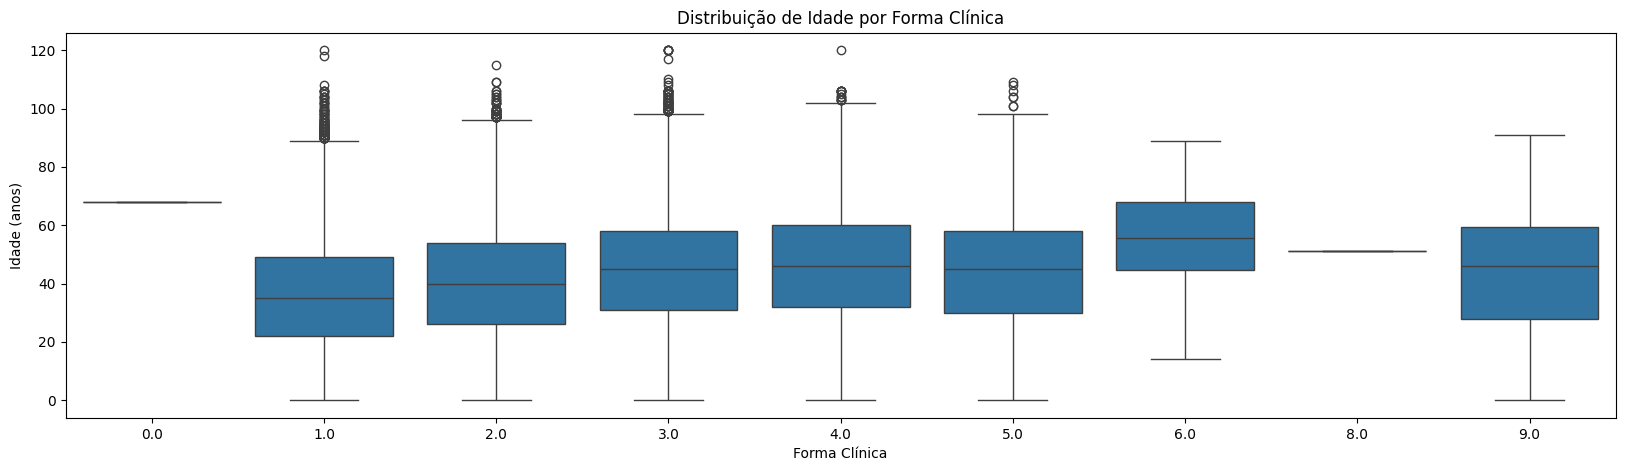

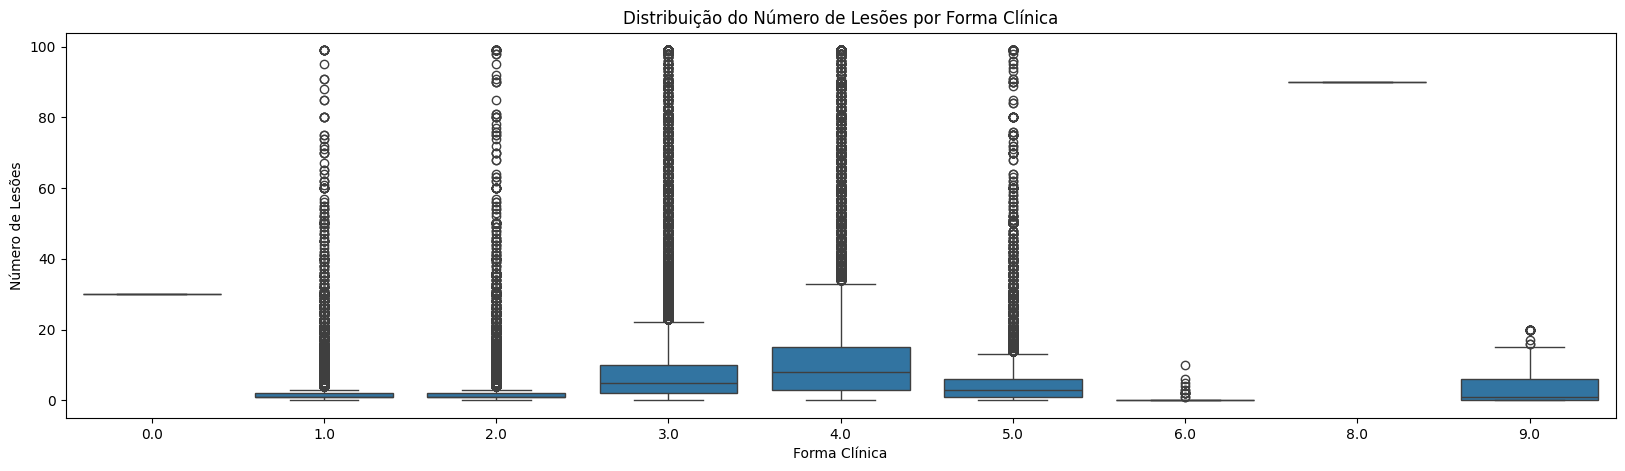


ANOVA para número de lesões: F-statistic = nan, p-value = nan

Correlações com FORMACLINI:
FORMACLINI    1.000000
CLASSOPERA    0.615027
ESQ_INI_N     0.565324
DOSE_RECEB    0.350318
NU_LESOES     0.284887
AVALIA_N      0.215580
NERVOSAFET    0.203952
IDADE_ANOS    0.168144
CONTREG       0.007353
BACILOSCOP   -0.105231
Name: FORMACLINI, dtype: float64


In [40]:
# Agrupar os dados por FORMACLINI
grupos_formaclini = df_dados.groupby('FORMACLINI')

# Variáveis numéricas para análise
variaveis_numericas = ['IDADE_ANOS', 'NU_LESOES', 'AVALIA_N', 'CLASSOPERA', 'BACILOSCOP', 'ESQ_INI_N', 'CONTREG', 'NERVOSAFET', 'DOSE_RECEB']

# Análise estatística para cada grupo
for forma, grupo in grupos_formaclini:
    print(f"\nAnálise para FORMACLINI {forma}:")
    for var in variaveis_numericas:
        if var in grupo.columns:
            media = grupo[var].mean()
            mediana = grupo[var].median()
            print(f"{var}: Média = {media:.2f}, Mediana = {mediana:.2f}")
        else:
            print(f"{var}: Dados não disponíveis.")
    
    # Distribuição de sexo
    print("\nDistribuição de Sexo:")
    print(grupo['CS_SEXO_CAT'].value_counts(normalize=True).round(2))
    
    # Distribuição de raça
    print("\nDistribuição de Raça:")
    print(grupo['CS_RACA'].value_counts(normalize=True).round(2))

# Visualização da distribuição de idade por FORMACLINI
plt.figure(figsize=(20, 5))
sns.boxplot(x='FORMACLINI', y='IDADE_ANOS', data=df_dados)
plt.title('Distribuição de Idade por Forma Clínica')
plt.xlabel('Forma Clínica')
plt.ylabel('Idade (anos)')
plt.show()

# Visualização da distribuição do número de lesões por FORMACLINI
plt.figure(figsize=(20, 5))
sns.boxplot(x='FORMACLINI', y='NU_LESOES', data=df_dados)
plt.title('Distribuição do Número de Lesões por Forma Clínica')
plt.xlabel('Forma Clínica')
plt.ylabel('Número de Lesões')
plt.show()

# Teste ANOVA para verificar diferenças significativas entre os grupos em relação ao número de lesões
f_statistic, p_value = stats.f_oneway(*[grupo['NU_LESOES'] for forma, grupo in grupos_formaclini])
print(f"\nANOVA para número de lesões: F-statistic = {f_statistic:.2f}, p-value = {p_value:.4f}")

# Correlação entre variáveis numéricas e FORMACLINI
correlacoes = df_dados[variaveis_numericas + ['FORMACLINI']].corr()['FORMACLINI'].sort_values(ascending=False)
print("\nCorrelações com FORMACLINI:")
print(correlacoes)


In [41]:
from sklearn.preprocessing import StandardScaler

# Selecionar apenas as colunas numéricas
numeric_df = df_dados.select_dtypes(include=['number'])

# Remover colunas com valores ausentes
# numeric_df = numeric_df.dropna(axis=1)

# Normalizar os dados
scaler = StandardScaler()
normalized_df = pd.DataFrame(scaler.fit_transform(numeric_df), columns=numeric_df.columns)

normalized_df.head()


d:\python\data_health\venv_health\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
d:\python\data_health\venv_health\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
d:\python\data_health\venv_health\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,NU_IDADE_N,CS_GESTANT,CS_RACA,DT_TRANSRM,NU_LESOES,...,CLASSOPERA_CAT,BACILOSCOP_CAT,ESQ_INI_N_CAT,CONTREG_CAT,NERVOSAFET_CAT,ESQ_ATU_N_CAT,DOSE_RECEB_CAT,EPIS_RACIO_CAT,CONTEXAM_CAT,TPALTA_N_CAT
0,-1.454469,0.917405,0.910526,-0.24006,-0.055830,0.352348,-0.21661,NaN,NaN,-0.618607,...,0.708585,0.930361,1.631465,-1.016014,-0.410543,1.135218,-1.058972,1.036383,-0.752025,-0.49937
1,-1.454469,0.917405,0.915625,-0.24006,-0.055898,0.047869,-0.21661,-1.185067,NaN,-0.618607,...,0.708585,0.930361,1.631465,-0.033380,-0.410543,1.135218,-1.058972,1.036383,-0.031818,-0.49937
2,-1.454469,0.917405,0.915625,-0.24006,-0.055898,-0.213113,-0.21661,-1.185067,NaN,-0.618607,...,-1.376267,0.930361,-0.995268,-0.688469,-0.410543,-0.841837,-1.058972,1.036383,-0.391921,-0.49937
3,-1.454469,0.917405,0.922359,-0.24006,-0.054756,-0.039125,2.07904,NaN,NaN,-0.618607,...,0.708585,0.930361,1.631465,-0.033380,-0.410543,1.135218,-1.058972,1.036383,0.328286,-0.49937
4,-1.454469,0.917405,0.922359,-0.24006,-0.054756,-0.234862,-0.21661,NaN,NaN,-0.618607,...,0.708585,0.930361,1.631465,-1.016014,-0.410543,1.135218,-1.058972,1.036383,-0.752025,-0.49937


Cálculo da matriz de correlação

In [42]:
# Calcular a matriz de correlação
correlation_matrix = normalized_df.corr()


Visualização da matriz de correlação

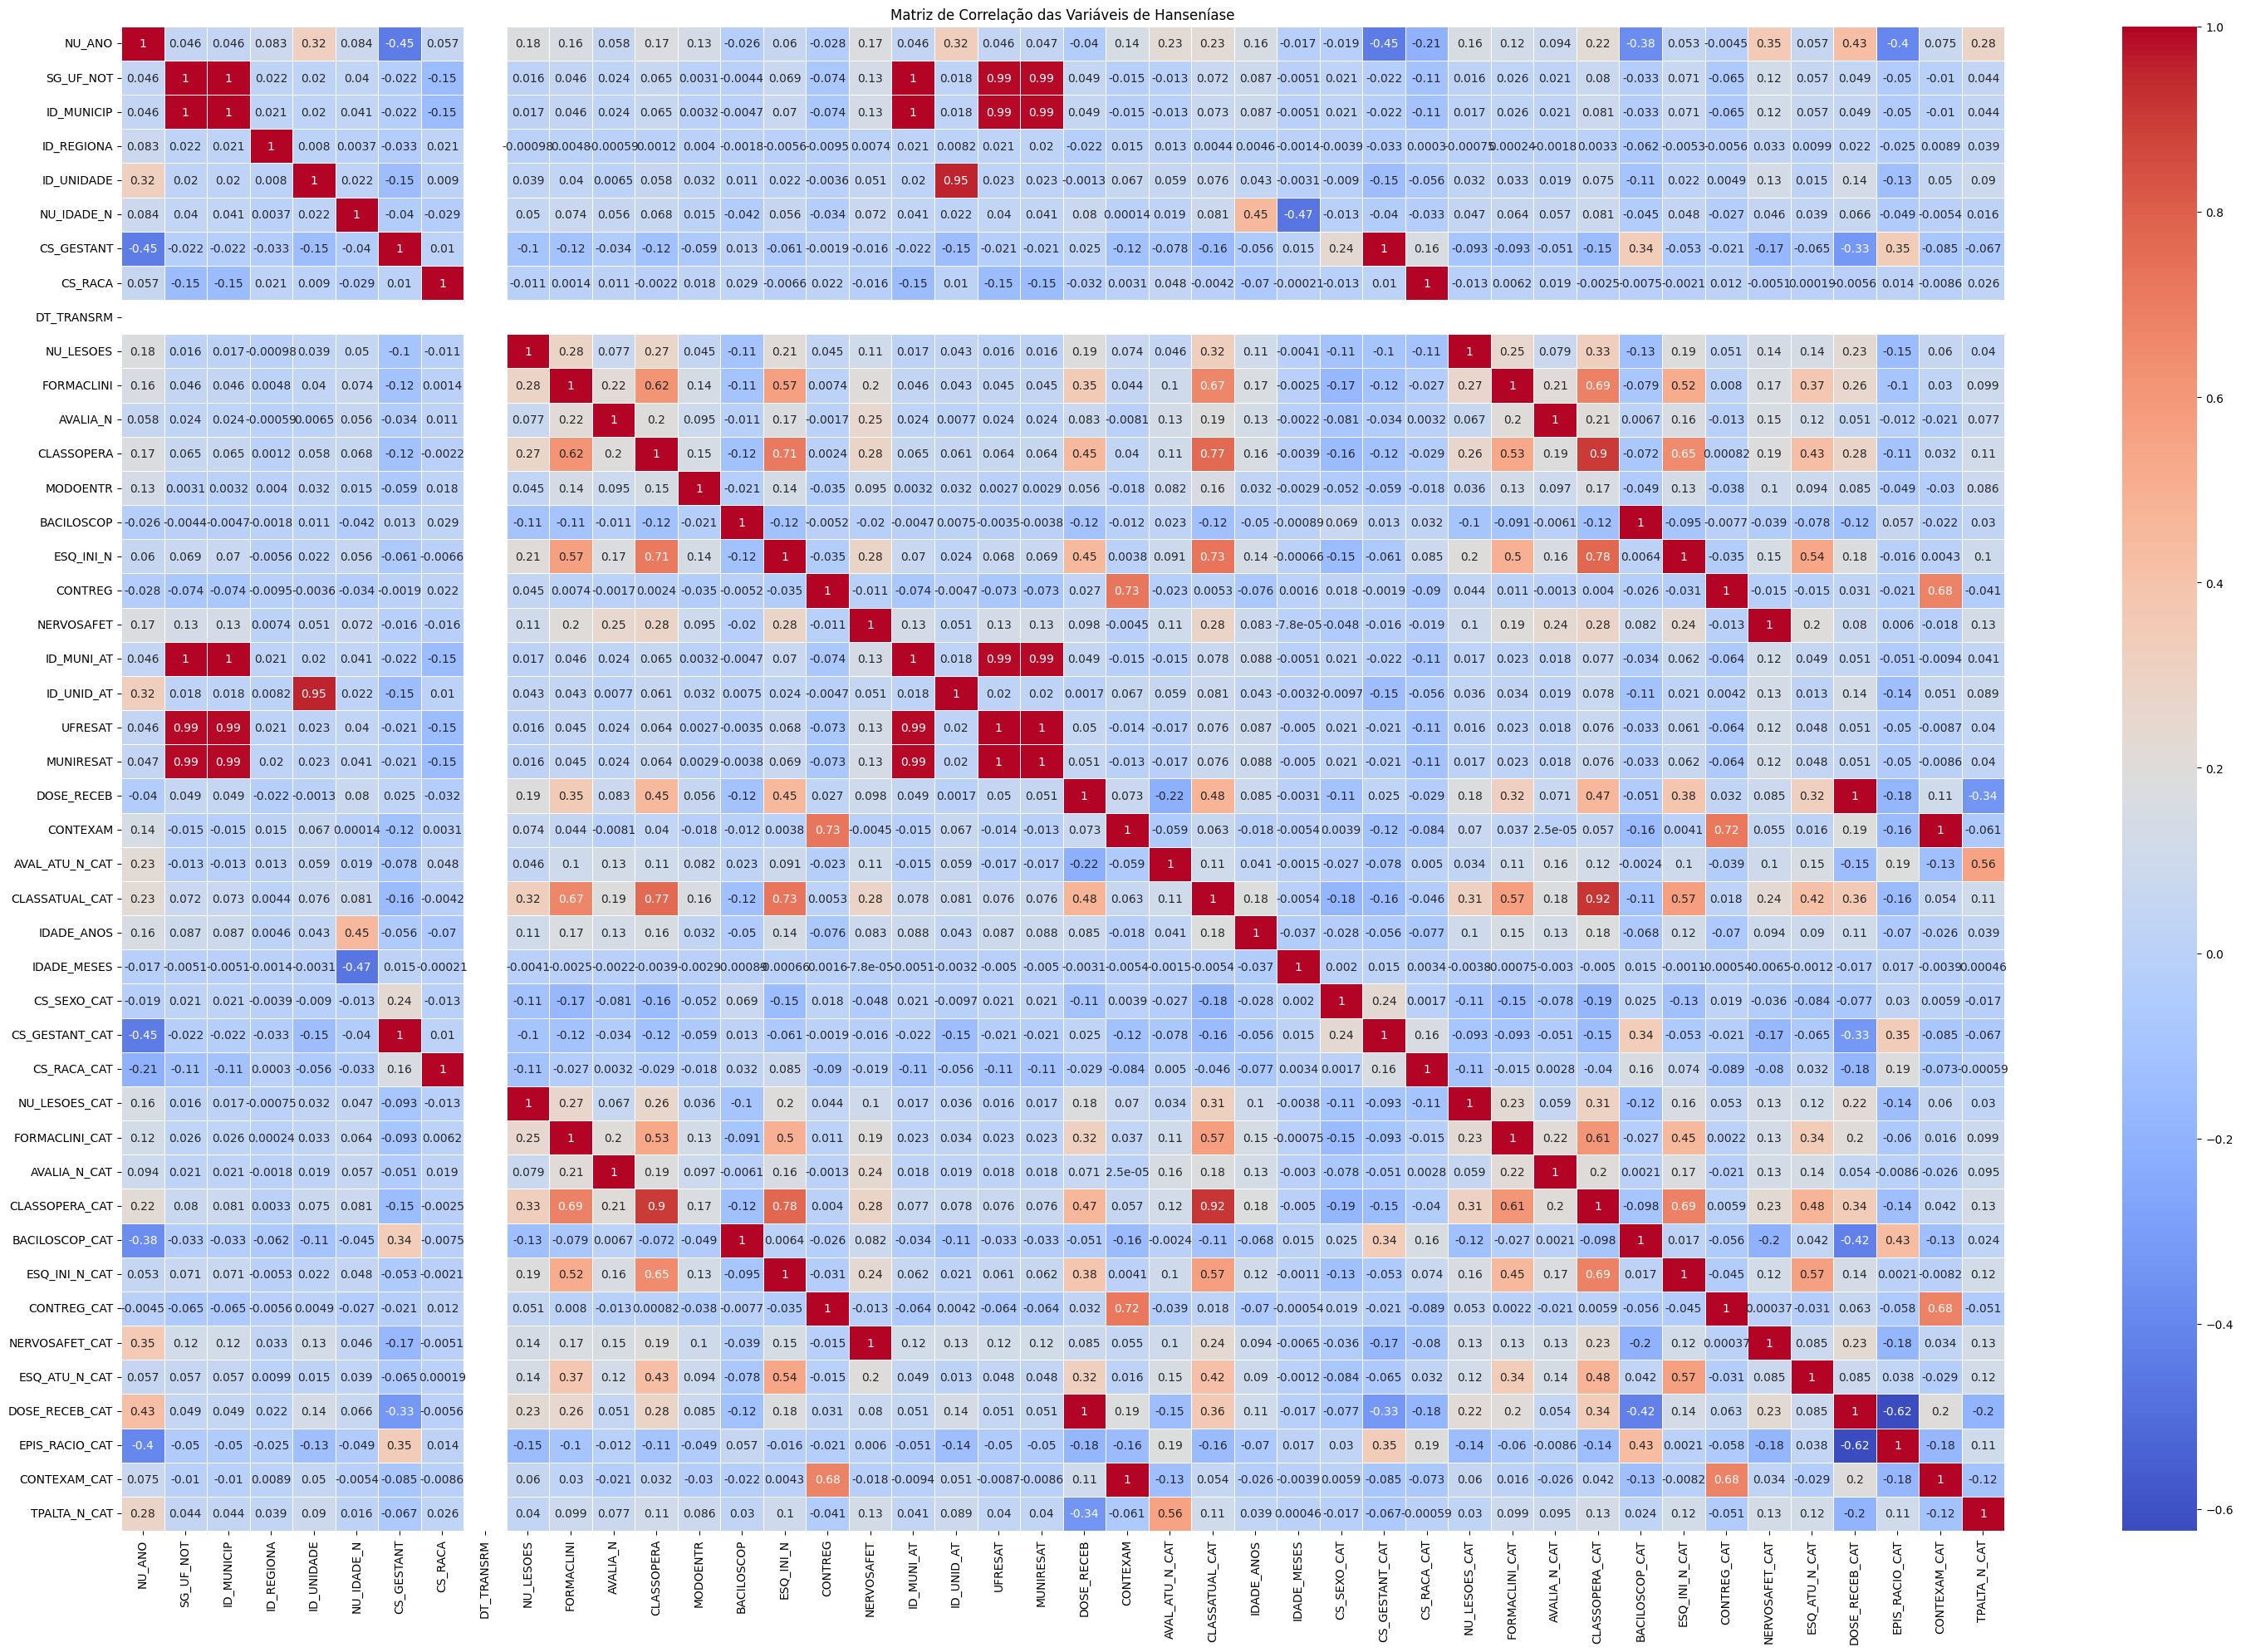

In [43]:
# Criar um mapa de calor da matriz de correlação
plt.figure(figsize=(30, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis de Hanseníase')
plt.tight_layout()
plt.show()


# Analises Graficas

## Ocorrências de casos

### Notificações por Mês

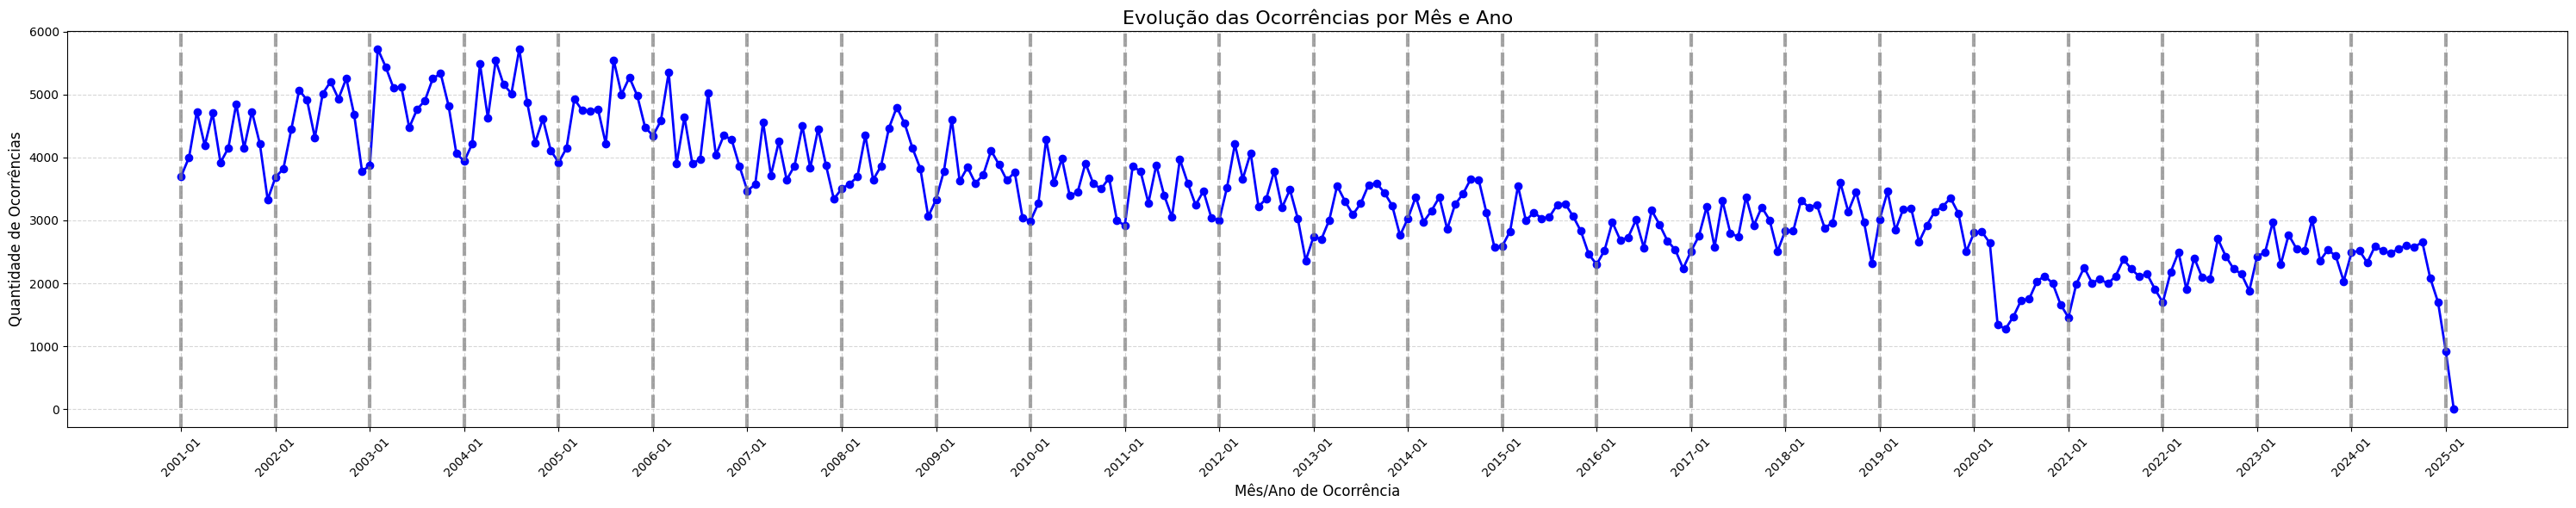

In [19]:
# Converter a coluna DT_NOTIFIC para datetime
df_dados["DT_NOTIFIC"] = pd.to_datetime(df_dados["DT_NOTIFIC"], format='%Y-%m-%d', errors='coerce')

# Criar uma nova coluna no formato "AAAA-MM"
df_dados["ANO_MES"] = df_dados["DT_NOTIFIC"].dt.to_period("M").astype(str)

# Agrupar os dados por "ANO_MES" e contar a quantidade de ocorrências
dados_agrupados = df_dados.groupby("ANO_MES").size().reset_index(name="quantidade")

# Detectar mudanças de ano para adicionar linhas verticais
dados_agrupados["ANO"] = dados_agrupados["ANO_MES"].str[:4]
anos_unicos = dados_agrupados["ANO"].drop_duplicates().index

# Plotar o gráfico de linha com todos os pontos
fig, ax = plt.subplots(figsize=(30, 6))

ax.plot(
    dados_agrupados["ANO_MES"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Mês e Ano", fontsize=16)
ax.set_xlabel("Mês/Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Ajustar os ticks (marcadores) do eixo X para exibir de 6 em 6 meses (somente legenda)
xticks = dados_agrupados["ANO_MES"][::12]  # Seleciona a cada 6 meses
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45)

# Adicionar linhas verticais nos inícios de cada ano
for ano_idx in anos_unicos:
    ax.axvline(x=ano_idx, color='gray', linestyle='--', linewidth=3, alpha=0.7)

# Exibir grid para melhor visualização
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a disposição do layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


### Notificações por Ano

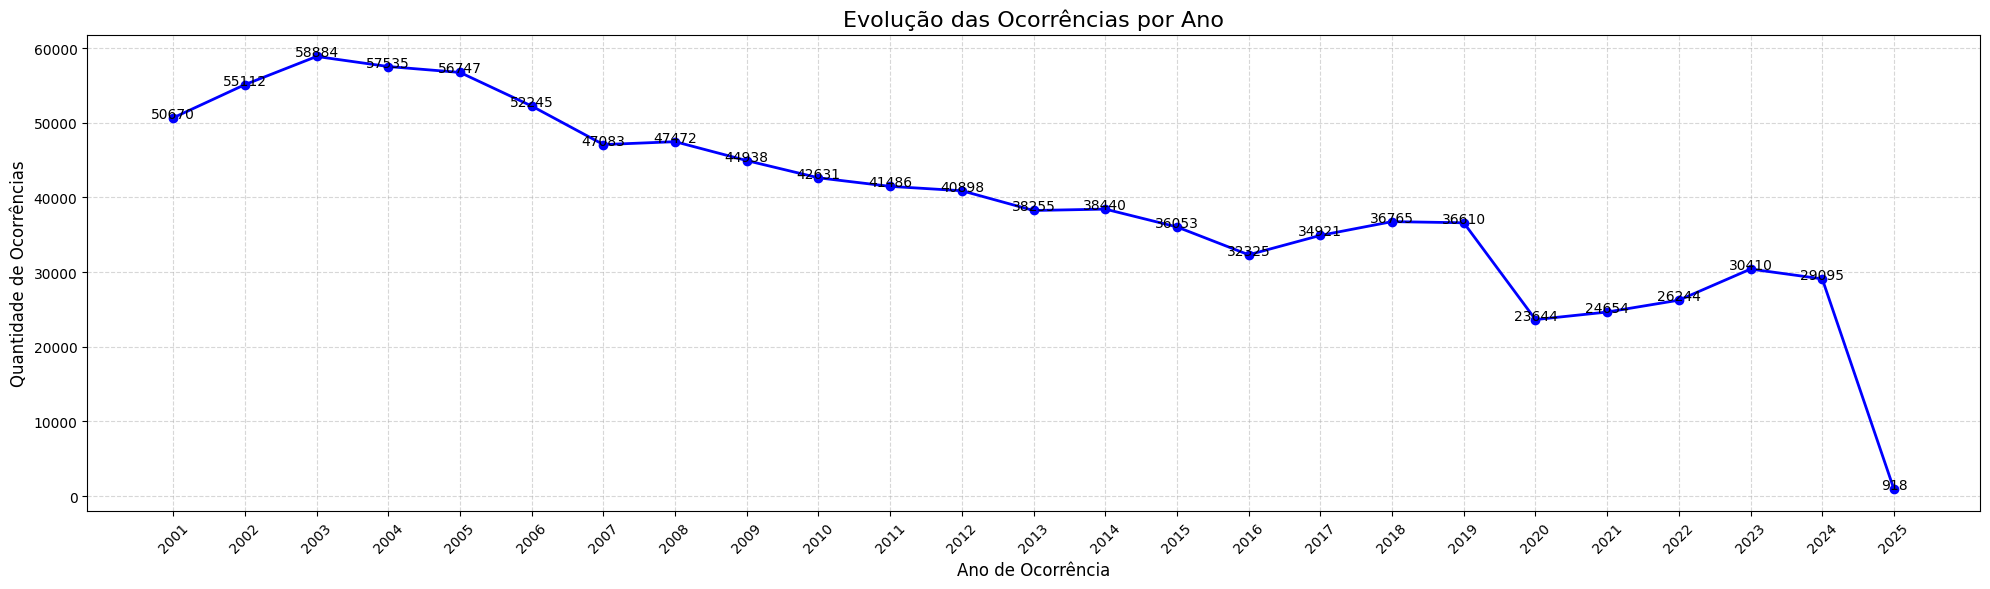

In [15]:
# Agrupar os dados por ano e contar a quantidade de ocorrências
dados_agrupados = df_dados.groupby("NU_ANO").size().reset_index(name="quantidade")

# Plotar o gráfico de linha com os anos no eixo X e a quantidade no eixo Y
fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(
    dados_agrupados["NU_ANO"],
    dados_agrupados["quantidade"],
    marker='o',
    linestyle='-',
    linewidth=2,
    color='b'
)

# Configurar título e rótulos dos eixos
ax.set_title("Evolução das Ocorrências por Ano", fontsize=16)
ax.set_xlabel("Ano de Ocorrência", fontsize=12)
ax.set_ylabel("Quantidade de Ocorrências", fontsize=12)

# Adicionar rótulos nos pontos
for i, txt in enumerate(dados_agrupados["quantidade"]):
    ax.annotate(txt, (dados_agrupados["NU_ANO"][i], dados_agrupados["quantidade"][i]), fontsize=10, ha='center')

# Melhorar a aparência do gráfico
plt.xticks(dados_agrupados["NU_ANO"], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()